<a href="https://colab.research.google.com/github/Byancyanblue/Explainable-AI-untuk-Interpretasi-Model-CNN-dalam-Klasifikasi-Alzheimer-Berbasis-Citra-MRI/blob/main/EXPERIMEN_FULL_VGG19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NO DATA AUGMENTATION

Device: cuda | Augmentation: False
Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280
TIDAK Menerapkan Augmentasi Data pada Training Set...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 177MB/s]


Start training...
Epoch 1/25 | Train Loss: 0.9785 Acc: 0.5237 | Val Loss: 0.8886 Acc: 0.5615
Epoch 2/25 | Train Loss: 0.8446 Acc: 0.5984 | Val Loss: 0.9575 Acc: 0.5723
Epoch 3/25 | Train Loss: 0.6708 Acc: 0.7021 | Val Loss: 0.7236 Acc: 0.6699
Epoch 4/25 | Train Loss: 0.4638 Acc: 0.8115 | Val Loss: 0.6075 Acc: 0.7588
Epoch 5/25 | Train Loss: 0.2701 Acc: 0.8977 | Val Loss: 0.3751 Acc: 0.8535
Epoch 6/25 | Train Loss: 0.1679 Acc: 0.9399 | Val Loss: 0.2785 Acc: 0.8926
Epoch 7/25 | Train Loss: 0.0954 Acc: 0.9680 | Val Loss: 0.3915 Acc: 0.8857
Epoch 8/25 | Train Loss: 0.0614 Acc: 0.9783 | Val Loss: 0.2982 Acc: 0.9033
Epoch 9/25 | Train Loss: 0.0464 Acc: 0.9836 | Val Loss: 0.2844 Acc: 0.9082
Epoch 10/25 | Train Loss: 0.0263 Acc: 0.9922 | Val Loss: 0.3095 Acc: 0.9141
Epoch 11/25 | Train Loss: 0.0036 Acc: 0.9995 | Val Loss: 0.2334 Acc: 0.9404
Epoch 12/25 | Train Loss: 0.0073 Acc: 0.9978 | Val Loss: 0.5205 Acc: 0.9082
Epoch 13/25 | Train Loss: 0.0271 Acc: 0.9934 | Val Loss: 0.1614 Acc: 0.9512
Epo

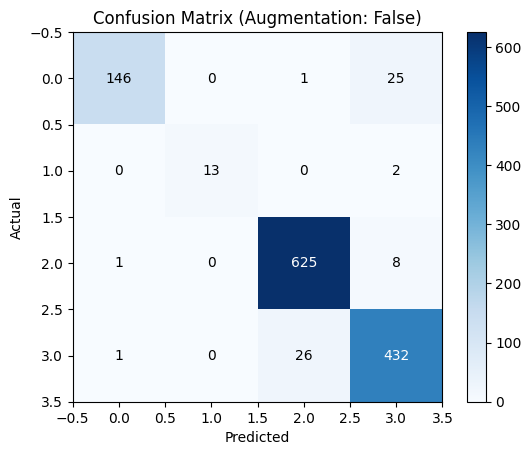

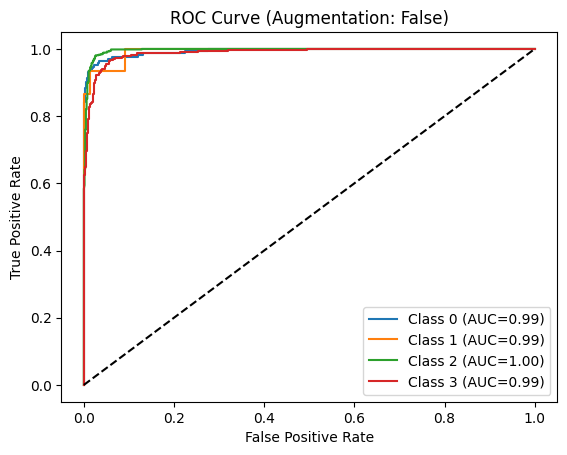

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAG
# ==========================================
# UBAH FLAG INI UNTUK SKENARIO EKSPERIMEN:
# False = Tanpa Augmentasi | True = Dengan Augmentasi
USE_AUGMENTATION = False

CONFIG = {
    "lr": 0.0001,           # Sesuai standar Fase 1
    "batch_size": 16,       # Terkunci sesuai kapasitas VRAM
    "epochs": 25,           # Sesuai standar Fase 1
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Augmentation: {USE_AUGMENTATION}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
train_labels = np.array(train_data["label"])

# ==========================================
# 3. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 4. TRANSFORM (SKENARIO AUGMENTASI)
# ==========================================
# Transform dasar untuk Validasi dan Testing (TIDAK BOLEH DIAUGMENTASI)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    print("Menerapkan Augmentasi Data pada Training Set...")
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    print("TIDAK Menerapkan Augmentasi Data pada Training Set...")
    train_transform = val_test_transform # Hanya Resize, ToTensor, Normalize

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# Catatan: Sampler dinonaktifkan di Fase 1 Tabel 1.1 untuk isolasi perlakuan
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Baseline Fine-Tuning: Unfreeze 10 layer terakhir
for param in model.features[-10:].parameters():
    param.requires_grad = True

num_classes = len(np.unique(train_labels))

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)

model = model.to(device)

# ==========================================
# 6. LOSS & OPTIMIZER
# ==========================================
# Catatan: Class Weight dinonaktifkan di Tabel 1.1
criterion = nn.CrossEntropyLoss()

# Sesuai kesepakatan Fase 1: Optimizer Adam
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("Start training...")

best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):

    # ===== TRAIN =====
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total
    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_aug_{USE_AUGMENTATION}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("\n=== TEST CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Augmentation: {USE_AUGMENTATION})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Augmentation: {USE_AUGMENTATION})")
plt.legend(loc="lower right")
plt.show()

NO AUG + SAMPLER

Device: cuda | Augmentation: False | Imbalance Strategy: sampler
Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280
-> TIDAK menggunakan Data Augmentasi pada Training Set...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 180MB/s]


-> Menggunakan Standard Loss Function (Tanpa Class Weight)...

Mulai Training...
Epoch 1/25 | Train Loss: 1.0412 Acc: 0.4683 | Val Loss: 0.9269 Acc: 0.5449
Epoch 2/25 | Train Loss: 0.6622 Acc: 0.6707 | Val Loss: 0.7152 Acc: 0.6797
Epoch 3/25 | Train Loss: 0.5457 Acc: 0.7468 | Val Loss: 0.6670 Acc: 0.6846
Epoch 4/25 | Train Loss: 0.3043 Acc: 0.8723 | Val Loss: 0.4841 Acc: 0.8066
Epoch 5/25 | Train Loss: 0.2499 Acc: 0.9050 | Val Loss: 0.5130 Acc: 0.7803
Epoch 6/25 | Train Loss: 0.1997 Acc: 0.9290 | Val Loss: 0.5106 Acc: 0.8086
Epoch 7/25 | Train Loss: 0.1074 Acc: 0.9602 | Val Loss: 0.3229 Acc: 0.8936
Epoch 8/25 | Train Loss: 0.0728 Acc: 0.9724 | Val Loss: 0.3420 Acc: 0.8691
Epoch 9/25 | Train Loss: 0.0696 Acc: 0.9756 | Val Loss: 0.3043 Acc: 0.8955
Epoch 10/25 | Train Loss: 0.0538 Acc: 0.9814 | Val Loss: 0.2865 Acc: 0.9082
Epoch 11/25 | Train Loss: 0.0322 Acc: 0.9895 | Val Loss: 0.4182 Acc: 0.8799
Epoch 12/25 | Train Loss: 0.0129 Acc: 0.9956 | Val Loss: 0.2656 Acc: 0.9277
Epoch 13/25 | Tr

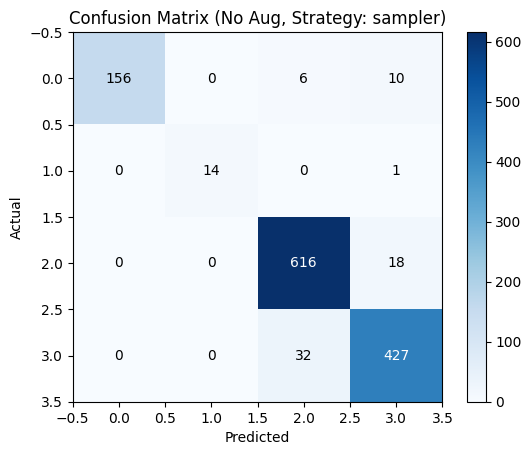

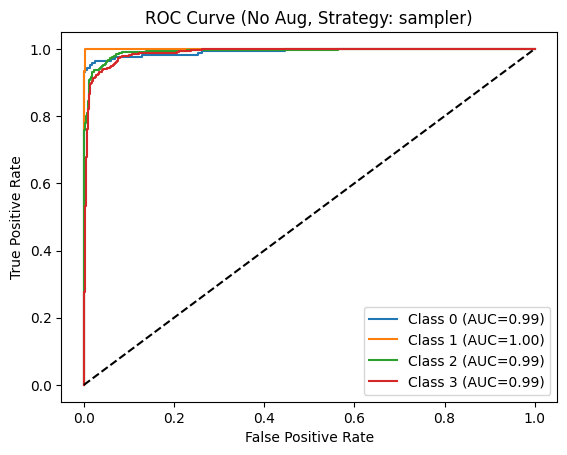

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
# 🔥 UBAH FLAG INI UNTUK TANPA AUGMENTASI:
USE_AUGMENTATION = False

# UBAH STRATEGI INI UNTUK EKSPERIMEN TABEL 1.2:
# Pilih salah satu: "none" | "class_weight" | "sampler"
IMBALANCE_STRATEGY = "sampler"

CONFIG = {
    "lr": 0.0001,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Augmentation: {USE_AUGMENTATION} | Imbalance Strategy: {IMBALANCE_STRATEGY}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
# Normalisasi bobot (opsional tapi disarankan agar loss tidak terlalu meledak)
class_weights = class_weights / class_weights.sum() * num_classes

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 5. TRANSFORM (AUGMENTATION LOGIC)
# ==========================================
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    print("-> Menerapkan Data Augmentasi pada Training Set...")
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    print("-> TIDAK menggunakan Data Augmentasi pada Training Set...")
    # Hanya menggunakan Resize, ToTensor, dan Normalize standar
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER & SAMPLER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    # Jika pakai sampler, shuffle WAJIB bernilai False
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> Tidak menggunakan Sampler (Normal Shuffle)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

# Val dan Test selalu normal
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

for param in model.features[-10:].parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS & OPTIMIZER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    print("-> Menggunakan Standard Loss Function (Tanpa Class Weight)...")
    criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total
    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_no_aug_strategy_{IMBALANCE_STRATEGY}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT (No Aug, {IMBALANCE_STRATEGY.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (No Aug, Strategy: {IMBALANCE_STRATEGY})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (No Aug, Strategy: {IMBALANCE_STRATEGY})")
plt.legend(loc="lower right")
plt.show()

Device: cuda | Augmentation: False | Imbalance Strategy: class_weight
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280
-> TIDAK menggunakan Data Augmentasi pada Training Set...
-> Tidak menggunakan Sampler (Normal Shuffle)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | Train Loss: 1.3618 Acc: 0.3770 | Val Loss: 1.3255 Acc: 0.3477
Epoch 2/25 | Train Loss: 1.3293 Acc: 0.3721 | Val Loss: 1.3124 Acc: 0.5010
Epoch 3/25 | Train Loss: 1.3361 Acc: 0.4014 | Val Loss: 1.3368 Acc: 0.5010
Epoch 4/25 | Train Loss: 1.3464 Acc: 0.4216 | Val Loss: 1.3178 Acc: 0.5010
Epoch 5/25 | Train Loss: 1.3180 Acc: 0.3855 | Val Loss: 1.2883 Acc: 0.5010
Epoch 6/25 | Train Loss: 1.3524 Acc: 0.4429 | Val Loss: 1.3160 Acc: 0.3477
Epoch 7/25 | Train Loss: 1.3171 Acc: 0.4062 | Val Loss: 1.3045 Acc: 0.5010
Epoch 8/25 | Train Loss: 1.3206 Acc: 0.4089 | Val Loss: 1.3137 Acc: 0.5010
Epoch 9/25 | Train Loss: 1.2973 Acc: 0.4277 | Val Loss: 1.2701 Acc: 0.3291
Epo

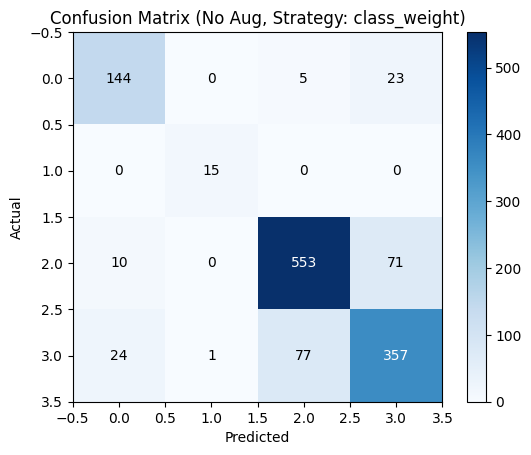

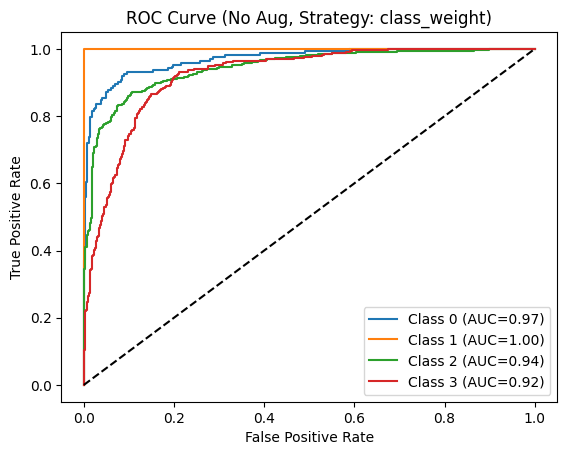

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
# 🔥 UBAH FLAG INI UNTUK TANPA AUGMENTASI:
USE_AUGMENTATION = False

# UBAH STRATEGI INI UNTUK EKSPERIMEN TABEL 1.2:
# Pilih salah satu: "none" | "class_weight" | "sampler"
IMBALANCE_STRATEGY = "class_weight"

CONFIG = {
    "lr": 0.0001,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Augmentation: {USE_AUGMENTATION} | Imbalance Strategy: {IMBALANCE_STRATEGY}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
# Normalisasi bobot (opsional tapi disarankan agar loss tidak terlalu meledak)
class_weights = class_weights / class_weights.sum() * num_classes

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 5. TRANSFORM (AUGMENTATION LOGIC)
# ==========================================
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    print("-> Menerapkan Data Augmentasi pada Training Set...")
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    print("-> TIDAK menggunakan Data Augmentasi pada Training Set...")
    # Hanya menggunakan Resize, ToTensor, dan Normalize standar
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER & SAMPLER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    # Jika pakai sampler, shuffle WAJIB bernilai False
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> Tidak menggunakan Sampler (Normal Shuffle)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

# Val dan Test selalu normal
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

for param in model.features[-10:].parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS & OPTIMIZER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    print("-> Menggunakan Standard Loss Function (Tanpa Class Weight)...")
    criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total
    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_no_aug_strategy_{IMBALANCE_STRATEGY}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT (No Aug, {IMBALANCE_STRATEGY.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (No Aug, Strategy: {IMBALANCE_STRATEGY})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (No Aug, Strategy: {IMBALANCE_STRATEGY})")
plt.legend(loc="lower right")
plt.show()

WITH AUGMENTATION

Device: cuda | Augmentation: True
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280
Menerapkan Augmentasi Data pada Training Set...
Setup VGG19 model...
Start training...
Epoch 1/25 | Train Loss: 1.0208 Acc: 0.4927 | Val Loss: 0.9289 Acc: 0.5498
Epoch 2/25 | Train Loss: 0.8907 Acc: 0.5620 | Val Loss: 0.8560 Acc: 0.5537
Epoch 3/25 | Train Loss: 0.8575 Acc: 0.5752 | Val Loss: 0.7815 Acc: 0.5947
Epoch 4/25 | Train Loss: 0.7656 Acc: 0.6340 | Val Loss: 0.7242 Acc: 0.6680
Epoch 5/25 | Train Loss: 0.6804 Acc: 0.6970 | Val Loss: 0.7153 Acc: 0.6885
Epoch 6/25 | Train Loss: 0.5519 Acc: 0.7678 | Val Loss: 0.5464 Acc: 0.7842
Epoch 7/25 | Train Loss: 0.4040 Acc: 0.8403 | Val Loss: 0.5036 Acc: 0.8086
Epoch 8/25 | Train Loss: 0.2997 Acc: 0.8887 | Val Loss: 0.3819 Acc: 0.8604
Epoch 9/25 | Train Loss: 0.2007 Acc: 0.9243 | Val Loss: 0.2641 Acc: 0.9043
Epoch 10/25 | Train Loss: 0.1208 Acc: 0.9539 | Val Loss: 0.2892 Acc: 0.9004
Epoch 11/25 | Train Loss: 0.0997 Acc: 0.9651 | Val Loss: 0.2720 Acc: 0.9

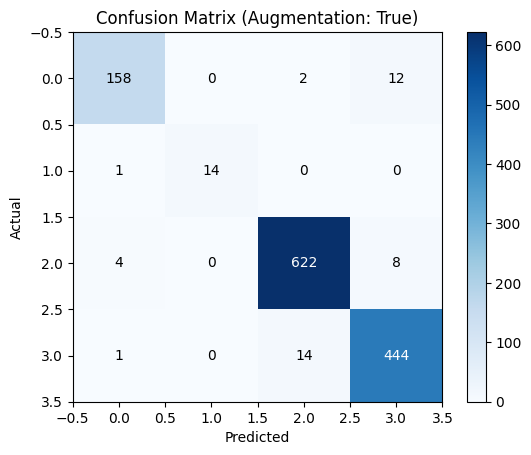

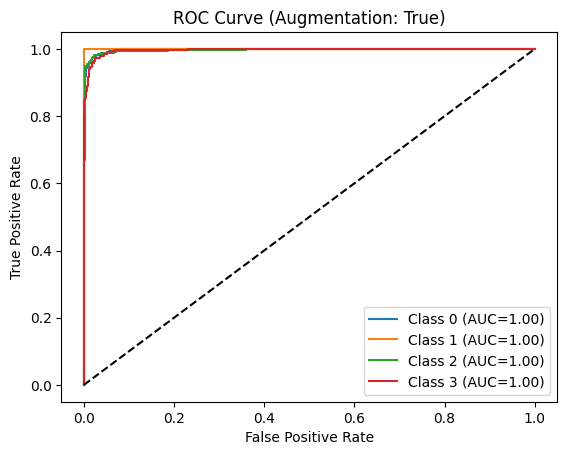

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAG
# ==========================================
# UBAH FLAG INI UNTUK SKENARIO EKSPERIMEN:
# False = Tanpa Augmentasi | True = Dengan Augmentasi
USE_AUGMENTATION = True

CONFIG = {
    "lr": 0.0001,           # Sesuai standar Fase 1
    "batch_size": 16,       # Terkunci sesuai kapasitas VRAM
    "epochs": 25,           # Sesuai standar Fase 1
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Augmentation: {USE_AUGMENTATION}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"] # 5120 data
test_data = hf_dataset["test"]      # 1280 data

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")
train_labels = np.array(train_data["label"])

# ==========================================
# 3. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]

        if self.transform:
            image = self.transform(image)

        return image, label

# ==========================================
# 4. TRANSFORM (SKENARIO AUGMENTASI)
# ==========================================
# Transform dasar untuk Validasi dan Testing (TIDAK BOLEH DIAUGMENTASI)
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    print("Menerapkan Augmentasi Data pada Training Set...")
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    print("TIDAK Menerapkan Augmentasi Data pada Training Set...")
    train_transform = val_test_transform # Hanya Resize, ToTensor, Normalize

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# Catatan: Sampler dinonaktifkan di Fase 1 Tabel 1.1 untuk isolasi perlakuan
train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Baseline Fine-Tuning: Unfreeze 10 layer terakhir
for param in model.features[-10:].parameters():
    param.requires_grad = True

num_classes = len(np.unique(train_labels))

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)

model = model.to(device)

# ==========================================
# 6. LOSS & OPTIMIZER
# ==========================================
# Catatan: Class Weight dinonaktifkan di Tabel 1.1
criterion = nn.CrossEntropyLoss()

# Sesuai kesepakatan Fase 1: Optimizer Adam
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("Start training...")

best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):

    # ===== TRAIN =====
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total
    scheduler.step()

    # ===== VALIDATION =====
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # ===== EARLY STOPPING =====
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_aug_{USE_AUGMENTATION}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("\n=== TEST CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Augmentation: {USE_AUGMENTATION})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Augmentation: {USE_AUGMENTATION})")
plt.legend(loc="lower right")
plt.show()

HAndling IMbalance Dataset
1/ None

Device: cuda | Augmentation: True | Imbalance Strategy: none
Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Train: 4096 | Val: 1024 | Test: 1280
-> Tidak menggunakan Sampler (Normal Shuffle)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 108MB/s]


-> Menggunakan Standard Loss Function (Tanpa Class Weight)...

Mulai Training...
Epoch 1/25 | Train Loss: 0.9608 Acc: 0.5137 | Val Loss: 0.8715 Acc: 0.5752
Epoch 2/25 | Train Loss: 0.8487 Acc: 0.6006 | Val Loss: 0.9298 Acc: 0.5195
Epoch 3/25 | Train Loss: 0.7846 Acc: 0.6377 | Val Loss: 0.7811 Acc: 0.6416
Epoch 4/25 | Train Loss: 0.6703 Acc: 0.6956 | Val Loss: 0.6382 Acc: 0.7285
Epoch 5/25 | Train Loss: 0.5325 Acc: 0.7786 | Val Loss: 0.5618 Acc: 0.7686
Epoch 6/25 | Train Loss: 0.3707 Acc: 0.8513 | Val Loss: 0.4031 Acc: 0.8291
Epoch 7/25 | Train Loss: 0.2731 Acc: 0.9001 | Val Loss: 0.4161 Acc: 0.8457
Epoch 8/25 | Train Loss: 0.1765 Acc: 0.9319 | Val Loss: 0.2510 Acc: 0.9111
Epoch 9/25 | Train Loss: 0.1144 Acc: 0.9573 | Val Loss: 0.2025 Acc: 0.9443
Epoch 10/25 | Train Loss: 0.0931 Acc: 0.9663 | Val Loss: 0.1790 Acc: 0.9404
Epoch 11/25 | Train Loss: 0.0505 Acc: 0.9797 | Val Loss: 0.3177 Acc: 0.9385
Epoch 12/25 | Train Loss: 0.0527 Acc: 0.9802 | Val Loss: 0.1690 Acc: 0.9541
Epoch 13/25 | Tr

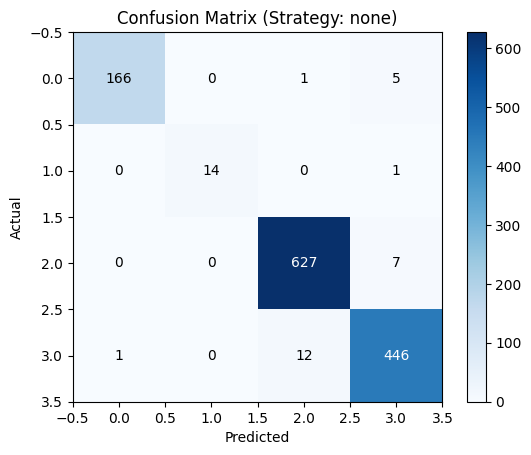

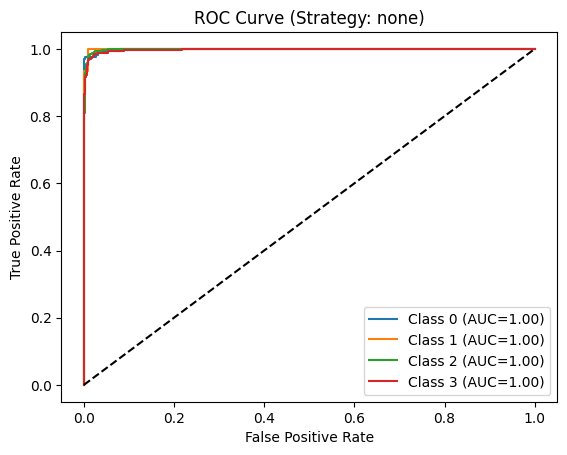

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True  # Dikunci TRUE berdasarkan hasil eksperimen Tabel 1.1

# UBAH STRATEGI INI UNTUK EKSPERIMEN TABEL 1.2:
# Pilih salah satu: "none" | "class_weight" | "sampler"
IMBALANCE_STRATEGY = "none"

CONFIG = {
    "lr": 0.0001,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Augmentation: {USE_AUGMENTATION} | Imbalance Strategy: {IMBALANCE_STRATEGY}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
# Normalisasi bobot (opsional tapi disarankan agar loss tidak terlalu meledak)
class_weights = class_weights / class_weights.sum() * num_classes

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 5. TRANSFORM (AUGMENTASI DIKUNCI ON)
# ==========================================
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER & SAMPLER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    # Jika pakai sampler, shuffle WAJIB bernilai False
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> Tidak menggunakan Sampler (Normal Shuffle)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

# Val dan Test selalu normal
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

for param in model.features[-10:].parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS & OPTIMIZER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    print("-> Menggunakan Standard Loss Function (Tanpa Class Weight)...")
    criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total
    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_strategy_{IMBALANCE_STRATEGY}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({IMBALANCE_STRATEGY.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Strategy: {IMBALANCE_STRATEGY})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Strategy: {IMBALANCE_STRATEGY})")
plt.legend(loc="lower right")
plt.show()

CLASS WEIGHT + DATA AUGMENTATION

Device: cuda | Augmentation: True | Imbalance Strategy: class_weight
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280
-> Tidak menggunakan Sampler (Normal Shuffle)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | Train Loss: 1.3552 Acc: 0.3452 | Val Loss: 1.3306 Acc: 0.3477
Epoch 2/25 | Train Loss: 1.3549 Acc: 0.3579 | Val Loss: 1.3135 Acc: 0.3477
Epoch 3/25 | Train Loss: 1.3384 Acc: 0.3606 | Val Loss: 1.3280 Acc: 0.3477
Epoch 4/25 | Train Loss: 1.3449 Acc: 0.4004 | Val Loss: 1.3167 Acc: 0.3477
Epoch 5/25 | Train Loss: 1.3324 Acc: 0.3774 | Val Loss: 1.3174 Acc: 0.5010
Epoch 6/25 | Train Loss: 1.3284 Acc: 0.4023 | Val Loss: 1.3144 Acc: 0.3477
Epoch 7/25 | Train Loss: 1.3225 Acc: 0.4395 | Val Loss: 1.3151 Acc: 0.3477
Epoch 8/25 | Train Loss: 1.3239 Acc: 0.3743 | Val Loss: 1.3134 Acc: 0.5010
Epoch 9/25 | Train Loss: 1.3227 Acc: 0.4199 | Val Loss: 1.3139 Acc: 0.3477
Epoch 10/25 | Train Loss: 1.3214 Acc: 0.3938 | Val Loss: 1.313

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


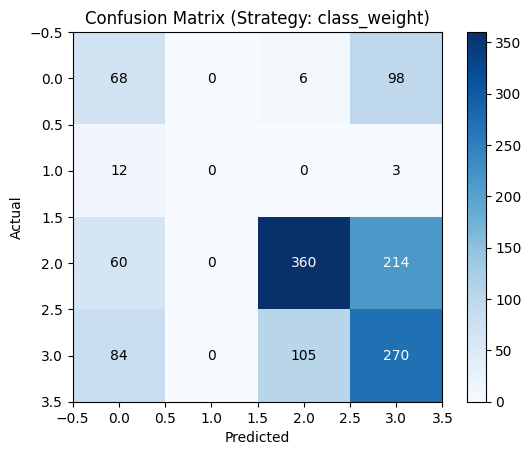

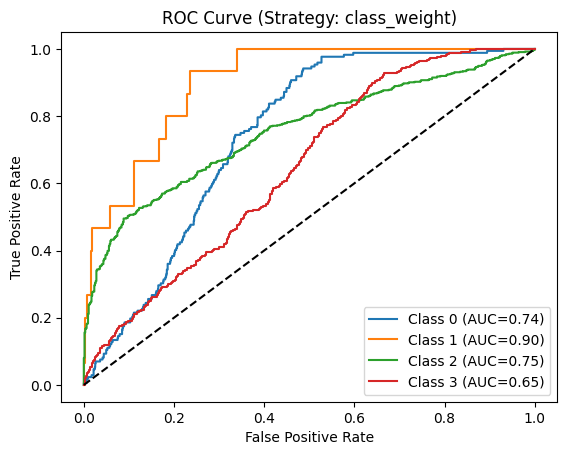

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True  # Dikunci TRUE berdasarkan hasil eksperimen Tabel 1.1

# UBAH STRATEGI INI UNTUK EKSPERIMEN TABEL 1.2:
# Pilih salah satu: "none" | "class_weight" | "sampler"
IMBALANCE_STRATEGY = "class_weight"

CONFIG = {
    "lr": 0.0001,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Augmentation: {USE_AUGMENTATION} | Imbalance Strategy: {IMBALANCE_STRATEGY}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
# Normalisasi bobot (opsional tapi disarankan agar loss tidak terlalu meledak)
class_weights = class_weights / class_weights.sum() * num_classes

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 5. TRANSFORM (AUGMENTASI DIKUNCI ON)
# ==========================================
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER & SAMPLER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    # Jika pakai sampler, shuffle WAJIB bernilai False
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> Tidak menggunakan Sampler (Normal Shuffle)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

# Val dan Test selalu normal
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

for param in model.features[-10:].parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS & OPTIMIZER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    print("-> Menggunakan Standard Loss Function (Tanpa Class Weight)...")
    criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total
    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_strategy_{IMBALANCE_STRATEGY}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({IMBALANCE_STRATEGY.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Strategy: {IMBALANCE_STRATEGY})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Strategy: {IMBALANCE_STRATEGY})")
plt.legend(loc="lower right")
plt.show()

Data Augmentation + Weighted Random Sampler

Device: cuda | Augmentation: True | Imbalance Strategy: sampler
Loading dataset...
Train: 4096 | Val: 1024 | Test: 1280
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...
-> Menggunakan Standard Loss Function (Tanpa Class Weight)...

Mulai Training...
Epoch 1/25 | Train Loss: 1.0972 Acc: 0.4497 | Val Loss: 1.0889 Acc: 0.4629
Epoch 2/25 | Train Loss: 0.7181 Acc: 0.6445 | Val Loss: 1.1873 Acc: 0.3643
Epoch 3/25 | Train Loss: 0.6231 Acc: 0.7139 | Val Loss: 0.7561 Acc: 0.6270
Epoch 4/25 | Train Loss: 0.5405 Acc: 0.7622 | Val Loss: 0.7775 Acc: 0.6455
Epoch 5/25 | Train Loss: 0.4181 Acc: 0.8235 | Val Loss: 0.7528 Acc: 0.7168
Epoch 6/25 | Train Loss: 0.3565 Acc: 0.8525 | Val Loss: 0.5443 Acc: 0.7510
Epoch 7/25 | Train Loss: 0.2588 Acc: 0.8958 | Val Loss: 0.3288 Acc: 0.8682
Epoch 8/25 | Train Loss: 0.2215 Acc: 0.9087 | Val Loss: 0.4253 Acc: 0.8438
Epoch 9/25 | Train Loss: 0.1620 Acc: 0.9370 | Val Loss: 0.4072 Acc: 0.8545
Epoch 10/25 | Train Loss: 0.1353 Acc: 0.9473 |

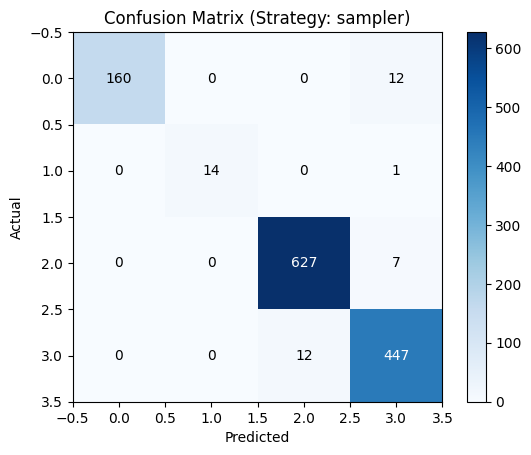

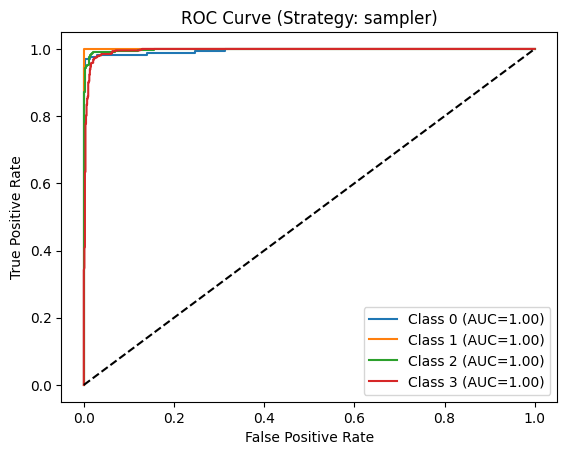

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True  # Dikunci TRUE berdasarkan hasil eksperimen Tabel 1.1

# UBAH STRATEGI INI UNTUK EKSPERIMEN TABEL 1.2:
# Pilih salah satu: "none" | "class_weight" | "sampler"
IMBALANCE_STRATEGY = "sampler"

CONFIG = {
    "lr": 0.0001,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Augmentation: {USE_AUGMENTATION} | Imbalance Strategy: {IMBALANCE_STRATEGY}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))
print(f"Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}")

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
# Normalisasi bobot (opsional tapi disarankan agar loss tidak terlalu meledak)
class_weights = class_weights / class_weights.sum() * num_classes

# ==========================================
# 4. DATASET WRAPPER
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

# ==========================================
# 5. TRANSFORM (AUGMENTASI DIKUNCI ON)
# ==========================================
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER & SAMPLER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    sample_weights = class_weights[train_labels]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
    # Jika pakai sampler, shuffle WAJIB bernilai False
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> Tidak menggunakan Sampler (Normal Shuffle)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

# Val dan Test selalu normal
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

for param in model.features[-10:].parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS & OPTIMIZER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    print("-> Menggunakan Standard Loss Function (Tanpa Class Weight)...")
    criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total
    scheduler.step()

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_strategy_{IMBALANCE_STRATEGY}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({IMBALANCE_STRATEGY.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Strategy: {IMBALANCE_STRATEGY})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (Strategy: {IMBALANCE_STRATEGY})")
plt.legend(loc="lower right")
plt.show()

TERBAIK SAAT INI:1. None (98) 2. Weighted Random Sampler (97)

SKENARIO Fine Tuning Model 1 (Freeze All)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# UBAH FLAG INI UNTUK SKENARIO V-1, V-2, V-3:
# Pilih: "freeze_all" (V-1) | "unfreeze_last" (V-2) | "full_tuning" (V-3)
FINE_TUNE_LEVEL = "freeze_all"

# Dinamis menentukan LR berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4  # LR standar untuk melatih classifier dari nol
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5  # LR kecil untuk fine-tune sebagian layer
else: # full_tuning
    current_lr = 1e-5  # LR sangat kecil agar pre-trained weight tidak hancur

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Strategy: {IMBALANCE_STRATEGY} | Fine-Tuning: {FINE_TUNE_LEVEL} | LR: {CONFIG['lr']}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Logic Fine-Tuning Skenario
if FINE_TUNE_LEVEL == "freeze_all":
    # V-1: Freeze semua fitur ekstraktor, hanya latih classifier
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    # V-2: Bekukan semua, lalu buka (unfreeze) 10 layer terakhir
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    # V-3: Buka semua layer (semua parameter diupdate)
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER
# ==========================================
criterion = nn.CrossEntropyLoss()

# Optimizer dikunci ke Adam untuk Tahap 1
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])

# Scheduler diubah ke ReduceLROnPlateau
# Scheduler ini akan menurunkan LR sebesar factor (0.5) jika val_loss tidak membaik selama patience (3 epoch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 PENTING: ReduceLROnPlateau membutuhkan val_loss untuk melakukan step
    scheduler.step(val_loss)

    # Mendapatkan LR saat ini untuk ditampilkan (opsional, agar terlihat perubahannya)
    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_{FINE_TUNE_LEVEL}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({FINE_TUNE_LEVEL.upper()}) ===")
print(classification_report(all_labels, all_preds))

Device: cuda | Strategy: sampler | Fine-Tuning: freeze_all | LR: 0.0001
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.0669 Acc: 0.5098 | Val Loss: 0.8756 Acc: 0.5830
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 0.7890 Acc: 0.6235 | Val Loss: 0.9864 Acc: 0.4824
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 0.7296 Acc: 0.6643 | Val Loss: 0.8633 Acc: 0.5889
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 0.6980 Acc: 0.6768 | Val Loss: 0.8270 Acc: 0.6074
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.6547 Acc: 0.7009 | Val Loss: 0.7865 Acc: 0.6426
Epoch 6/25 | LR: 1.00e-04 | Train Loss: 0.6485 Acc: 0.6946 | Val Loss: 0.7910 Acc: 0.6377
Epoch 7/25 | LR: 1.00e-04 | Train Loss: 0.6158 Acc: 0.7222 | Val Loss: 0.7430 Acc: 0.6416
Epoch 8/25 | LR: 1.00e-04 | Train Loss: 0.6014 Acc: 0.7402 | Val Loss: 0.7584 Acc: 0.6357
Epoch 9/25 | LR: 1.00e-04 | Train Loss: 0.5866 Acc: 0.7385 | Val Loss: 0.7028 Acc: 0.6641
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.5644 Acc: 0.7471

Data Augmentation + Weighted Random SAMPLER + Fine tuning model 2 (Unfreeze last layer)

Device: cuda | Strategy: sampler | Fine-Tuning: unfreeze_last | LR: 5e-05
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 0.8615 Acc: 0.5945 | Val Loss: 0.7814 Acc: 0.6230
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 0.5981 Acc: 0.7292 | Val Loss: 0.9948 Acc: 0.5801
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.4857 Acc: 0.7908 | Val Loss: 0.6320 Acc: 0.7158
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.4085 Acc: 0.8250 | Val Loss: 0.8306 Acc: 0.5967
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.3217 Acc: 0.8701 | Val Loss: 0.7082 Acc: 0.7227
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 0.2909 Acc: 0.8831 | Val Loss: 0.6061 Acc: 0.7637
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 0.2498 Acc: 0.9060 | Val Loss: 0.4951 Acc: 0.8105
Epoch 8/25 | LR: 5.00e-05 | Train Loss: 0.2242 Acc: 0.9150 | Val Loss: 0.4236 Acc: 0.8281
Epoch 9/25 | LR: 5.00e-05 | Train Loss: 0.1858 Acc: 0.9250 | Val Loss: 0.4210 Acc: 0.8281
Epoch 10/25 | LR: 5.00e-05 | Train Loss: 0.1684 Acc: 0.93

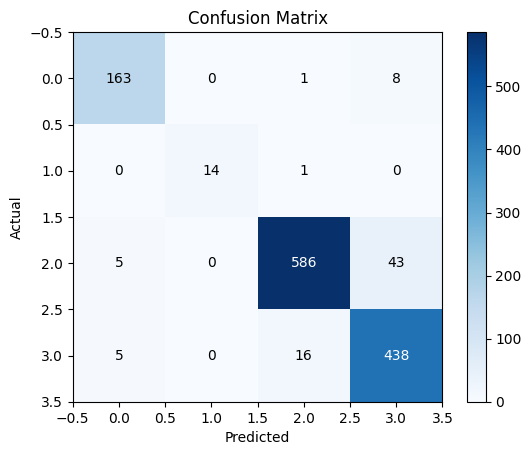

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# UBAH FLAG INI UNTUK SKENARIO V-1, V-2, V-3:
# Pilih: "freeze_all" (V-1) | "unfreeze_last" (V-2) | "full_tuning" (V-3)
FINE_TUNE_LEVEL = "unfreeze_last"

# Dinamis menentukan LR berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4  # LR standar untuk melatih classifier dari nol
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5  # LR kecil untuk fine-tune sebagian layer
else: # full_tuning
    current_lr = 1e-5  # LR sangat kecil agar pre-trained weight tidak hancur

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Strategy: {IMBALANCE_STRATEGY} | Fine-Tuning: {FINE_TUNE_LEVEL} | LR: {CONFIG['lr']}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Logic Fine-Tuning Skenario
if FINE_TUNE_LEVEL == "freeze_all":
    # V-1: Freeze semua fitur ekstraktor, hanya latih classifier
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    # V-2: Bekukan semua, lalu buka (unfreeze) 10 layer terakhir
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    # V-3: Buka semua layer (semua parameter diupdate)
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER
# ==========================================
criterion = nn.CrossEntropyLoss()

# Optimizer dikunci ke Adam untuk Tahap 1
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])

# Scheduler diubah ke ReduceLROnPlateau
# Scheduler ini akan menurunkan LR sebesar factor (0.5) jika val_loss tidak membaik selama patience (3 epoch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 PENTING: ReduceLROnPlateau membutuhkan val_loss untuk melakukan step
    scheduler.step(val_loss)

    # Mendapatkan LR saat ini untuk ditampilkan (opsional, agar terlihat perubahannya)
    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_{FINE_TUNE_LEVEL}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({FINE_TUNE_LEVEL.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

DATA AUGMENTATION + Weighted Random Sampler + Fine Tuning Model 3 (ALL OPEN)

Device: cuda | Strategy: sampler | Fine-Tuning: full_tuning | LR: 1e-05
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 0.9447 Acc: 0.5581 | Val Loss: 0.9658 Acc: 0.5576
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 0.5697 Acc: 0.7458 | Val Loss: 0.8443 Acc: 0.6006
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.4592 Acc: 0.7964 | Val Loss: 0.6594 Acc: 0.7158
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.3545 Acc: 0.8586 | Val Loss: 0.5170 Acc: 0.7900
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.2744 Acc: 0.8892 | Val Loss: 0.5235 Acc: 0.7910
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 0.2229 Acc: 0.9087 | Val Loss: 0.4045 Acc: 0.8340
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 0.1667 Acc: 0.9355 | Val Loss: 0.3660 Acc: 0.8682
Epoch 8/25 | LR: 1.00e-05 | Train Loss: 0.1403 Acc: 0.9490 | Val Loss: 0.2703 Acc: 0.9033
Epoch 9/25 | LR: 1.00e-05 | Train Loss: 0.1106 Acc: 0.9575 | Val Loss: 0.2220 Acc: 0.9219
Epoch 10/25 | LR: 1.00e-05 | Train Loss: 0.0859 Acc: 0.9670

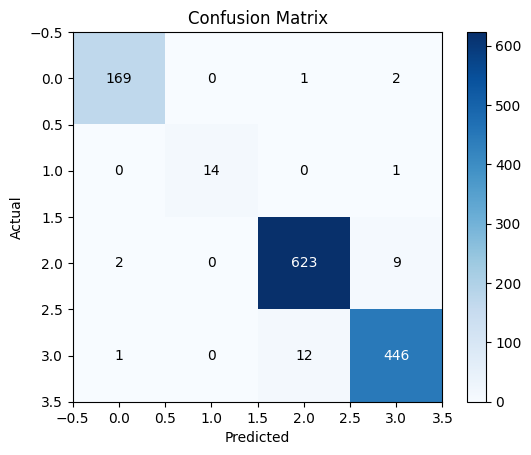

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# UBAH FLAG INI UNTUK SKENARIO V-1, V-2, V-3:
# Pilih: "freeze_all" (V-1) | "unfreeze_last" (V-2) | "full_tuning" (V-3)
FINE_TUNE_LEVEL = "full_tuning"

# Dinamis menentukan LR berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4  # LR standar untuk melatih classifier dari nol
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5  # LR kecil untuk fine-tune sebagian layer
else: # full_tuning
    current_lr = 1e-5  # LR sangat kecil agar pre-trained weight tidak hancur

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Strategy: {IMBALANCE_STRATEGY} | Fine-Tuning: {FINE_TUNE_LEVEL} | LR: {CONFIG['lr']}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Logic Fine-Tuning Skenario
if FINE_TUNE_LEVEL == "freeze_all":
    # V-1: Freeze semua fitur ekstraktor, hanya latih classifier
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    # V-2: Bekukan semua, lalu buka (unfreeze) 10 layer terakhir
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    # V-3: Buka semua layer (semua parameter diupdate)
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER
# ==========================================
criterion = nn.CrossEntropyLoss()

# Optimizer dikunci ke Adam untuk Tahap 1
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])

# Scheduler diubah ke ReduceLROnPlateau
# Scheduler ini akan menurunkan LR sebesar factor (0.5) jika val_loss tidak membaik selama patience (3 epoch)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 PENTING: ReduceLROnPlateau membutuhkan val_loss untuk melakukan step
    scheduler.step(val_loss)

    # Mendapatkan LR saat ini untuk ditampilkan (opsional, agar terlihat perubahannya)
    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_{FINE_TUNE_LEVEL}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({FINE_TUNE_LEVEL.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

DATA Augmentation + Weighted Random Sampler + Full Tuning + Optimizer (ADAM)

Device: cuda | Optimizer: ADAM | Fine-Tuning: full_tuning
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 0.9152 Acc: 0.5708 | Val Loss: 0.8303 Acc: 0.6201
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 0.6164 Acc: 0.7271 | Val Loss: 0.8490 Acc: 0.5957
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.4805 Acc: 0.7920 | Val Loss: 0.5528 Acc: 0.7764
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.3746 Acc: 0.8442 | Val Loss: 0.5839 Acc: 0.7559
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.2784 Acc: 0.8855 | Val Loss: 0.6051 Acc: 0.7461
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 0.2355 Acc: 0.9077 | Val Loss: 0.3837 Acc: 0.8398
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 0.1903 Acc: 0.9219 | Val Loss: 0.3021 Acc: 0.8799
Epoch 8/25 | LR: 1.00e-05 | Train Loss: 0.1553 Acc: 0.9414 | Val Loss: 0.4072 Acc: 0.8418
Epoch 9/25 | LR: 1.00e-05 | Train Loss: 0.1250 Acc: 0.9548 | Val Loss: 0.3361 Acc: 0.8682
Epoch 10/25 | LR: 1.00e-05 | Train Loss: 0.0825 Acc: 0.9712 | Val Loss: 0

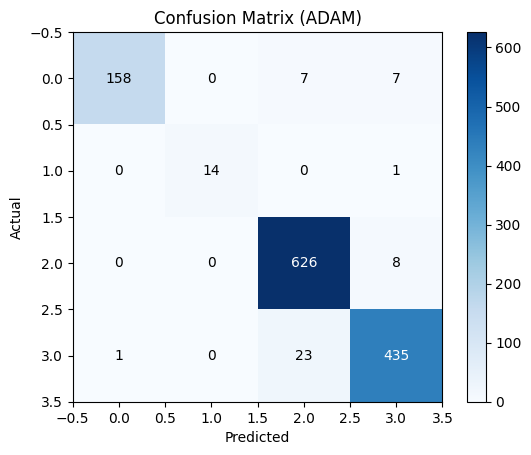

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"
FINE_TUNE_LEVEL = "full_tuning"  # Dikunci berdasarkan pemenang Tahap 1

# 🔥 UBAH FLAG INI UNTUK SKENARIO V-4, V-5, V-6:
# Pilih: "adam" (V-4) | "adamw" (V-5) | "sgd" (V-6)
OPTIMIZER_TYPE = "adam"

CONFIG = {
    "lr": 1e-5,  # Dikunci di 1e-5 karena menggunakan full_tuning
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Optimizer: {OPTIMIZER_TYPE.upper()} | Fine-Tuning: {FINE_TUNE_LEVEL}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Terkunci di Full Tuning
for param in model.features.parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER
# ==========================================
criterion = nn.CrossEntropyLoss()

# 🔥 Logic Pemilihan Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)
    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_full_tuning_{OPTIMIZER_TYPE}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({OPTIMIZER_TYPE.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

Data Augmentation + Weighted Random Sampler + Full Tuning + Optimizer (AdamW)

Device: cuda | Optimizer: ADAMW | Fine-Tuning: full_tuning
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 0.9094 Acc: 0.5784 | Val Loss: 0.7951 Acc: 0.6064
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 0.6171 Acc: 0.7148 | Val Loss: 0.7030 Acc: 0.6582
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.4765 Acc: 0.7915 | Val Loss: 0.6678 Acc: 0.6943
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.3437 Acc: 0.8569 | Val Loss: 0.6429 Acc: 0.7139
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.2946 Acc: 0.8740 | Val Loss: 0.4018 Acc: 0.8271
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 0.2319 Acc: 0.9053 | Val Loss: 0.4452 Acc: 0.8135
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 0.1776 Acc: 0.9343 | Val Loss: 0.2706 Acc: 0.8848
Epoch 8/25 | LR: 1.00e-05 | Train Loss: 0.1454 Acc: 0.9463 | Val Loss: 0.2984 Acc: 0.8838
Epoch 9/25 | LR: 1.00e-05 | Train Loss: 0.1089 Acc: 0.9607 | Val Loss: 0.1846 Acc: 0.9316
Epoch 10/25 | LR: 1.00e-05 | Train Loss: 0.0953 Acc: 0.9636 | Val Loss: 

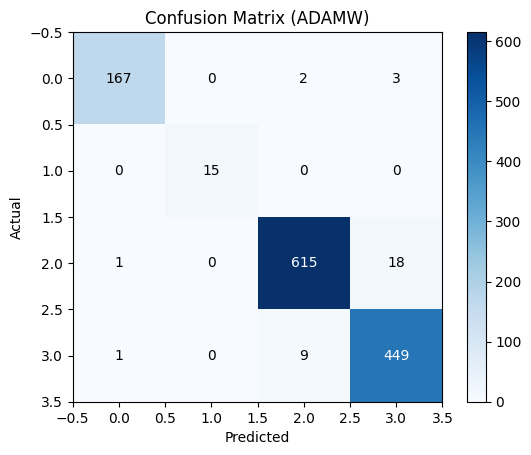

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"
FINE_TUNE_LEVEL = "full_tuning"  # Dikunci berdasarkan pemenang Tahap 1

# 🔥 UBAH FLAG INI UNTUK SKENARIO V-4, V-5, V-6:
# Pilih: "adam" (V-4) | "adamw" (V-5) | "sgd" (V-6)
OPTIMIZER_TYPE = "adamw"

CONFIG = {
    "lr": 1e-5,  # Dikunci di 1e-5 karena menggunakan full_tuning
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Optimizer: {OPTIMIZER_TYPE.upper()} | Fine-Tuning: {FINE_TUNE_LEVEL}")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

# Terkunci di Full Tuning
for param in model.features.parameters():
    param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER
# ==========================================
criterion = nn.CrossEntropyLoss()

# 🔥 Logic Pemilihan Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)
    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)
torch.save(model.state_dict(), f"best_vgg19_full_tuning_{OPTIMIZER_TYPE}.pth")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ({OPTIMIZER_TYPE.upper()}) ===")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# Weighted Random Sampler + AUG (12 Skenarios)

ALL SKENARIO (Freeze All)

S-02

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : freeze_all
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 0.0001
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.0804 Acc: 0.5068 | Val Loss: 1.1656 Acc: 0.4307
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 0.8030 Acc: 0.6184 | Val Loss: 1.1050 Acc: 0.4639
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 0.7392 Acc: 0.6531 | Val Loss: 0.7877 Acc: 0.5996
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 0.6921 Acc: 0.6802 | Val Loss: 0.8113 Acc: 0.6211
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.6581 Acc: 0.6909 | Val Loss: 0.7444 Acc: 0.6494
Epoch 6/25 | LR: 8.64e-05 | Train Loss: 0.6338 Acc: 0.7048 | Val Loss: 0.7562 Acc: 0.6426
Epoch 7/25 | LR: 8.19e-05 | Train Loss: 0.6133 Acc: 0.7146 | Val Loss: 0.7532 Acc: 0.6318
Epoch 8/25 | LR: 7.68e-05 | Train Loss: 0.5707 Acc: 0.7393 | Val Loss: 0.7566 Acc: 0.6582
Epoch 9/25 | LR: 7.13e-05 | Train Loss: 0.5588 Acc: 0.

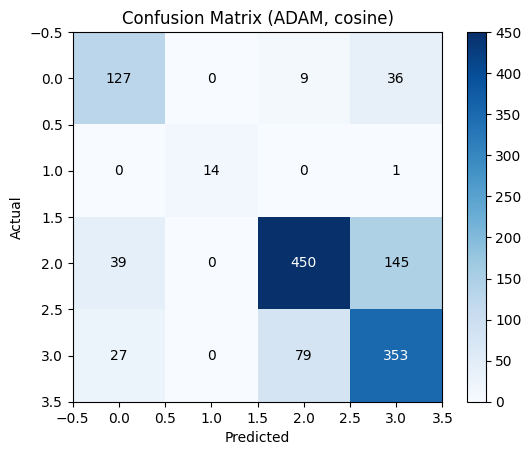

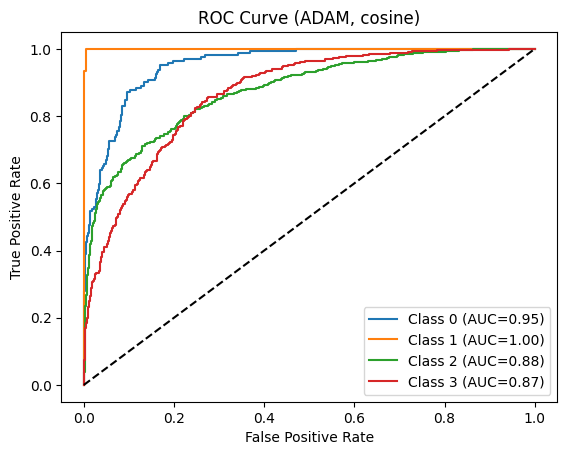

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-03

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.0958 Acc: 0.4919 | Val Loss: 0.9007 Acc: 0.5830
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 0.7876 Acc: 0.6331 | Val Loss: 0.9336 Acc: 0.5400
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 0.7414 Acc: 0.6572 | Val Loss: 0.8778 Acc: 0.5947
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 0.6942 Acc: 0.6772 | Val Loss: 0.8123 Acc: 0.6133
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.6638 Acc: 0.6951 | Val Loss: 0.9145 Acc: 0.5547
Epoch 6/25 | LR: 1.00e-04 | Train Loss: 0.6461 Acc: 0.7012 | Val Loss: 0.8429 Acc: 0.5801
Epoch 7/25 | LR: 1.00e-04 | Train Loss: 0.5950 Acc: 0.7280 | Val Loss: 0.8211 Acc: 0.6250
Epoch 8/25 | LR: 5.00e-05 | Train Loss: 0.6041 Acc: 0.7266 | Val Loss: 0.8170 Acc: 0.5986
Epoch 9/25 | LR: 5.00e-05 | Train Loss: 0.5250 Acc

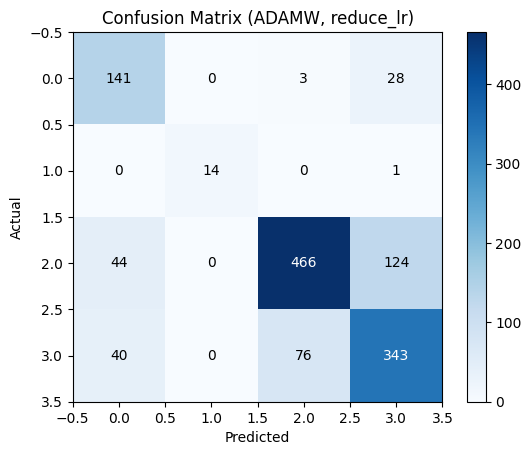

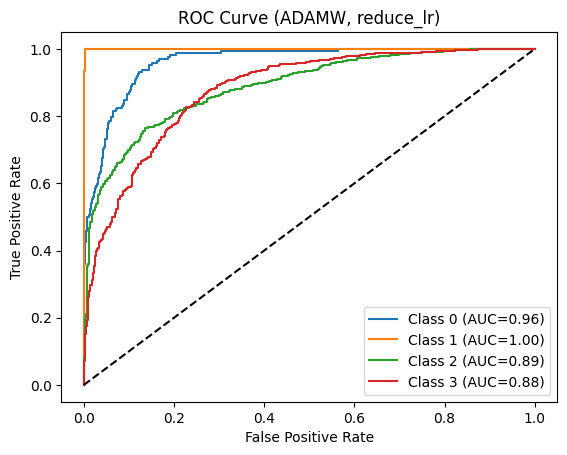

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-04

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 0.0001
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.0655 Acc: 0.5063 | Val Loss: 0.9523 Acc: 0.5459
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 0.7868 Acc: 0.6245 | Val Loss: 1.1537 Acc: 0.4346
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 0.7269 Acc: 0.6606 | Val Loss: 0.9270 Acc: 0.5576
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 0.6951 Acc: 0.6741 | Val Loss: 0.7699 Acc: 0.6289
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.6627 Acc: 0.6907 | Val Loss: 0.7991 Acc: 0.6299
Epoch 6/25 | LR: 8.64e-05 | Train Loss: 0.6437 Acc: 0.7117 | Val Loss: 0.9438 Acc: 0.5479
Epoch 7/25 | LR: 8.19e-05 | Train Loss: 0.5967 Acc: 0.7290 | Val Loss: 0.7235 Acc: 0.6660
Epoch 8/25 | LR: 7.68e-05 | Train Loss: 0.5861 Acc: 0.7346 | Val Loss: 0.7142 Acc: 0.6758
Epoch 9/25 | LR: 7.13e-05 | Train Loss: 0.5630 Acc: 0

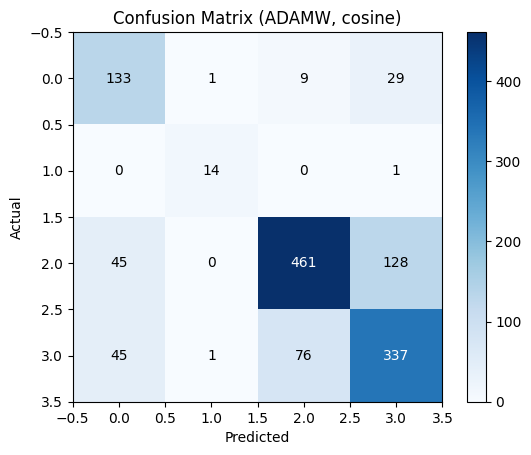

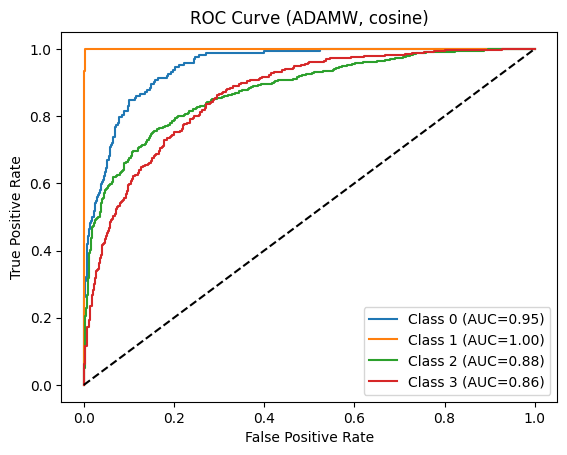

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-05

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.3463 Acc: 0.3562 | Val Loss: 1.2334 Acc: 0.4873
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2566 Acc: 0.4683 | Val Loss: 1.2650 Acc: 0.3887
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.1113 Acc: 0.5464 | Val Loss: 1.1284 Acc: 0.5078
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.0015 Acc: 0.5815 | Val Loss: 1.0273 Acc: 0.5684
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.9454 Acc: 0.5889 | Val Loss: 0.9646 Acc: 0.5703
Epoch 6/25 | LR: 1.00e-04 | Train Loss: 0.8719 Acc: 0.6179 | Val Loss: 0.9255 Acc: 0.5762
Epoch 7/25 | LR: 1.00e-04 | Train Loss: 0.8259 Acc: 0.6340 | Val Loss: 0.9746 Acc: 0.5654
Epoch 8/25 | LR: 1.00e-04 | Train Loss: 0.7895 Acc: 0.6465 | Val Loss: 0.9881 Acc: 0.5420
Epoch 9/25 | LR: 1.00e-04 | Train Loss: 0.7722 Acc: 

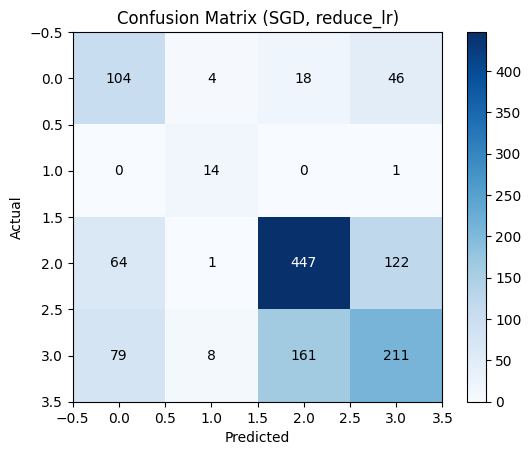

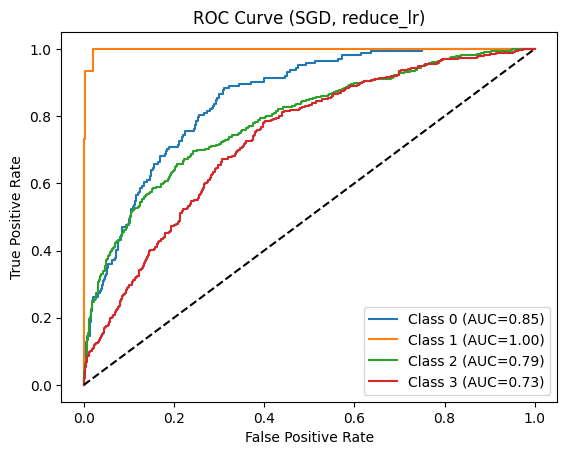

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-06

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 0.0001
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.3561 Acc: 0.3303 | Val Loss: 1.2926 Acc: 0.4453
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.2541 Acc: 0.4844 | Val Loss: 1.1871 Acc: 0.4971
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.1287 Acc: 0.5364 | Val Loss: 1.0581 Acc: 0.5430
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 1.0125 Acc: 0.5752 | Val Loss: 1.0056 Acc: 0.5508
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.9294 Acc: 0.6025 | Val Loss: 0.9950 Acc: 0.5576
Epoch 6/25 | LR: 8.64e-05 | Train Loss: 0.8887 Acc: 0.6091 | Val Loss: 1.0470 Acc: 0.5166
Epoch 7/25 | LR: 8.19e-05 | Train Loss: 0.8443 Acc: 0.6252 | Val Loss: 0.9990 Acc: 0.5215
Epoch 8/25 | LR: 7.68e-05 | Train Loss: 0.8159 Acc: 0.6331 | Val Loss: 0.9853 Acc: 0.5469
Epoch 9/25 | LR: 7.13e-05 | Train Loss: 0.7751 Acc: 0.6

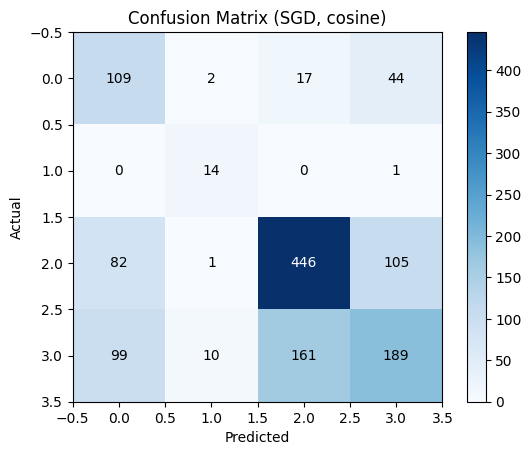

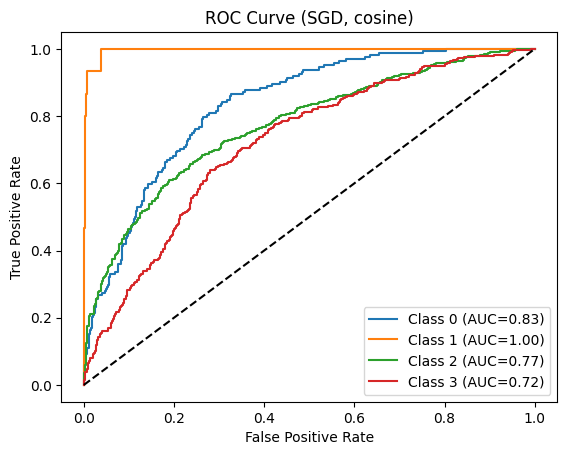

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Unfreeze Last Skenarios

S-08

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : unfreeze_last
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 5e-05
------------------------------
Loading dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 74.9MB/s]



Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 0.8720 Acc: 0.5884 | Val Loss: 0.7796 Acc: 0.6309
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 0.5776 Acc: 0.7402 | Val Loss: 0.7544 Acc: 0.6660
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.4822 Acc: 0.7910 | Val Loss: 0.6336 Acc: 0.7031
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.3878 Acc: 0.8340 | Val Loss: 0.6699 Acc: 0.7344
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.3229 Acc: 0.8696 | Val Loss: 0.7718 Acc: 0.7021
Epoch 6/25 | LR: 4.32e-05 | Train Loss: 0.2891 Acc: 0.8813 | Val Loss: 0.5614 Acc: 0.7793
Epoch 7/25 | LR: 4.09e-05 | Train Loss: 0.2368 Acc: 0.9055 | Val Loss: 0.5467 Acc: 0.7812
Epoch 8/25 | LR: 3.84e-05 | Train Loss: 0.2075 Acc: 0.9233 | Val Loss: 0.4841 Acc: 0.7959
Epoch 9/25 | LR: 3.56e-05 | Train Loss: 0.1566 Acc: 0.9382 | Val Loss: 0.3552 Acc: 0.8457
Epoch 10/25 | LR: 3.27e-05 | Train Loss: 0.1367 Acc: 0.9487 | Val Loss: 0.3502 Acc: 0.8633
Epoch 11/25 | LR: 2.97e-05 | Train Loss: 0.1276 Acc: 0.9521 | Val Loss: 0.4029 A

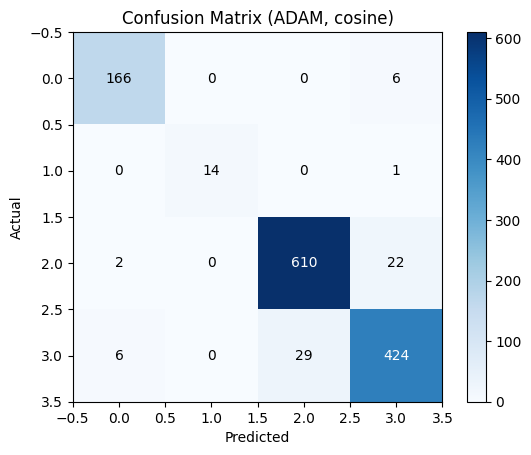

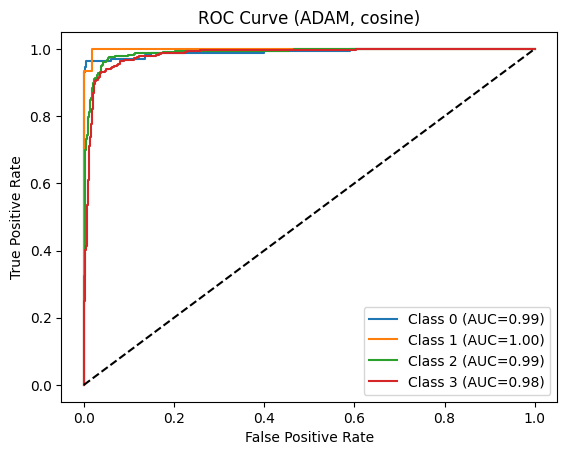

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-09

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 0.8951 Acc: 0.5759 | Val Loss: 0.8127 Acc: 0.5908
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 0.5891 Acc: 0.7415 | Val Loss: 0.7196 Acc: 0.6504
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.4823 Acc: 0.7922 | Val Loss: 0.6607 Acc: 0.7021
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.3973 Acc: 0.8362 | Val Loss: 0.6068 Acc: 0.7119
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.3228 Acc: 0.8708 | Val Loss: 0.5467 Acc: 0.7451
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 0.2994 Acc: 0.8796 | Val Loss: 0.4507 Acc: 0.8018
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 0.2345 Acc: 0.9082 | Val Loss: 0.4336 Acc: 0.8252
Epoch 8/25 | LR: 5.00e-05 | Train Loss: 0.2179 Acc: 0.9126 | Val Loss: 0.4108 Acc: 0.8320
Epoch 9/25 | LR: 5.00e-05 | Train Loss: 0.2009 A

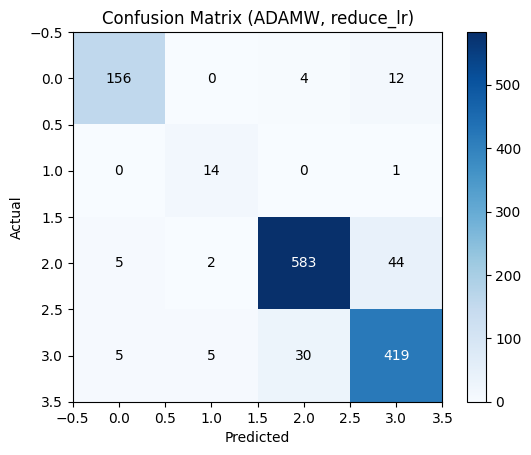

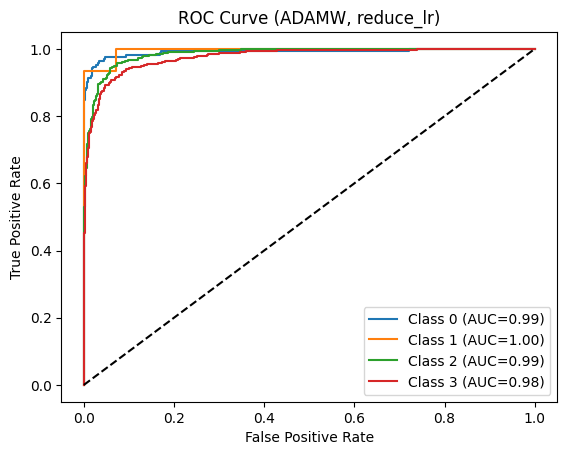

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-10

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 5e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 0.8946 Acc: 0.5879 | Val Loss: 0.9659 Acc: 0.5234
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 0.6090 Acc: 0.7256 | Val Loss: 0.7268 Acc: 0.6445
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.4898 Acc: 0.7920 | Val Loss: 0.6927 Acc: 0.6963
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.4227 Acc: 0.8225 | Val Loss: 0.6742 Acc: 0.7256
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.3552 Acc: 0.8521 | Val Loss: 0.5621 Acc: 0.7666
Epoch 6/25 | LR: 4.32e-05 | Train Loss: 0.2826 Acc: 0.8899 | Val Loss: 0.4859 Acc: 0.7988
Epoch 7/25 | LR: 4.09e-05 | Train Loss: 0.2484 Acc: 0.8997 | Val Loss: 0.4155 Acc: 0.8252
Epoch 8/25 | LR: 3.84e-05 | Train Loss: 0.2091 Acc: 0.9219 | Val Loss: 0.4757 Acc: 0.8193
Epoch 9/25 | LR: 3.56e-05 | Train Loss: 0.1732 Acc:

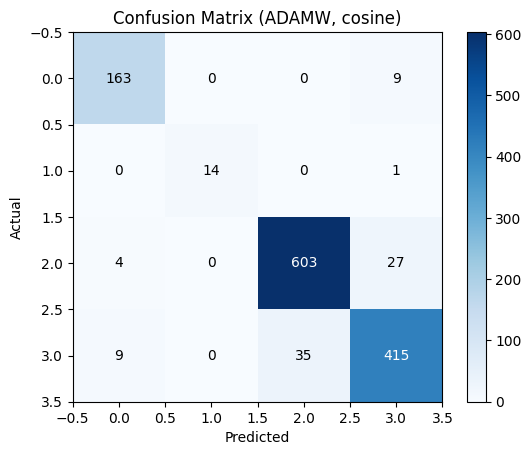

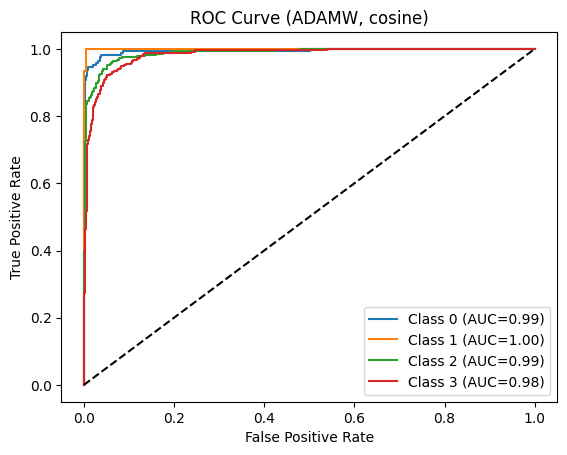

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-11

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.3645 Acc: 0.3218 | Val Loss: 1.3534 Acc: 0.3574
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.3035 Acc: 0.4336 | Val Loss: 1.2508 Acc: 0.5205
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 1.1915 Acc: 0.5002 | Val Loss: 1.1498 Acc: 0.5332
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 1.0189 Acc: 0.5588 | Val Loss: 1.0675 Acc: 0.5303
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.8975 Acc: 0.6047 | Val Loss: 0.9389 Acc: 0.5674
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 0.8452 Acc: 0.6267 | Val Loss: 0.9605 Acc: 0.5449
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 0.7793 Acc: 0.6499 | Val Loss: 0.9701 Acc: 0.5518
Epoch 8/25 | LR: 5.00e-05 | Train Loss: 0.7737 Acc: 0.6438 | Val Loss: 0.9104 Acc: 0.5840
Epoch 9/25 | LR: 5.00e-05 | Train Loss: 0.7405 Acc

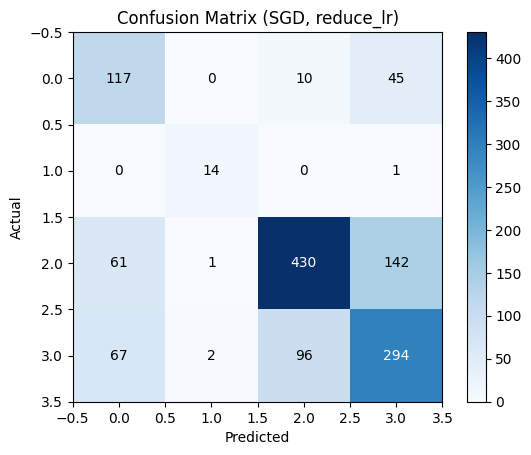

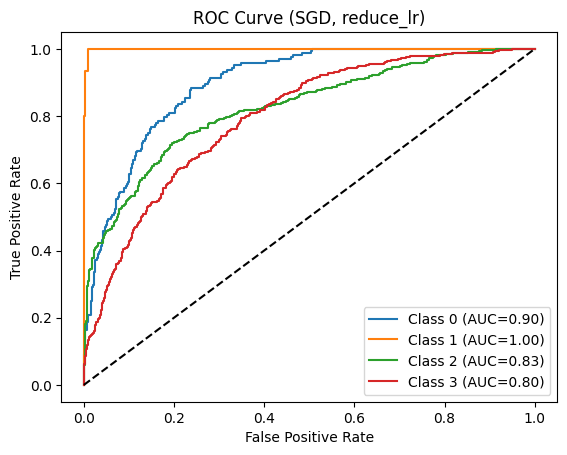

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

S-12

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 5e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.3664 Acc: 0.3252 | Val Loss: 1.3344 Acc: 0.4717
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.2967 Acc: 0.4568 | Val Loss: 1.2568 Acc: 0.5264
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 1.1864 Acc: 0.5220 | Val Loss: 1.1452 Acc: 0.4971
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 1.0350 Acc: 0.5625 | Val Loss: 1.0084 Acc: 0.5508
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.9104 Acc: 0.6003 | Val Loss: 1.0132 Acc: 0.5586
Epoch 6/25 | LR: 4.32e-05 | Train Loss: 0.8542 Acc: 0.6067 | Val Loss: 0.8791 Acc: 0.6016
Epoch 7/25 | LR: 4.09e-05 | Train Loss: 0.7893 Acc: 0.6392 | Val Loss: 0.8950 Acc: 0.6084
Epoch 8/25 | LR: 3.84e-05 | Train Loss: 0.7636 Acc: 0.6487 | Val Loss: 0.9340 Acc: 0.5732
Epoch 9/25 | LR: 3.56e-05 | Train Loss: 0.7544 Acc: 0

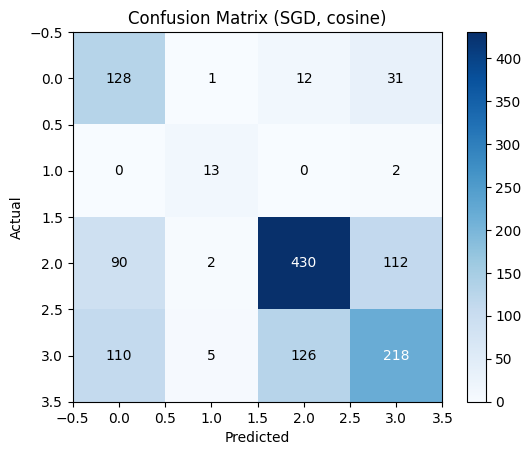

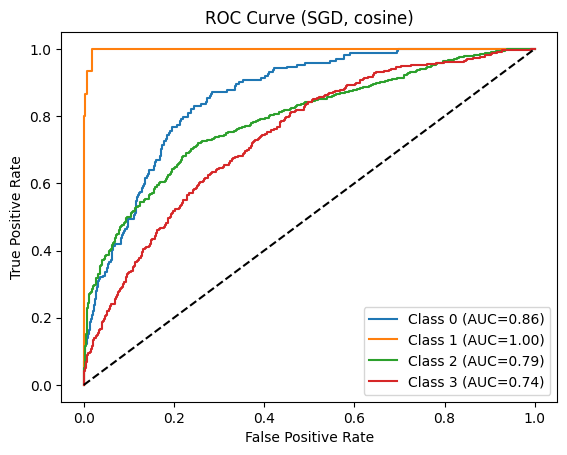

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

FUll Tuning Skenarios

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : full_tuning
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 1e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 0.9245 Acc: 0.5569 | Val Loss: 0.7797 Acc: 0.6182
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 0.6044 Acc: 0.7268 | Val Loss: 0.9376 Acc: 0.5645
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.4773 Acc: 0.7893 | Val Loss: 0.5838 Acc: 0.7334
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.3772 Acc: 0.8391 | Val Loss: 0.5102 Acc: 0.7842
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.2840 Acc: 0.8779 | Val Loss: 0.5324 Acc: 0.7666
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 0.2187 Acc: 0.9087 | Val Loss: 0.3525 Acc: 0.8574
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 0.1642 Acc: 0.9365 | Val Loss: 0.3097 Acc: 0.8770
Epoch 8/25 | LR: 7.68e-06 | Train Loss: 0.1283 Acc: 0.9539 | Val Loss: 0.2781 Acc: 0.9053
Epoch 9/25 | LR: 7.13e-06 | Train Loss: 0.0984 Acc: 0.

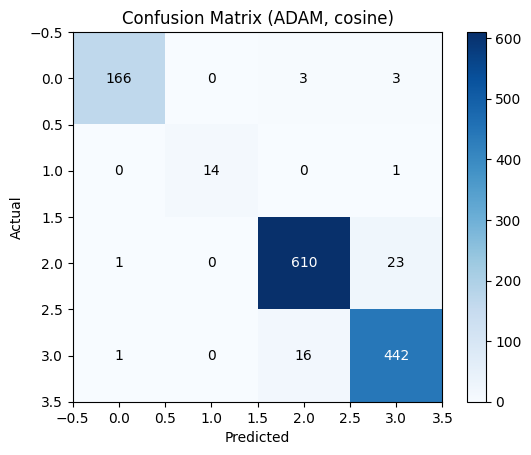

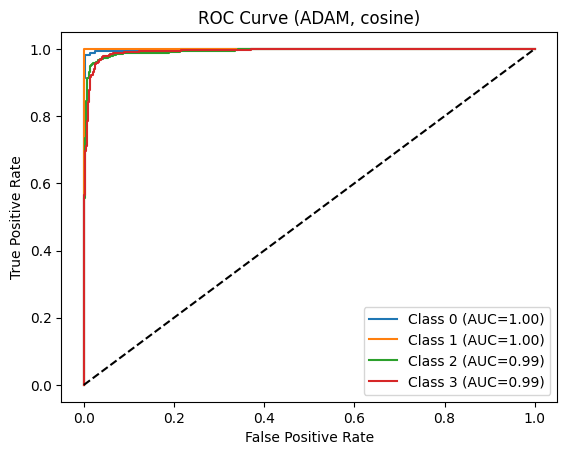

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : full_tuning
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 1e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 0.9104 Acc: 0.5908 | Val Loss: 0.7965 Acc: 0.6035
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 0.5995 Acc: 0.7336 | Val Loss: 0.6745 Acc: 0.6846
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.4955 Acc: 0.7864 | Val Loss: 0.6235 Acc: 0.7295
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.3688 Acc: 0.8457 | Val Loss: 0.5035 Acc: 0.7939
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.2818 Acc: 0.8870 | Val Loss: 0.4051 Acc: 0.8418
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 0.2156 Acc: 0.9131 | Val Loss: 0.3737 Acc: 0.8643
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 0.1599 Acc: 0.9397 | Val Loss: 0.3541 Acc: 0.8760
Epoch 8/25 | LR: 7.68e-06 | Train Loss: 0.1354 Acc: 0.9509 | Val Loss: 0.2981 Acc: 0.8789
Epoch 9/25 | LR: 7.13e-06 | Train Loss: 0.1062 Acc: 0

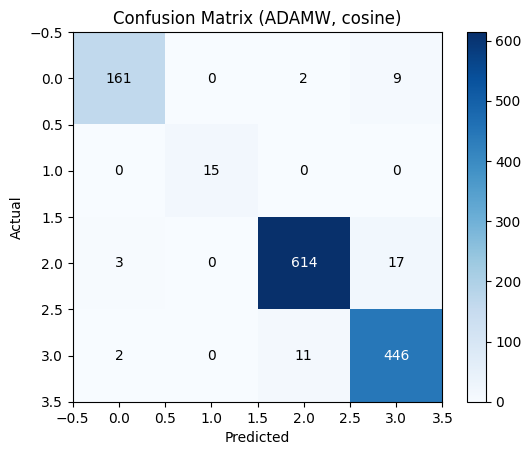

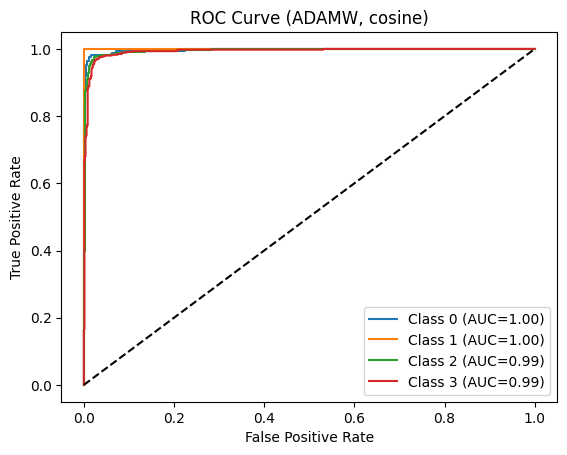

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.3890 Acc: 0.2634 | Val Loss: 1.3644 Acc: 0.4619
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.3765 Acc: 0.2966 | Val Loss: 1.3725 Acc: 0.3701
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 1.3663 Acc: 0.3198 | Val Loss: 1.3797 Acc: 0.3496
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 1.3545 Acc: 0.3479 | Val Loss: 1.3525 Acc: 0.4141
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 1.3395 Acc: 0.3879 | Val Loss: 1.3279 Acc: 0.4736
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 1.3199 Acc: 0.4241 | Val Loss: 1.2964 Acc: 0.5088
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 1.2937 Acc: 0.4561 | Val Loss: 1.2748 Acc: 0.5293
Epoch 8/25 | LR: 1.00e-05 | Train Loss: 1.2588 Acc: 0.4814 | Val Loss: 1.2437 Acc: 0.5215
Epoch 9/25 | LR: 1.00e-05 | Train Loss: 1.1985 Acc: 

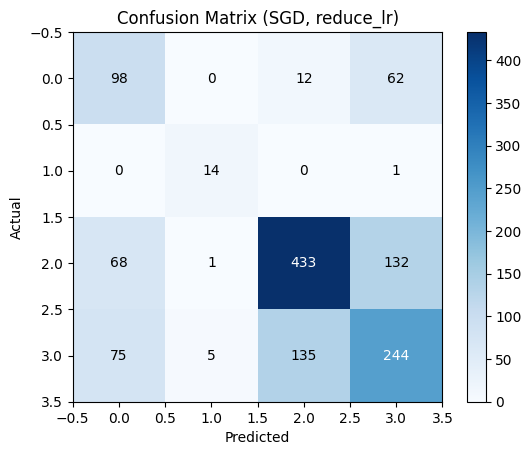

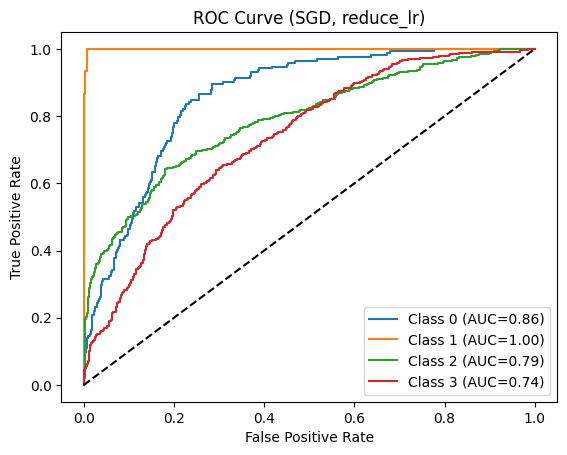

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 1e-05
------------------------------
Loading dataset...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.3895 Acc: 0.2656 | Val Loss: 1.3665 Acc: 0.3301
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.3788 Acc: 0.2849 | Val Loss: 1.3898 Acc: 0.2666
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 1.3630 Acc: 0.3403 | Val Loss: 1.3871 Acc: 0.2568
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 1.3524 Acc: 0.3669 | Val Loss: 1.3808 Acc: 0.2715
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 1.3407 Acc: 0.3792 | Val Loss: 1.3329 Acc: 0.4814
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 1.3195 Acc: 0.4377 | Val Loss: 1.3092 Acc: 0.4893
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 1.2931 Acc: 0.4534 | Val Loss: 1.3065 Acc: 0.4502
Epoch 8/25 | LR: 7.68e-06 | Train Loss: 1.2639 Acc: 0.4875 | Val Loss: 1.2657 Acc: 0.4893
Epoch 9/25 | LR: 7.13e-06 | Train Loss: 1.2319 Acc: 0.5

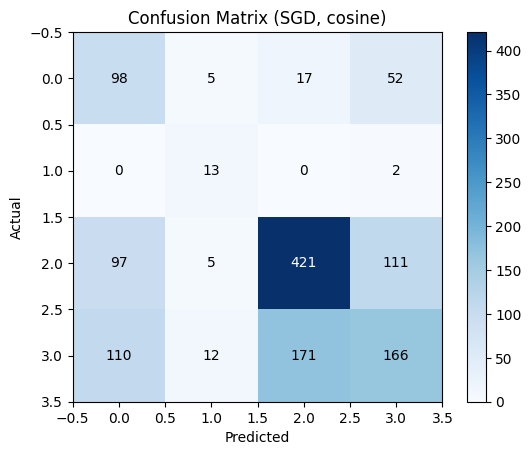

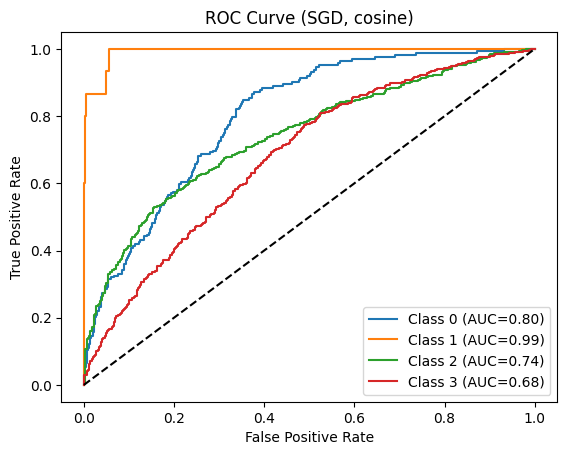

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"    # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 5. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 6. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # 🔥 Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 8. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

# CLASS WEIGHT + AUG (18 Scenarios)

S-01

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------
Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:08<00:00, 71.4MB/s]


-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.3566 Acc: 0.4248 | Val Loss: 1.2367 Acc: 0.4072
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2178 Acc: 0.4895 | Val Loss: 1.0570 Acc: 0.5869
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.0949 Acc: 0.5200 | Val Loss: 0.9940 Acc: 0.4941
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.0118 Acc: 0.5342 | Val Loss: 0.9303 Acc: 0.5332
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.9571 Acc: 0.5452 | Val Loss: 0.8593 Acc: 0.5947
Epoch 6/25 | LR: 1.00e-04 | Train Loss: 0.9091 Acc: 0.5762 | Val Loss: 0.8240 Acc: 0.6025
Epoch 7/25 | LR: 1.00e-04 | Train Loss: 0.8747 Acc: 0.5857 | Val Loss: 0.8071 Acc: 0.5918
Epoch 8/25 | LR: 1.00e-04 | Train Loss: 0.8487 Acc: 0.5850 | Val Loss: 0.8045 Acc: 0.6250
Epoch 9/25 | LR: 1.00e-04 | Train Loss: 0.7773 Acc: 0.6128 | Val Loss: 0.7773 Acc: 0.5898
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.7852 Acc: 0.6216 | Val Loss: 0.7489 Acc: 0.6016
Epoch 11/25 | LR: 1.00e-04 | Tr

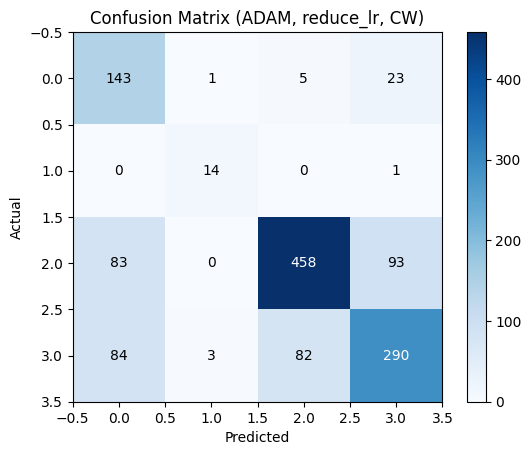

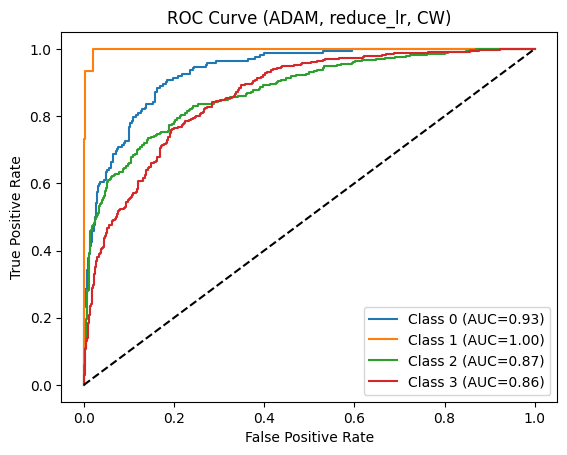

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

S-02

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 0.0001
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.3748 Acc: 0.4204 | Val Loss: 1.1144 Acc: 0.5713
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.2205 Acc: 0.4780 | Val Loss: 1.1253 Acc: 0.4541
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.0827 Acc: 0.5088 | Val Loss: 1.0456 Acc: 0.4209
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 1.0280 Acc: 0.5261 | Val Loss: 0.9148 Acc: 0.5791
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.9334 Acc: 0.5447 | Val Loss: 0.8677 Acc: 0.5898
Epoch 6/25 | LR: 8.64e-05 | Train Loss: 0.9148 Acc: 0.5693 | Val Loss: 0.7952 Acc: 0.6191
Epoch 7/25 | LR: 8.19e-05 | Train Loss: 0.8764 Acc: 0.5767 | Val Loss: 0.7791 Acc: 0.6045
Epoch 8/

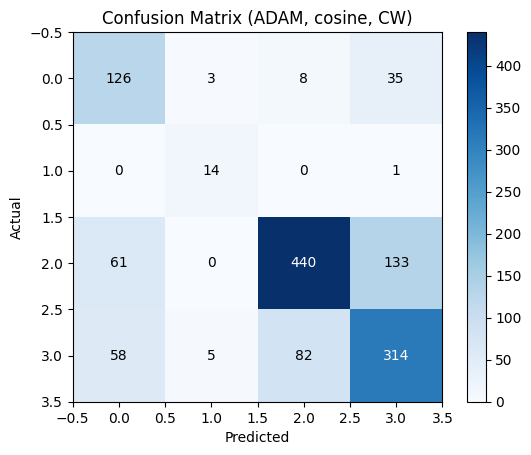

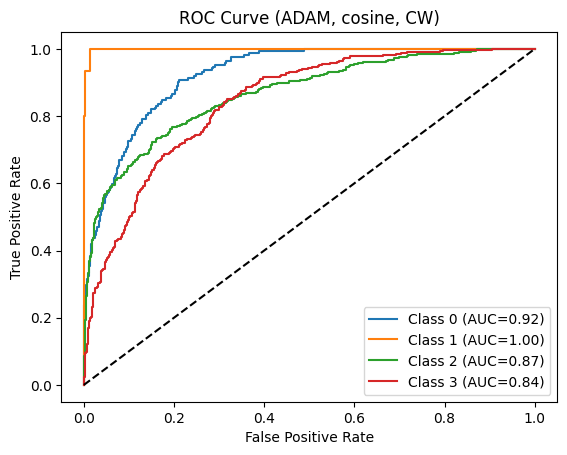

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

S-03

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.4273 Acc: 0.4219 | Val Loss: 1.1573 Acc: 0.5908
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2040 Acc: 0.4849 | Val Loss: 1.1854 Acc: 0.5361
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.1555 Acc: 0.5132 | Val Loss: 0.9603 Acc: 0.5381
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.0228 Acc: 0.5312 | Val Loss: 0.9244 Acc: 0.5225
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.9435 Acc: 0.5437 | Val Loss: 0.8640 Acc: 0.5986
Epoch 6/25 | LR: 1.00e-04 | Train Loss: 0.9150 Acc: 0.5608 | Val Loss: 0.9282 Acc: 0.6270
Epoch 7/25 | LR: 1.00e-04 | Train Loss: 0.8896 Acc: 0.5715 | Val Loss: 0.8408 Acc: 0.6367
Epoc

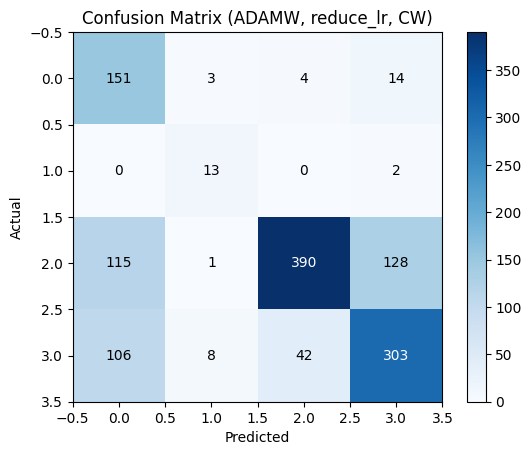

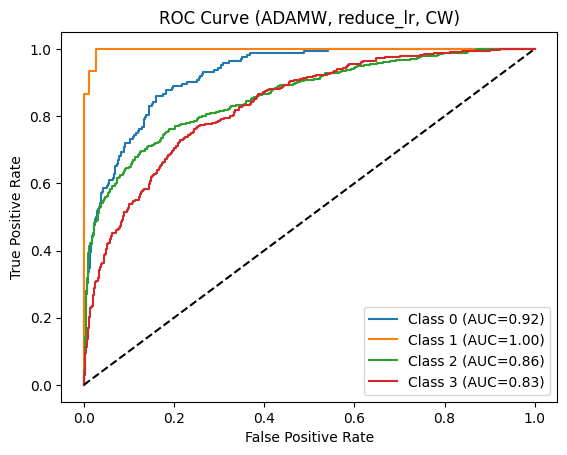

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

S-04

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 0.0001
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.4435 Acc: 0.4180 | Val Loss: 1.1966 Acc: 0.4814
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.1864 Acc: 0.5010 | Val Loss: 1.0892 Acc: 0.5459
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.1152 Acc: 0.5146 | Val Loss: 1.2428 Acc: 0.3369
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 1.0455 Acc: 0.5247 | Val Loss: 0.9429 Acc: 0.5771
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.9393 Acc: 0.5391 | Val Loss: 0.9291 Acc: 0.5586
Epoch 6/25 | LR: 8.64e-05 | Train Loss: 0.8892 Acc: 0.5862 | Val Loss: 0.8517 Acc: 0.5225
Epoch 7/25 | LR: 8.19e-05 | Train Loss: 0.8528 Acc: 0.6011 | Val Loss: 0.8043 Acc: 0.5859
Epoch 8

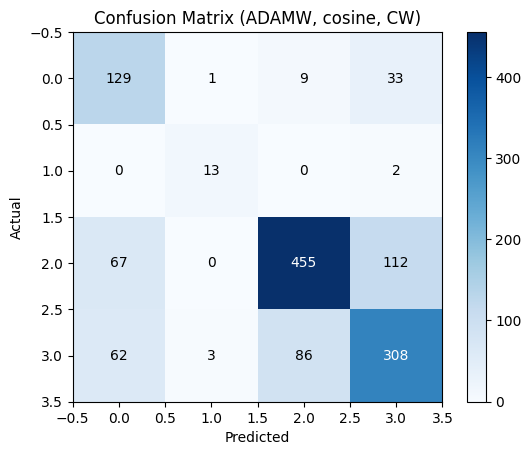

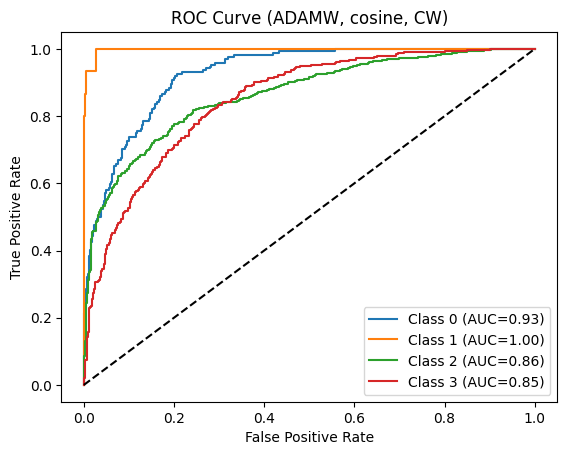

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

S-05

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.3182 Acc: 0.4106 | Val Loss: 1.2693 Acc: 0.5215
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2711 Acc: 0.4685 | Val Loss: 1.2164 Acc: 0.5332
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.2135 Acc: 0.4949 | Val Loss: 1.1955 Acc: 0.5186
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.1788 Acc: 0.5017 | Val Loss: 1.1247 Acc: 0.4951
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 1.1472 Acc: 0.5190 | Val Loss: 1.0776 Acc: 0.5693
Epoch 6/25 | LR: 1.00e-04 | Train Loss: 1.1123 Acc: 0.5283 | Val Loss: 1.0731 Acc: 0.5908
Epoch 7/25 | LR: 1.00e-04 | Train Loss: 1.0808 Acc: 0.5205 | Val Loss: 1.0260 Acc: 0.5439
Epoch 

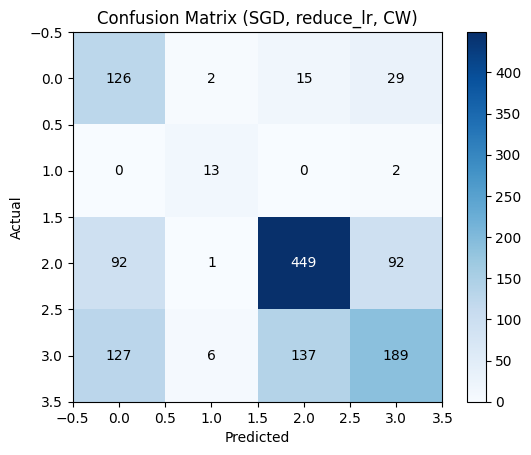

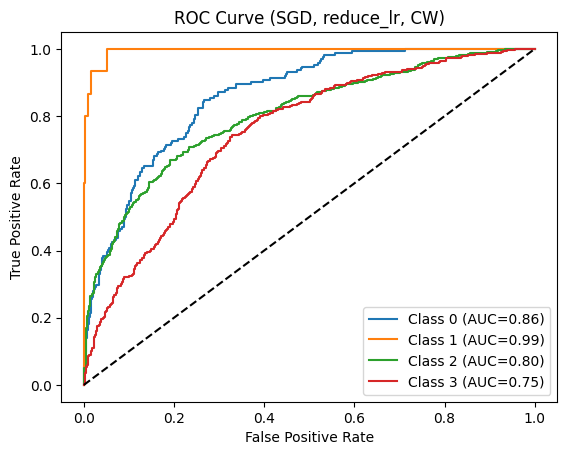

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

S-06

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 0.0001
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.3082 Acc: 0.4075 | Val Loss: 1.2721 Acc: 0.5078
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.2631 Acc: 0.4626 | Val Loss: 1.2636 Acc: 0.5332
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.2312 Acc: 0.4858 | Val Loss: 1.1762 Acc: 0.5615
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 1.1676 Acc: 0.5068 | Val Loss: 1.1275 Acc: 0.5566
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 1.1573 Acc: 0.5105 | Val Loss: 1.0918 Acc: 0.5459
Epoch 6/25 | LR: 8.64e-05 | Train Loss: 1.1208 Acc: 0.5115 | Val Loss: 1.0634 Acc: 0.5732
Epoch 7/25 | LR: 8.19e-05 | Train Loss: 1.1013 Acc: 0.5225 | Val Loss: 1.0506 Acc: 0.5898
Epoch 8/2

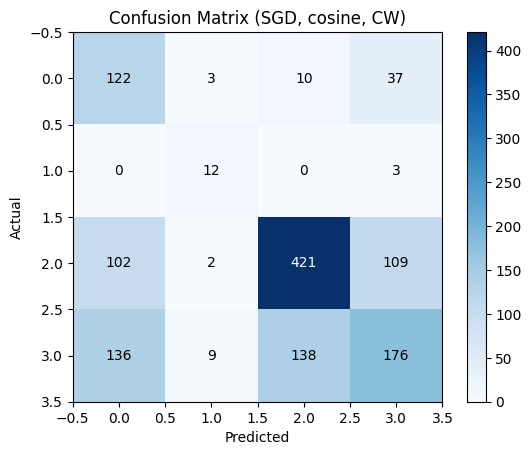

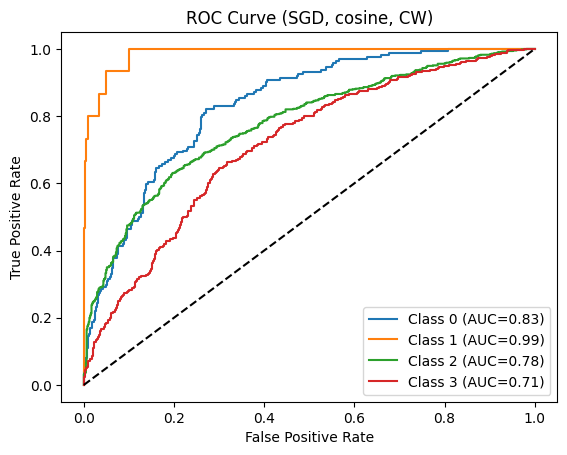

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------
Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 124MB/s]


-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.2370 Acc: 0.4507 | Val Loss: 1.1331 Acc: 0.4668
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.0434 Acc: 0.5481 | Val Loss: 1.0497 Acc: 0.4736
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.9102 Acc: 0.5759 | Val Loss: 0.9987 Acc: 0.4951
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.7475 Acc: 0.6179 | Val Loss: 0.9350 Acc: 0.6465
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.6273 Acc: 0.6743 | Val Loss: 0.6249 Acc: 0.6875
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 0.5759 Acc: 0.7173 | Val Loss: 0.6003 Acc: 0.6855
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 0.5118 Acc: 0.7600 | Val Loss: 0.5554 Acc: 0.7373
Epoch 8/25 | LR: 5.00e-05 | Train Loss: 0.4511 Acc: 0.7993 | Val Loss: 0.6146 Acc: 0.7461
Epoch 9/25 | LR: 5.00e-05 | Train Loss: 0.3558 Acc: 0.8250 | Val Loss: 0.4781 Acc: 0.7842
Epoch 10/25 | LR: 5.00e-05 | Train Loss: 0.2920 Acc: 0.8599 | Val Loss: 0.4386 Acc: 0.7754
Epoch 11/25 | LR: 5.00e-05 | Tr

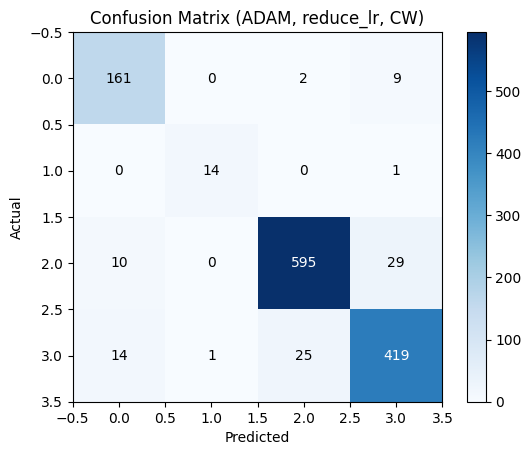

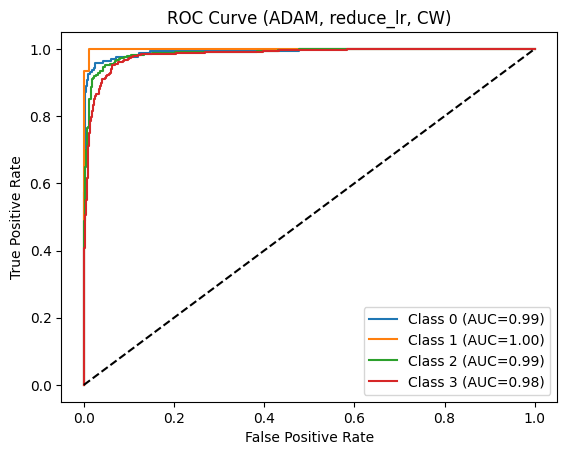

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 5e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.2449 Acc: 0.4836 | Val Loss: 1.0516 Acc: 0.5312
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.0398 Acc: 0.5266 | Val Loss: 0.9924 Acc: 0.5771
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.9028 Acc: 0.5793 | Val Loss: 0.7960 Acc: 0.5527
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.7653 Acc: 0.6274 | Val Loss: 0.7124 Acc: 0.6631
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.6425 Acc: 0.6829 | Val Loss: 0.6261 Acc: 0.6846
Epoch 6/25 | LR: 4.32e-05 | Train Loss: 0.5875 Acc: 0.7195 | Val Loss: 0.5785 Acc: 0.6621
Epoch 7/25 | LR: 4.09e-05 | Train Loss: 0.4633 Acc: 0.7725 | Val Loss: 0.4778 Acc: 0.7578
Epoch 

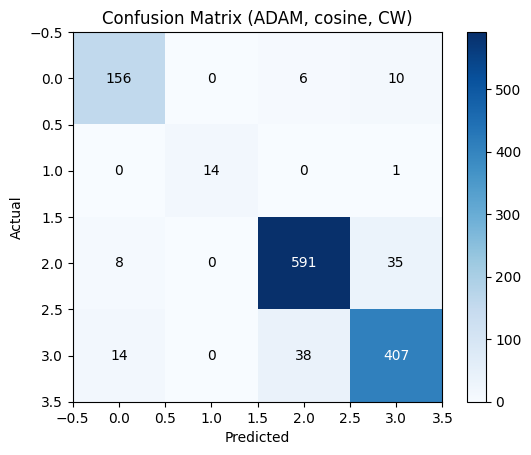

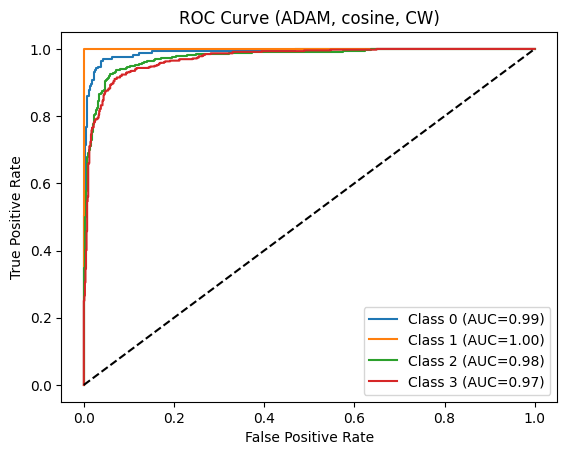

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.2179 Acc: 0.4805 | Val Loss: 1.2479 Acc: 0.5879
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.0752 Acc: 0.5278 | Val Loss: 0.9681 Acc: 0.5352
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.9256 Acc: 0.5735 | Val Loss: 0.9847 Acc: 0.4463
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.8031 Acc: 0.6196 | Val Loss: 0.7939 Acc: 0.5781
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.6522 Acc: 0.6602 | Val Loss: 0.6314 Acc: 0.6934
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 0.5524 Acc: 0.7273 | Val Loss: 0.5337 Acc: 0.7158
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 0.5133 Acc: 0.7524 | Val Loss: 0.5457 Acc: 0.7197
Ep

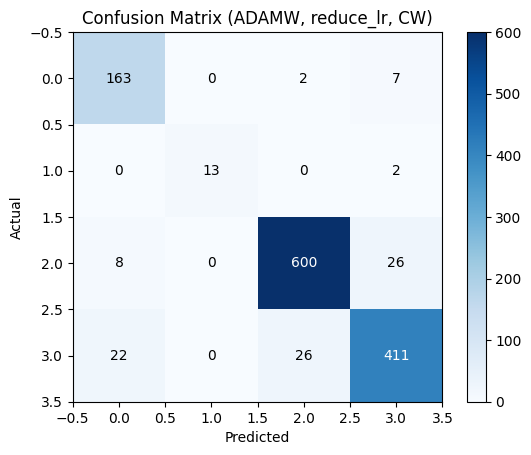

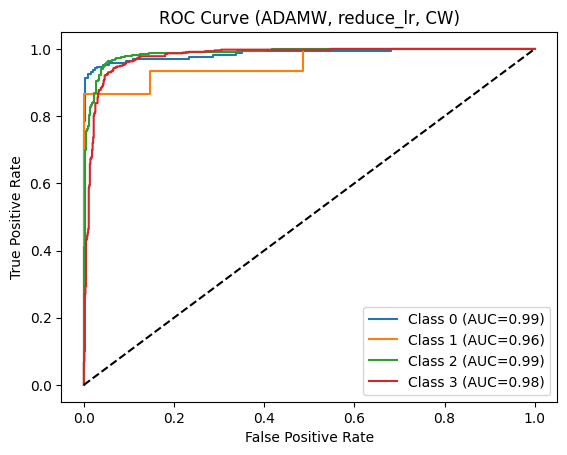

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 5e-05
------------------------------
Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 88.0MB/s]


-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.2359 Acc: 0.4727 | Val Loss: 1.1532 Acc: 0.3457
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.0234 Acc: 0.5454 | Val Loss: 0.9842 Acc: 0.5049
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.8838 Acc: 0.6033 | Val Loss: 0.8143 Acc: 0.6279
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.7640 Acc: 0.6211 | Val Loss: 0.6684 Acc: 0.7021
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.6509 Acc: 0.6807 | Val Loss: 0.7064 Acc: 0.7080
Epoch 6/25 | LR: 4.32e-05 | Train Loss: 0.5178 Acc: 0.7380 | Val Loss: 0.4959 Acc: 0.7480
Epoch 7/25 | LR: 4.09e-05 | Train Loss: 0.4795 Acc: 0.7732 | Val Loss: 0.5400 Acc: 0.7510
Epoch 8/25 | LR: 3.84e-05 | Train Loss: 0.3661 Acc: 0.8210 | Val Loss: 0.5693 Acc: 0.8047
Epoch 9/25 | LR: 3.56e-05 | Train Loss: 0.2998 Acc: 0.8550 | Val Loss: 0.4391 Acc: 0.8135
Epoch 10/25 | LR: 3.27e-05 | Train Loss: 0.2753 Acc: 0.8738 | Val Loss: 0.5400 Acc: 0.8057
Epoch 11/25 | LR: 2.97e-05 | Tr

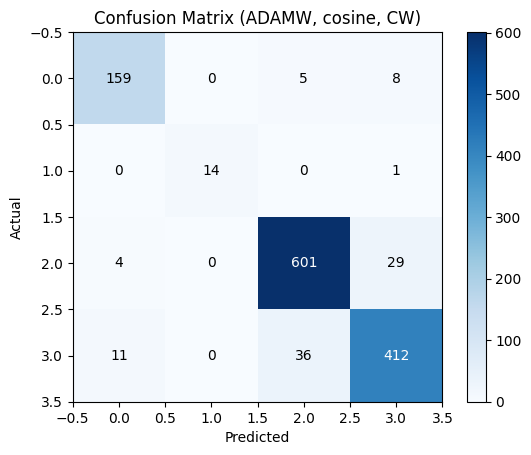

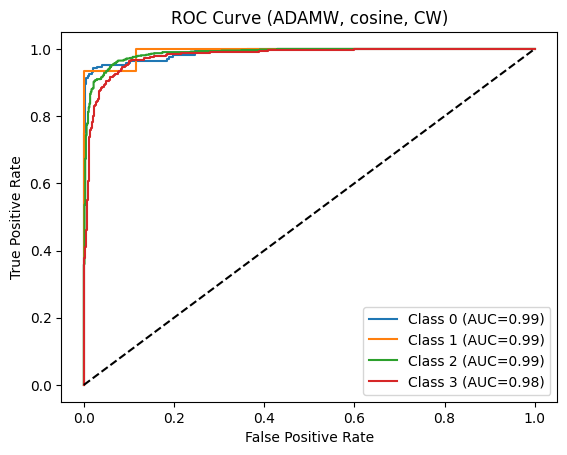

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.3266 Acc: 0.4204 | Val Loss: 1.2853 Acc: 0.5342
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.2796 Acc: 0.4653 | Val Loss: 1.2635 Acc: 0.5088
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 1.2514 Acc: 0.4883 | Val Loss: 1.2065 Acc: 0.5342
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 1.2097 Acc: 0.4946 | Val Loss: 1.1531 Acc: 0.5742
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 1.1613 Acc: 0.5137 | Val Loss: 1.1077 Acc: 0.5498
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 1.1270 Acc: 0.5212 | Val Loss: 1.0545 Acc: 0.5908
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 1.0767 Acc: 0.5325 | Val Loss: 1.0292 Acc: 0.5068
Epoc

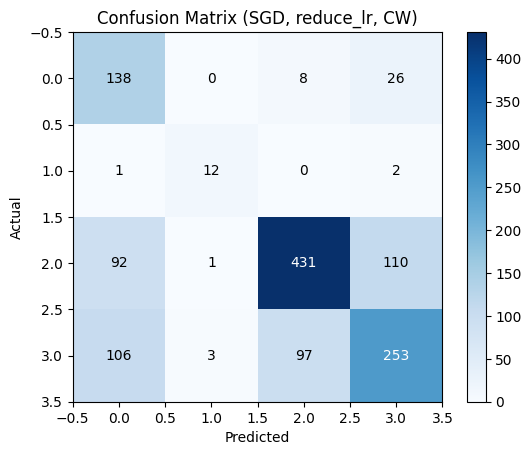

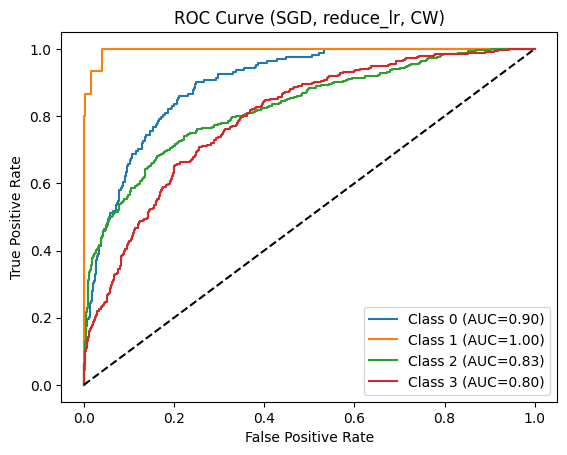

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 5e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.3273 Acc: 0.3948 | Val Loss: 1.2965 Acc: 0.5488
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.2815 Acc: 0.4587 | Val Loss: 1.2677 Acc: 0.4561
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 1.2571 Acc: 0.4773 | Val Loss: 1.2255 Acc: 0.5273
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 1.2201 Acc: 0.4968 | Val Loss: 1.1664 Acc: 0.5625
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 1.1579 Acc: 0.5107 | Val Loss: 1.1089 Acc: 0.5840
Epoch 6/25 | LR: 4.32e-05 | Train Loss: 1.1180 Acc: 0.5232 | Val Loss: 1.0594 Acc: 0.5400
Epoch 7/25 | LR: 4.09e-05 | Train Loss: 1.0632 Acc: 0.5420 | Val Loss: 1.0235 Acc: 0.6045
Epoch 8

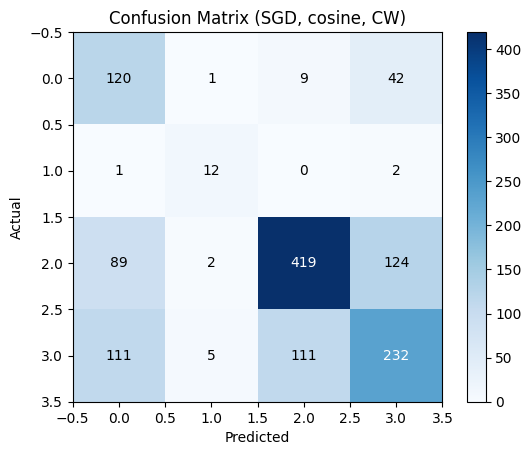

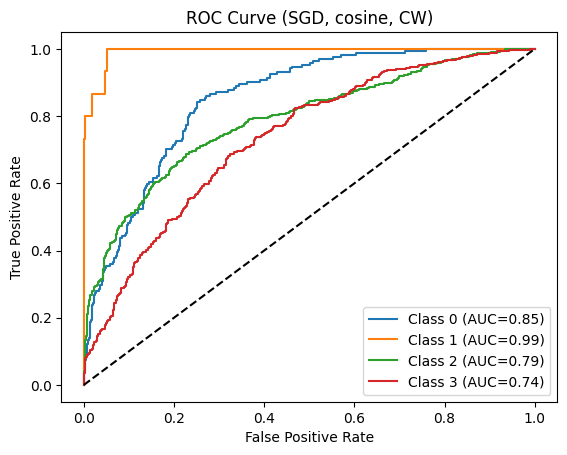

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.2033 Acc: 0.4858 | Val Loss: 1.0369 Acc: 0.5596
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.0193 Acc: 0.5593 | Val Loss: 0.9794 Acc: 0.5635
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.8187 Acc: 0.6174 | Val Loss: 0.7100 Acc: 0.6445
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.6619 Acc: 0.6792 | Val Loss: 0.6449 Acc: 0.7109
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.4895 Acc: 0.7561 | Val Loss: 0.4715 Acc: 0.7217
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 0.3519 Acc: 0.8242 | Val Loss: 0.3887 Acc: 0.8467
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 0.2674 Acc: 0.8630 | Val Loss: 0.3107 Acc: 0.8457
Epoch

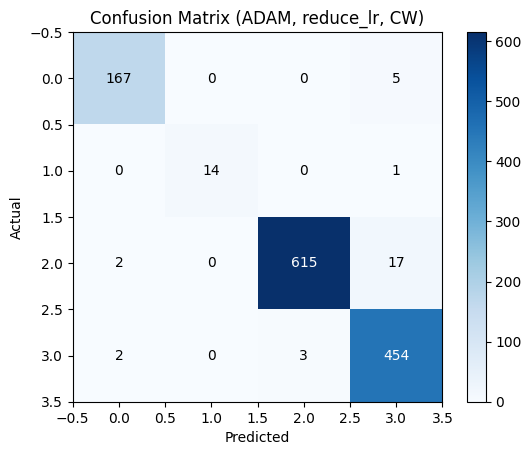

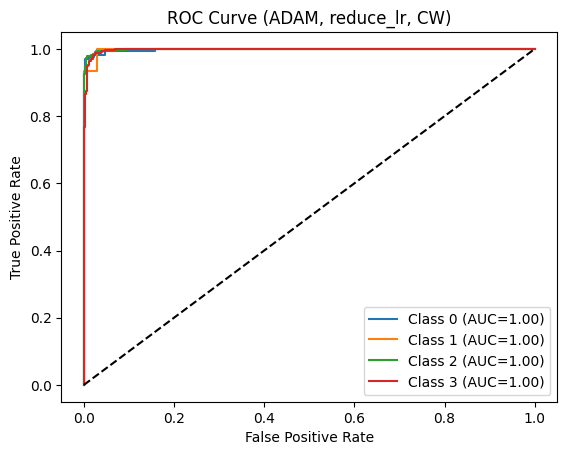

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 1e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.2484 Acc: 0.4624 | Val Loss: 1.0961 Acc: 0.5684
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.0377 Acc: 0.5498 | Val Loss: 0.9848 Acc: 0.5938
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.8697 Acc: 0.6023 | Val Loss: 0.8176 Acc: 0.5342
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.7121 Acc: 0.6492 | Val Loss: 0.7071 Acc: 0.6963
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.5199 Acc: 0.7424 | Val Loss: 0.5334 Acc: 0.7324
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 0.3793 Acc: 0.8118 | Val Loss: 0.3733 Acc: 0.8135
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 0.3104 Acc: 0.8621 | Val Loss: 0.3424 Acc: 0.8262
Epoch 8/

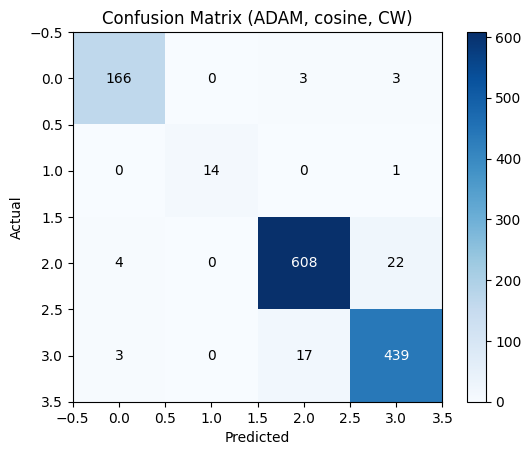

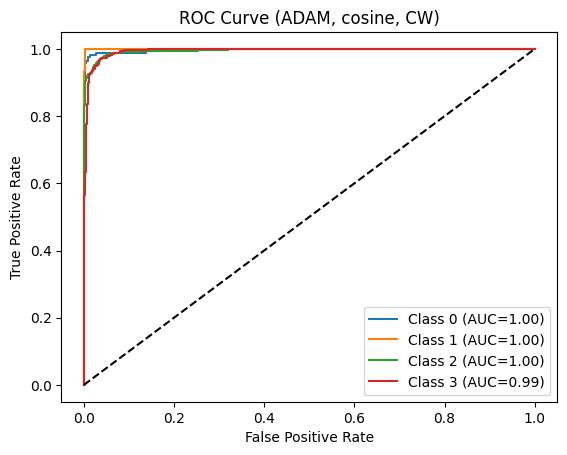

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------
Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 170MB/s]


-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.2389 Acc: 0.4746 | Val Loss: 1.1950 Acc: 0.3779
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.0133 Acc: 0.5515 | Val Loss: 0.8898 Acc: 0.6094
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.7934 Acc: 0.6377 | Val Loss: 0.6901 Acc: 0.7041
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.6286 Acc: 0.7000 | Val Loss: 0.5455 Acc: 0.7266
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.4579 Acc: 0.7703 | Val Loss: 0.4746 Acc: 0.7178
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 0.3651 Acc: 0.8206 | Val Loss: 0.3806 Acc: 0.8164
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 0.2543 Acc: 0.8752 | Val Loss: 0.3859 Acc: 0.8467
Epoch 8/25 | LR: 1.00e-05 | Train Loss: 0.2095 Acc: 0.9019 | Val Loss: 0.3885 Acc: 0.8555
Epoch 9/25 | LR: 1.00e-05 | Train Loss: 0.1450 Acc: 0.9321 | Val Loss: 0.2562 Acc: 0.9102
Epoch 10/25 | LR: 1.00e-05 | Train Loss: 0.1205 Acc: 0.9436 | Val Loss: 0.2669 Acc: 0.9189
Epoch 11/25 | LR: 1.00e-05 | Tr

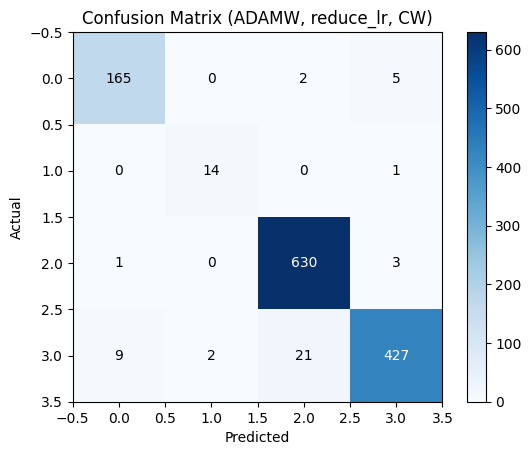

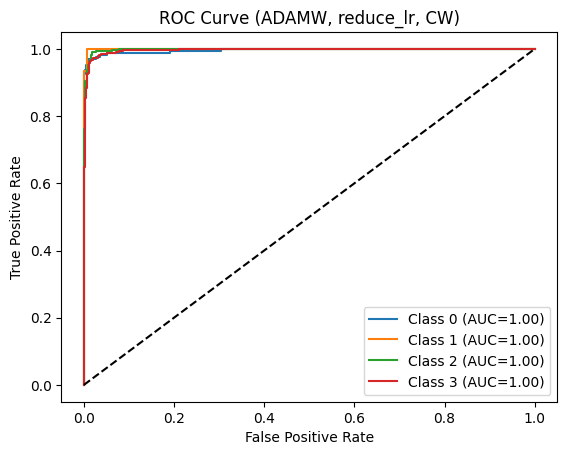

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 1e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.2103 Acc: 0.4902 | Val Loss: 1.0625 Acc: 0.5977
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.0049 Acc: 0.5708 | Val Loss: 0.8996 Acc: 0.5879
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.8229 Acc: 0.6187 | Val Loss: 0.6752 Acc: 0.6641
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.6238 Acc: 0.6926 | Val Loss: 0.5732 Acc: 0.7217
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.4622 Acc: 0.7722 | Val Loss: 0.4294 Acc: 0.8096
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 0.3373 Acc: 0.8284 | Val Loss: 0.3384 Acc: 0.8438
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 0.2687 Acc: 0.8706 | Val Loss: 0.2933 Acc: 0.8623
Epoch 8

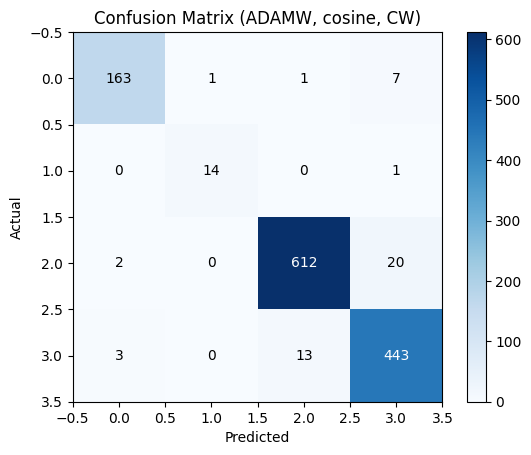

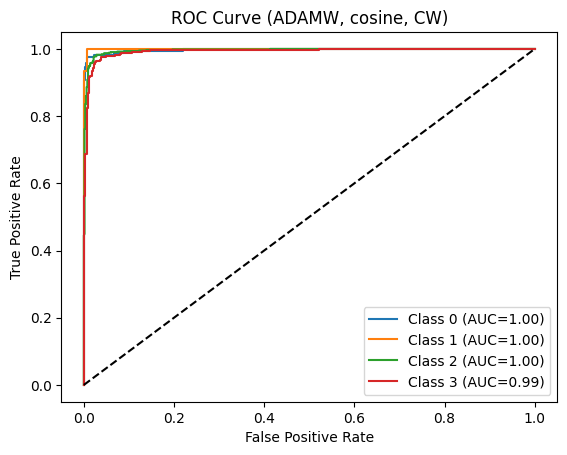

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.3595 Acc: 0.3740 | Val Loss: 1.3250 Acc: 0.5166
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.3228 Acc: 0.4189 | Val Loss: 1.3074 Acc: 0.5215
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 1.3172 Acc: 0.4263 | Val Loss: 1.2990 Acc: 0.5303
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 1.3004 Acc: 0.4297 | Val Loss: 1.2908 Acc: 0.5420
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 1.2905 Acc: 0.4539 | Val Loss: 1.2823 Acc: 0.5557
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 1.2837 Acc: 0.4531 | Val Loss: 1.2716 Acc: 0.5508
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 1.2751 Acc: 0.4568 | Val Loss: 1.2607 Acc: 0.5449
Epoch 

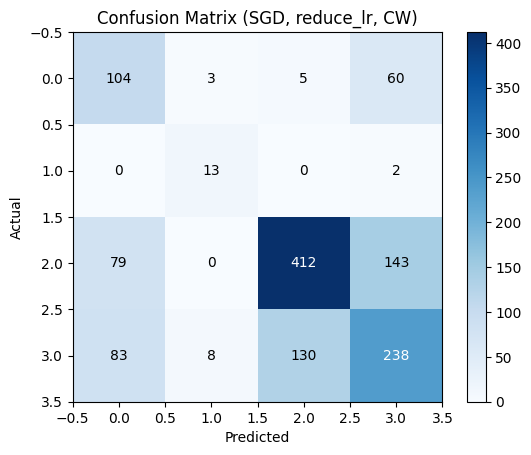

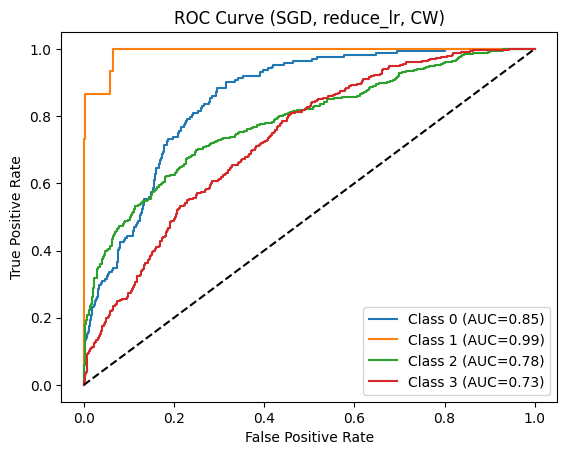

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 1e-05
------------------------------
Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
-> Menerapkan Class Weight pada Loss Function...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.3701 Acc: 0.2371 | Val Loss: 1.3332 Acc: 0.2959
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.3208 Acc: 0.3440 | Val Loss: 1.3085 Acc: 0.4414
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 1.3095 Acc: 0.4016 | Val Loss: 1.2993 Acc: 0.4648
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 1.3045 Acc: 0.3940 | Val Loss: 1.2903 Acc: 0.5117
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 1.3010 Acc: 0.4214 | Val Loss: 1.2817 Acc: 0.5361
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 1.2817 Acc: 0.4561 | Val Loss: 1.2730 Acc: 0.5557
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 1.2836 Acc: 0.4480 | Val Loss: 1.2632 Acc: 0.5557
Epoch 8/2

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


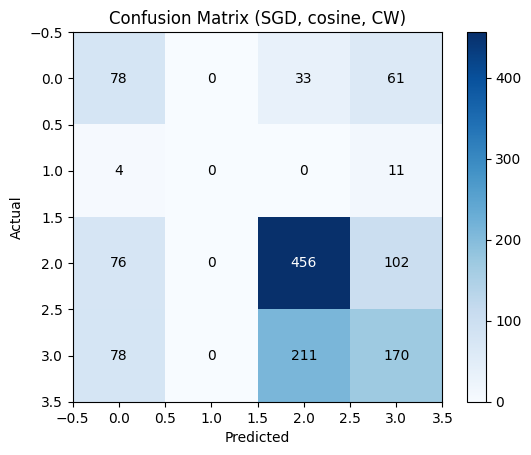

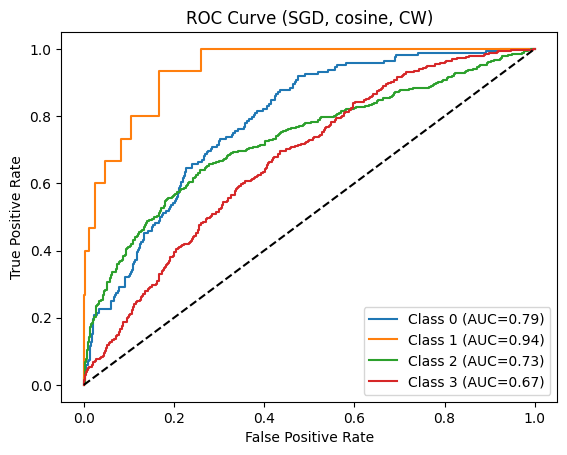

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
USE_AUGMENTATION = True
# 🔥 UBAH STRATEGI KE CLASS WEIGHT
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 6. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 7. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 8. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
# 🔥 Logic Imbalance Loss
if IMBALANCE_STRATEGY == "class_weight":
    print("-> Menerapkan Class Weight pada Loss Function...")
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 9. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 10. EVALUASI AKHIR PADA TEST SET
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# Nama file disimpan dengan rapi sesuai konfigurasi skenario (termasuk penanda class_weight)
model_filename = f"best_vgg19_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}_cw.pth"
torch.save(model.state_dict(), model_filename)

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE} | Class Weight")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE}, CW)")
plt.legend(loc="lower right")
plt.show()

# Weighted Random Sampler (File in Gdrive)

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : freeze_all
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 76.0MB/s]



Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.0739 Acc: 0.5046 | Val Loss: 0.9626 Acc: 0.5186
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 0.8093 Acc: 0.6201 | Val Loss: 0.9097 Acc: 0.5625
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 0.7282 Acc: 0.6558 | Val Loss: 0.8955 Acc: 0.5469
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 0.6718 Acc: 0.6902 | Val Loss: 0.7914 Acc: 0.6270
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.6618 Acc: 0.6943 | Val Loss: 0.8242 Acc: 0.6191
Epoch 6/25 | LR: 1.00e-04 | Train Loss: 0.6403 Acc: 0.7061 | Val Loss: 0.8114 Acc: 0.6191
Epoch 7/25 | LR: 1.00e-04 | Train Loss: 0.6128 Acc: 0.7258 | Val Loss: 0.7133 Acc: 0.6826
Epoch 8/25 | LR: 1.00e-04 | Train Loss: 0.5904 Acc: 0.7395 | Val Loss: 0.7884 Acc: 0.6514
Epoch 9/25 | LR: 1.00e-04 | Train Loss: 0.5765 Acc: 0.7463 | Val Loss: 0.8098 Acc: 0.6416
Epoch 10/25 | LR: 1.00e-04 | Train Loss: 0.5672 Acc: 0.7576 | Val Loss: 0.6625 Acc: 0.6953
Epoch 11/25 | LR: 1.00e-04 | Train Loss: 0.5599 Acc: 0.7578 | Val Loss: 0.7601 A

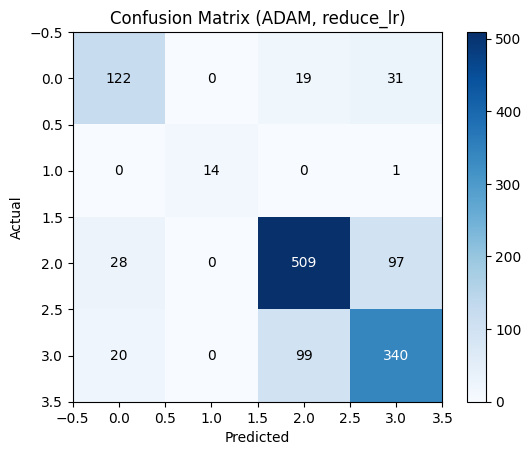

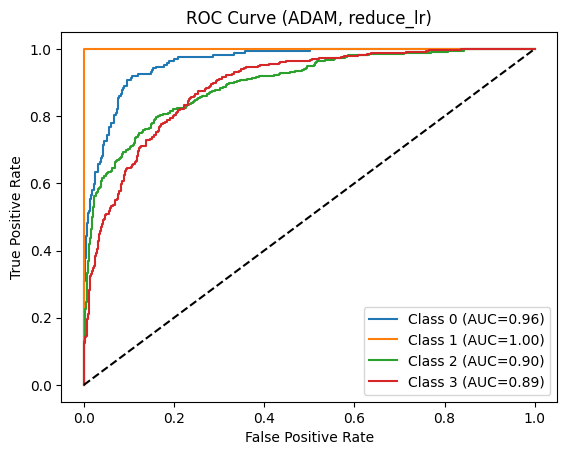

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : freeze_all
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 0.0001
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.0880 Acc: 0.4907 | Val Loss: 1.0220 Acc: 0.4883
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 0.8006 Acc: 0.6216 | Val Loss: 1.0037 Acc: 0.5000
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 0.7399 Acc: 0.6484 | Val Loss: 0.9338 Acc: 0.5439
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 0.6703 Acc: 0.6941 | Val Loss: 0.8226 Acc: 0.6191
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.6604 Acc: 0.6995 | Val Loss: 0.8070 Acc: 0

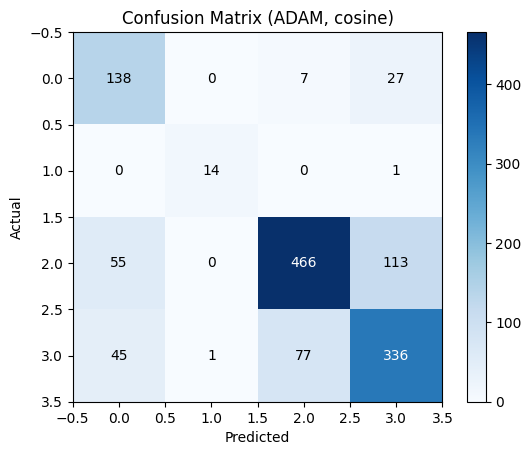

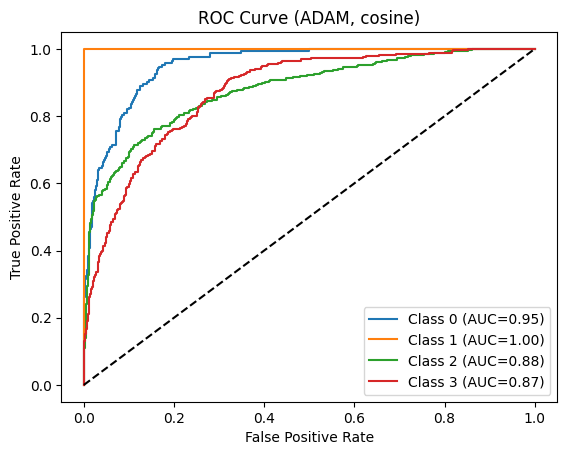

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.0694 Acc: 0.5059 | Val Loss: 1.0367 Acc: 0.5283
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 0.8048 Acc: 0.6272 | Val Loss: 0.8197 Acc: 0.5732
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 0.7291 Acc: 0.6614 | Val Loss: 0.8916 Acc: 0.5625
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 0.6811 Acc: 0.6797 | Val Loss: 0.8634 Acc: 0.5605
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.6649 Acc: 0.6931 | Val Loss: 0.9092 Ac

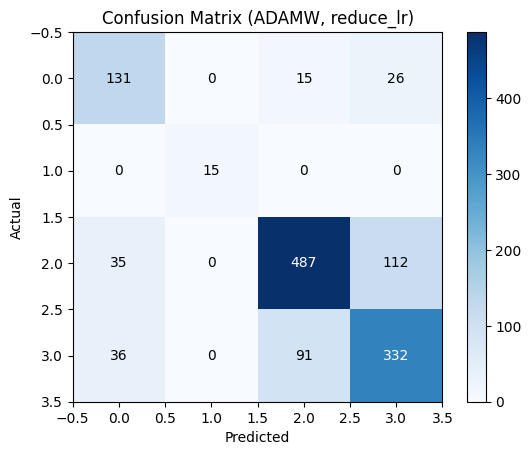

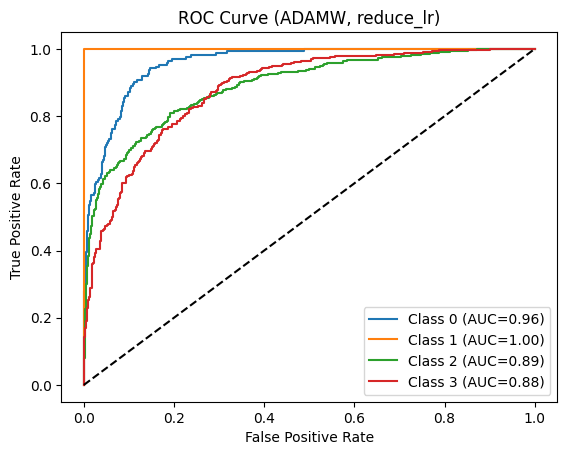

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 0.0001
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.0486 Acc: 0.5120 | Val Loss: 0.9678 Acc: 0.5625
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 0.8014 Acc: 0.6179 | Val Loss: 0.9636 Acc: 0.5605
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 0.7337 Acc: 0.6455 | Val Loss: 0.8316 Acc: 0.5811
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 0.6971 Acc: 0.6743 | Val Loss: 0.8190 Acc: 0.6240
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.6512 Acc: 0.6904 | Val Loss: 0.8098 Acc: 

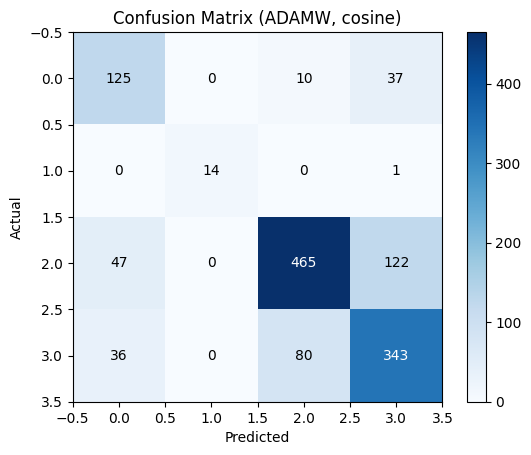

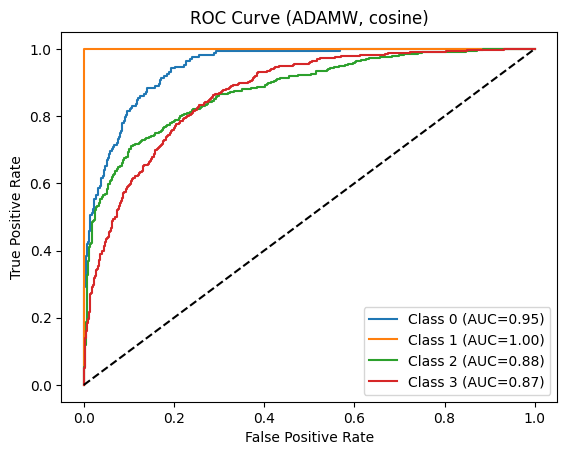

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.3513 Acc: 0.3638 | Val Loss: 1.3217 Acc: 0.4316
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2413 Acc: 0.4915 | Val Loss: 1.2087 Acc: 0.4746
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.1171 Acc: 0.5527 | Val Loss: 1.1118 Acc: 0.5068
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.0065 Acc: 0.5759 | Val Loss: 1.0138 Acc: 0.5283
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.9356 Acc: 0.5928 | Val Loss: 1.0432 Acc:

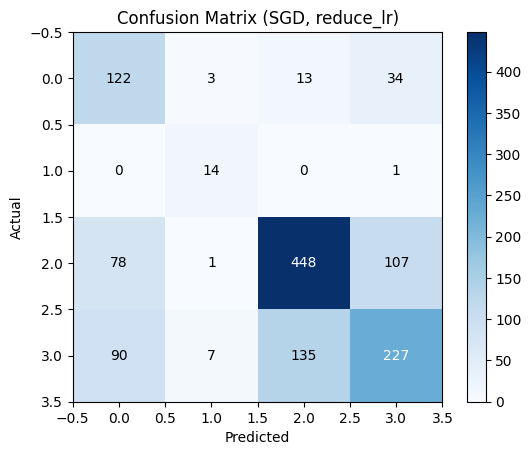

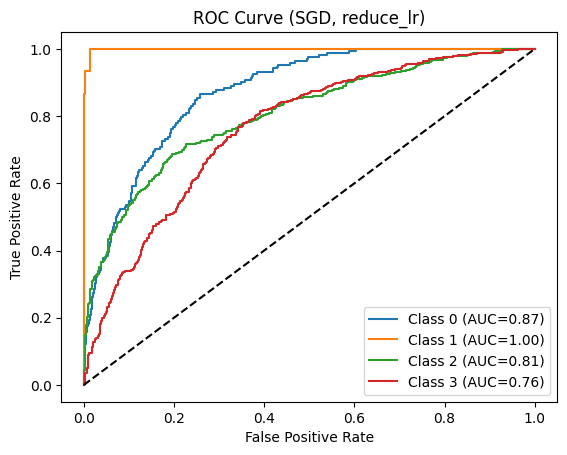

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 0.0001
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.3495 Acc: 0.3513 | Val Loss: 1.2472 Acc: 0.5166
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.2556 Acc: 0.4729 | Val Loss: 1.1894 Acc: 0.5029
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.1399 Acc: 0.5256 | Val Loss: 1.1719 Acc: 0.5039
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 1.0230 Acc: 0.5679 | Val Loss: 1.0209 Acc: 0.5566
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.9359 Acc: 0.6025 | Val Loss: 1.0225 Acc: 0.

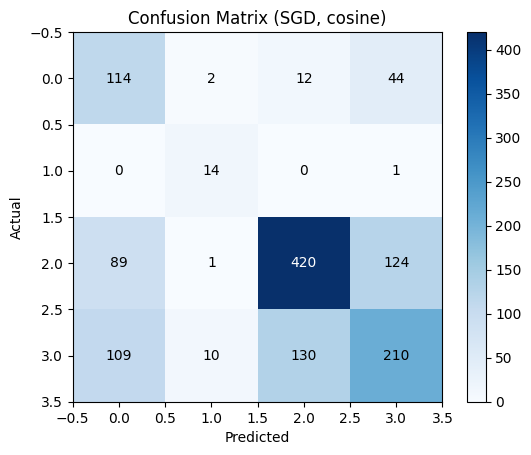

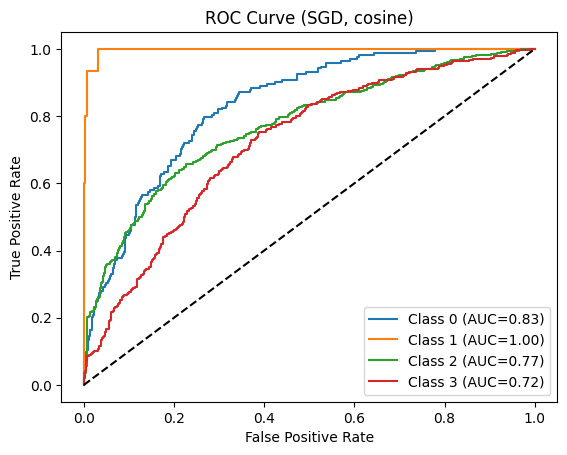

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : unfreeze_last
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 0.8670 Acc: 0.5806 | Val Loss: 0.9030 Acc: 0.5430
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 0.6034 Acc: 0.7302 | Val Loss: 0.6773 Acc: 0.6807
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.4823 Acc: 0.7896 | Val Loss: 0.8505 Acc: 0.6357
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.3940 Acc: 0.8359 | Val Loss: 0.5590 Acc: 0.7559
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.3408 Acc: 0.8557 | Val Loss: 0.7545 A

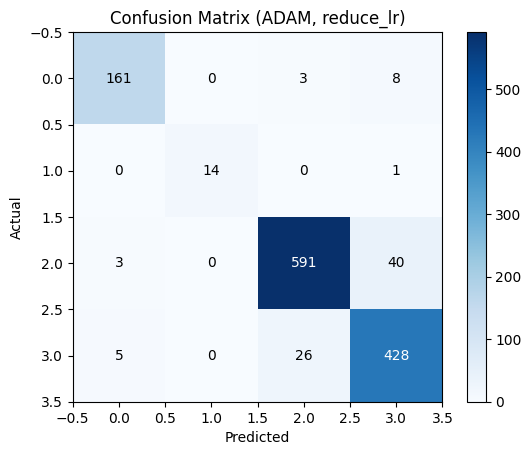

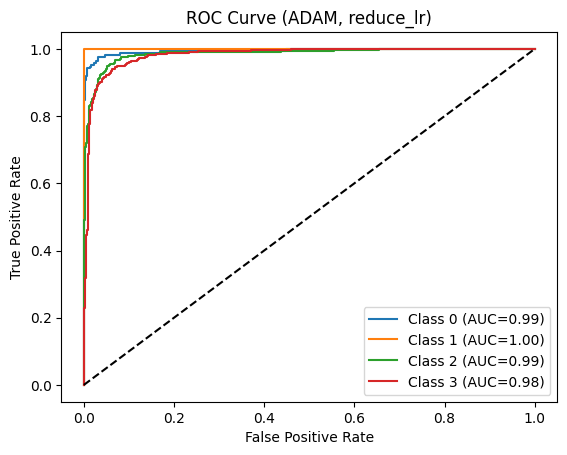

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : unfreeze_last
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 5e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 0.8682 Acc: 0.5884 | Val Loss: 0.8020 Acc: 0.5908
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 0.6160 Acc: 0.7214 | Val Loss: 0.7059 Acc: 0.6895
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.4965 Acc: 0.7764 | Val Loss: 0.6213 Acc: 0.7080
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.4065 Acc: 0.8308 | Val Loss: 0.5682 Acc: 0.7471
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.3482 Acc: 0.8616 | Val Loss: 0.5220 Acc:

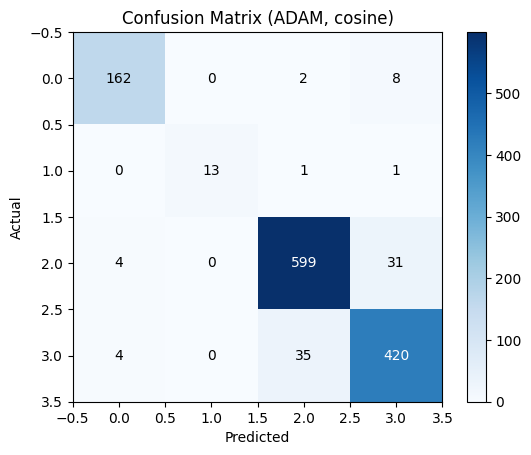

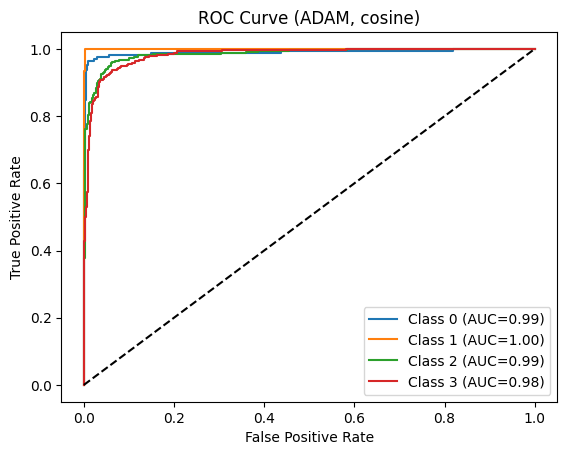

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 0.8632 Acc: 0.5886 | Val Loss: 0.7520 Acc: 0.6318
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 0.6010 Acc: 0.7336 | Val Loss: 0.7301 Acc: 0.6729
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.4824 Acc: 0.7864 | Val Loss: 0.7497 Acc: 0.6943
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.4145 Acc: 0.8184 | Val Loss: 0.6103 Acc: 0.7461
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.3246 Acc: 0.8630 | Val Loss: 0.8028 

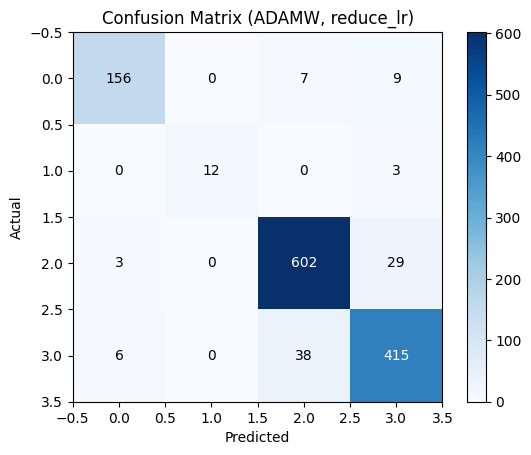

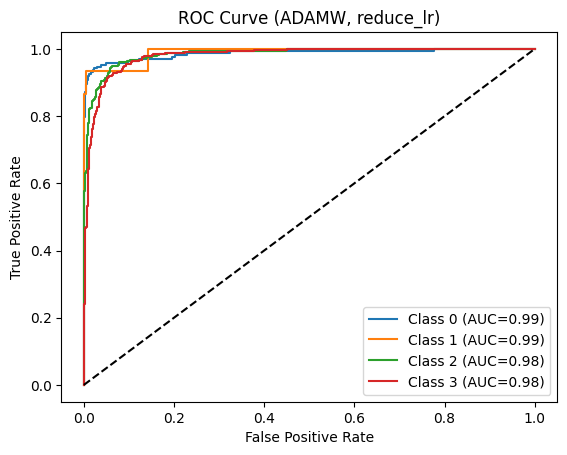

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 5e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 0.8529 Acc: 0.5901 | Val Loss: 1.2537 Acc: 0.3682
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 0.6005 Acc: 0.7261 | Val Loss: 0.9146 Acc: 0.5518
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.4925 Acc: 0.7903 | Val Loss: 0.6511 Acc: 0.6953
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.4134 Acc: 0.8262 | Val Loss: 0.6093 Acc: 0.7441
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.3247 Acc: 0.8706 | Val Loss: 0.5358 Acc

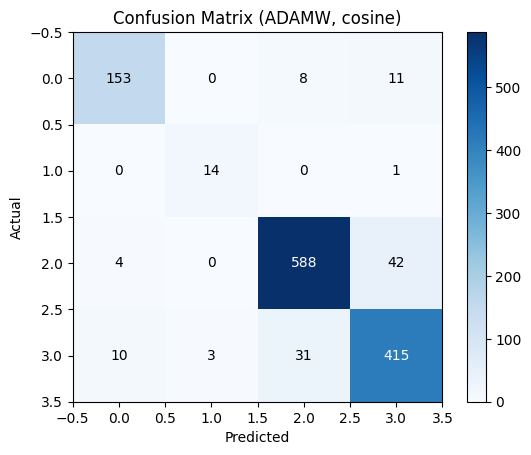

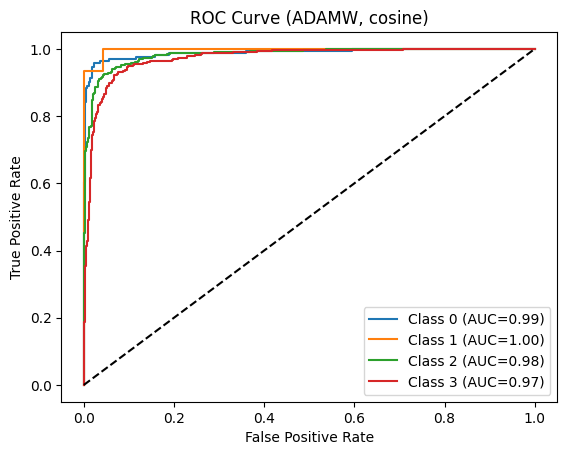

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.3644 Acc: 0.3274 | Val Loss: 1.3251 Acc: 0.4658
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.2965 Acc: 0.4419 | Val Loss: 1.3075 Acc: 0.4248
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 1.1764 Acc: 0.5183 | Val Loss: 1.1435 Acc: 0.4814
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 1.0209 Acc: 0.5674 | Val Loss: 0.9984 Acc: 0.5078
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.9081 Acc: 0.5984 | Val Loss: 0.9609 Ac

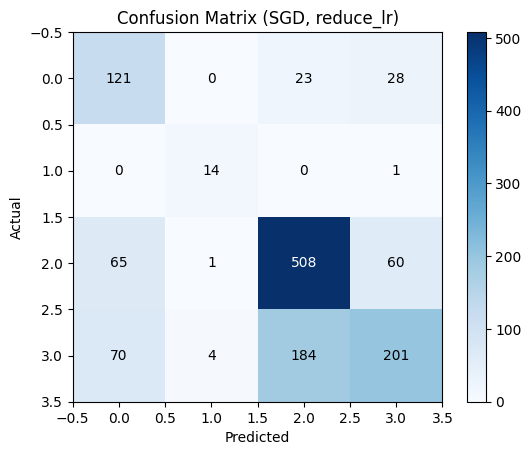

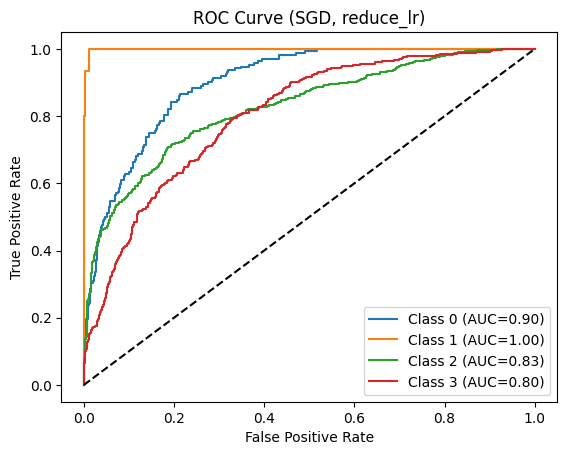

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 5e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.3687 Acc: 0.3123 | Val Loss: 1.3802 Acc: 0.2764
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.2964 Acc: 0.4336 | Val Loss: 1.2528 Acc: 0.5068
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 1.1947 Acc: 0.4995 | Val Loss: 1.1387 Acc: 0.5068
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 1.0523 Acc: 0.5427 | Val Loss: 1.1040 Acc: 0.4727
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.9110 Acc: 0.6030 | Val Loss: 0.9401 Acc: 

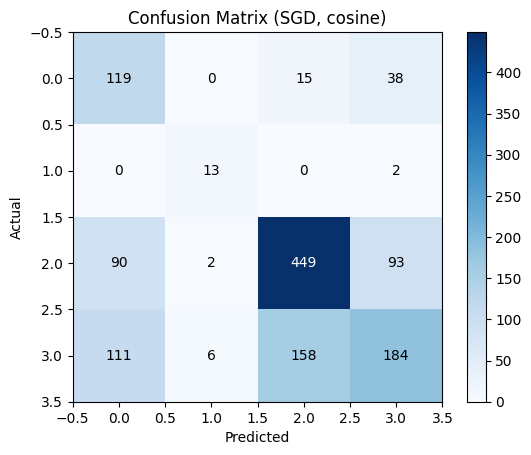

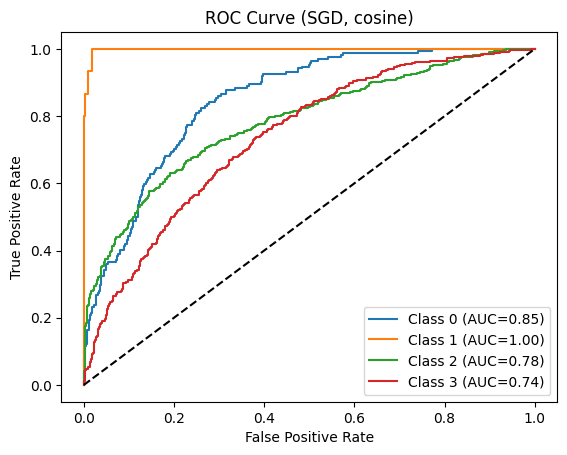

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : full_tuning
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 0.9212 Acc: 0.5649 | Val Loss: 0.8640 Acc: 0.5820
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 0.6221 Acc: 0.7112 | Val Loss: 0.7986 Acc: 0.6094
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.5000 Acc: 0.7852 | Val Loss: 0.7241 Acc: 0.6641
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.3882 Acc: 0.8384 | Val Loss: 0.4931 Acc: 0.7803
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.2810 Acc: 0.8809 | Val Loss: 0.5138 Acc

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : full_tuning
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 1e-05
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 166MB/s]



Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 0.9302 Acc: 0.5679 | Val Loss: 0.8975 Acc: 0.5928
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 0.6251 Acc: 0.7170 | Val Loss: 0.6750 Acc: 0.6895
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.5011 Acc: 0.7852 | Val Loss: 0.5705 Acc: 0.7578
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.3807 Acc: 0.8386 | Val Loss: 0.5256 Acc: 0.7881
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.2694 Acc: 0.8950 | Val Loss: 0.3988 Acc: 0.8291
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 0.2190 Acc: 0.9133 | Val Loss: 0.3413 Acc: 0.8701
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 0.1820 Acc: 0.9280 | Val Loss: 0.3327 Acc: 0.8721
Epoch 8/25 | LR: 7.68e-06 | Train Loss: 0.1317 Acc: 0.9504 | Val Loss: 0.3791 Acc: 0.8584
Epoch 9/25 | LR: 7.13e-06 | Train Loss: 0.1231 Acc: 0.9529 | Val Loss: 0.3103 Acc: 0.8779
Epoch 10/25 | LR: 6.55e-06 | Train Loss: 0.0777 Acc: 0.9717 | Val Loss: 0.2606 Acc: 0.9072
Epoch 11/25 | LR: 5.94e-06 | Train Loss: 0.0635 Acc: 0.9753 | Val Loss: 0.2587 A

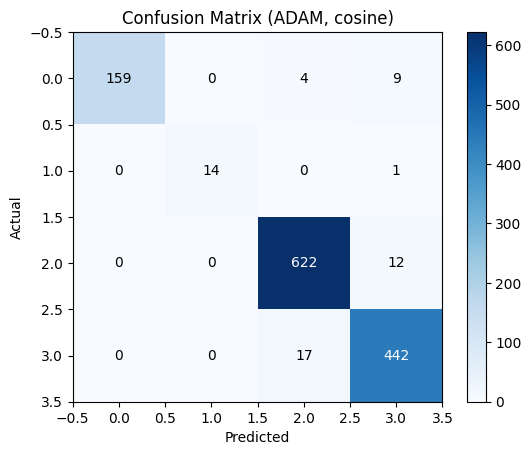

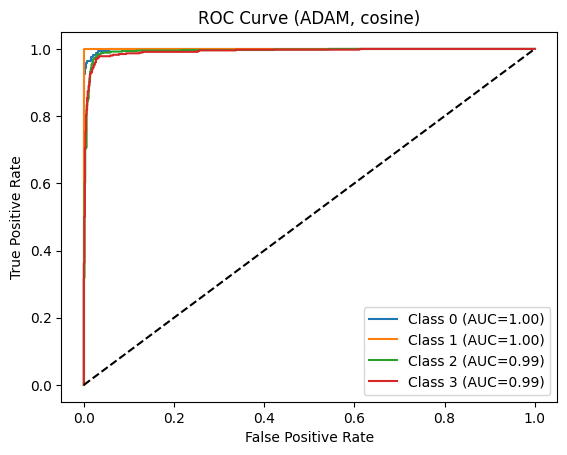

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : full_tuning
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 0.9435 Acc: 0.5586 | Val Loss: 0.8298 Acc: 0.6152
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 0.6324 Acc: 0.7102 | Val Loss: 0.7990 Acc: 0.6582
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.4953 Acc: 0.7944 | Val Loss: 0.6358 Acc: 0.7148
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.3572 Acc: 0.8484 | Val Loss: 0.5432 Acc: 0.7686
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.2907 Acc: 0.8857 | Val Loss: 0.4600 Ac

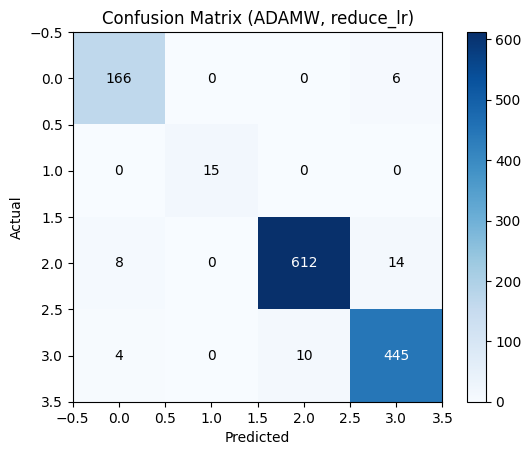

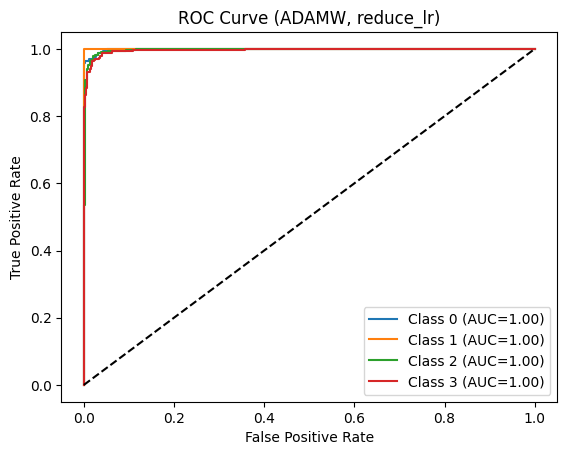

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : full_tuning
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 1e-05
------------------------------

Loading dataset...
-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 0.9417 Acc: 0.5710 | Val Loss: 0.8919 Acc: 0.5752
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 0.6289 Acc: 0.7144 | Val Loss: 0.6539 Acc: 0.7061
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.4891 Acc: 0.7839 | Val Loss: 0.6505 Acc: 0.7197
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.3640 Acc: 0.8518 | Val Loss: 0.5505 Acc: 0.7656
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.2913 Acc: 0.8804 | Val Loss: 0.3942 Acc: 

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:07<00:00, 76.0MB/s]



Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.3913 Acc: 0.2673 | Val Loss: 1.3879 Acc: 0.2197
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.3812 Acc: 0.2822 | Val Loss: 1.3916 Acc: 0.2295
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 1.3699 Acc: 0.3237 | Val Loss: 1.3718 Acc: 0.3945
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 1.3571 Acc: 0.3655 | Val Loss: 1.3503 Acc: 0.4746
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 1.3405 Acc: 0.3965 | Val Loss: 1.3432 Acc: 0.4746
Epoch 6/25 | LR: 1.00e-05 | Train Loss: 1.3236 Acc: 0.4199 | Val Loss: 1.3370 Acc: 0.4453
Epoch 7/25 | LR: 1.00e-05 | Train Loss: 1.3017 Acc: 0.4485 | Val Loss: 1.3105 Acc: 0.4629
Epoch 8/25 | LR: 1.00e-05 | Train Loss: 1.2667 Acc: 0.4805 | Val Loss: 1.2611 Acc: 0.5059
Epoch 9/25 | LR: 1.00e-05 | Train Loss: 1.2219 Acc: 0.5110 | Val Loss: 1.2242 Acc: 0.4805
Epoch 10/25 | LR: 1.00e-05 | Train Loss: 1.1525 Acc: 0.5244 | Val Loss: 1.1431 Acc: 0.5303
Epoch 11/25 | LR: 1.00e-05 | Train Loss: 1.0598 Acc: 0.5571 | Val Loss: 1.0756 A

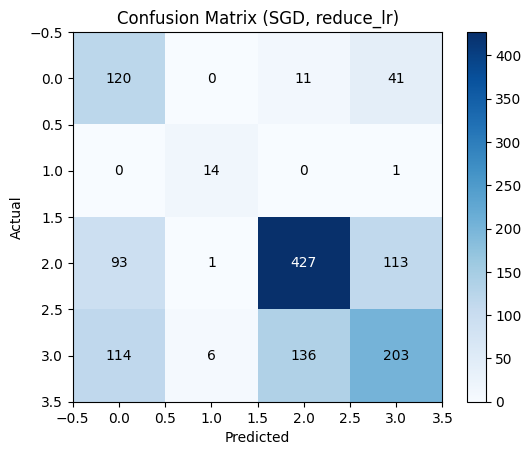

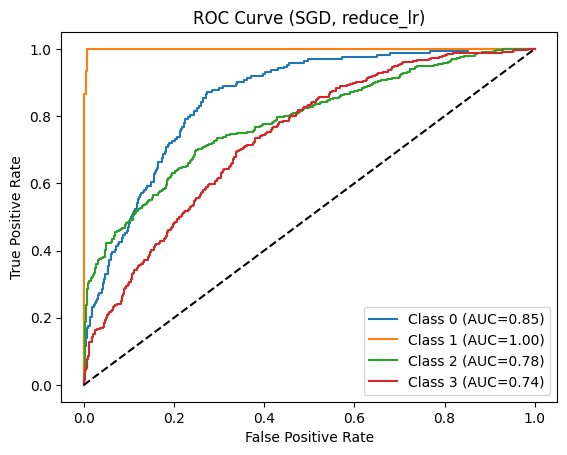

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : SAMPLER
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 1e-05
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> Menerapkan Weighted Random Sampler pada DataLoader...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 103MB/s]



Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.3886 Acc: 0.2617 | Val Loss: 1.4038 Acc: 0.0879
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.3756 Acc: 0.2920 | Val Loss: 1.3863 Acc: 0.1846
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 1.3642 Acc: 0.3235 | Val Loss: 1.3617 Acc: 0.4502
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 1.3506 Acc: 0.3679 | Val Loss: 1.3550 Acc: 0.4375
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 1.3389 Acc: 0.4080 | Val Loss: 1.3199 Acc: 0.5010
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 1.3199 Acc: 0.4324 | Val Loss: 1.3043 Acc: 0.5000
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 1.2971 Acc: 0.4585 | Val Loss: 1.2817 Acc: 0.5039
Epoch 8/25 | LR: 7.68e-06 | Train Loss: 1.2690 Acc: 0.4753 | Val Loss: 1.2311 Acc: 0.5420
Epoch 9/25 | LR: 7.13e-06 | Train Loss: 1.2387 Acc: 0.4934 | Val Loss: 1.2134 Acc: 0.5332
Epoch 10/25 | LR: 6.55e-06 | Train Loss: 1.1855 Acc: 0.5288 | Val Loss: 1.1745 Acc: 0.5127
Epoch 11/25 | LR: 5.94e-06 | Train Loss: 1.1310 Acc: 0.5430 | Val Loss: 1.1271 A

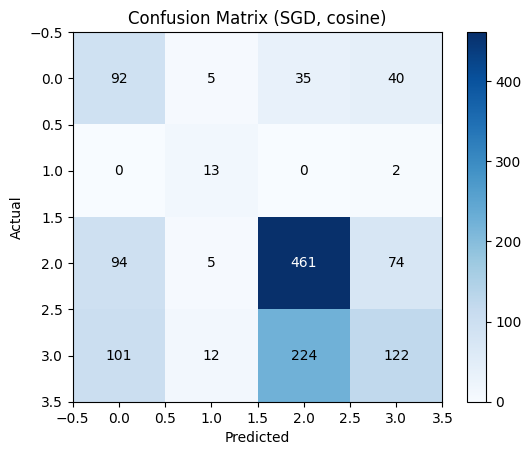

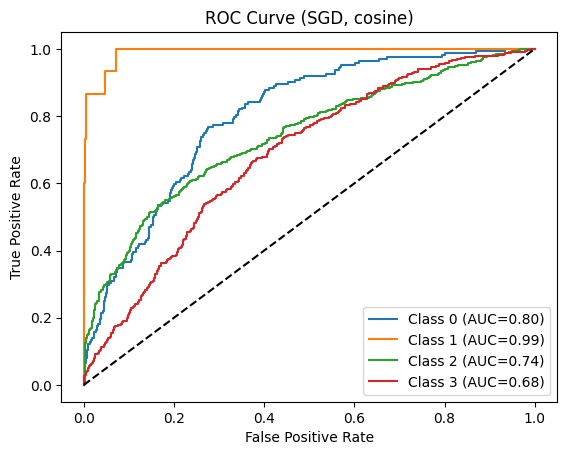

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "sampler"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

# Class Weight (Saved Model)

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.3480 Acc: 0.4358 | Val Loss: 1.1593 Acc: 0.5732
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2097 Acc: 0.4919 | Val Loss: 1.1201 Acc: 0.5186
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.1268 Acc: 0.5007 | Val Loss: 1.0086 Acc: 0.5459
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.0123 Acc: 0.5347 | Val Loss: 0.9590 Acc: 0.6201
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.9225 Acc: 0.5598 | Val Loss:

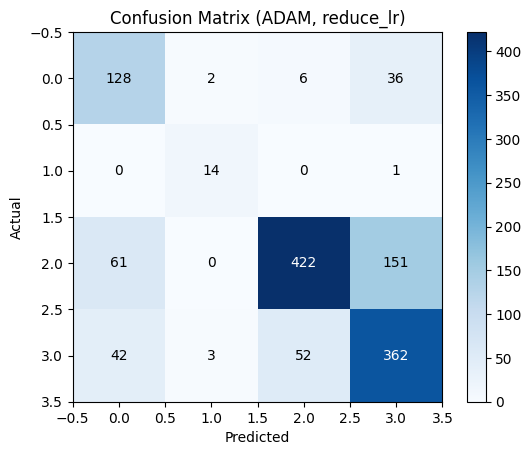

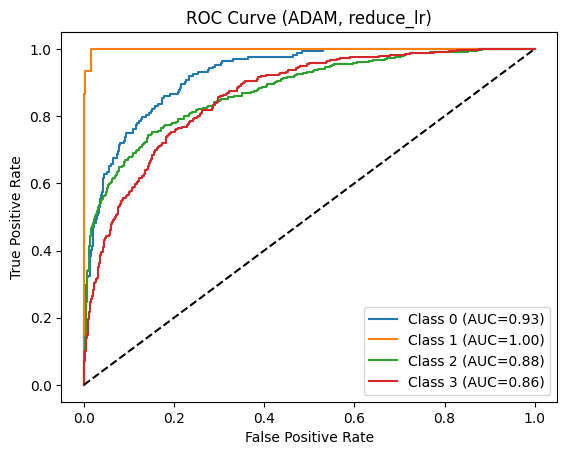

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 0.0001
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.3780 Acc: 0.4297 | Val Loss: 1.1503 Acc: 0.5723
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.1918 Acc: 0.4849 | Val Loss: 1.0697 Acc: 0.4590
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.1302 Acc: 0.5022 | Val Loss: 1.0071 Acc: 0.5645
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 1.0082 Acc: 0.5432 | Val Loss: 0.9386 Acc: 0.5322
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.9905 Acc: 0.5549 | Val Loss: 0.

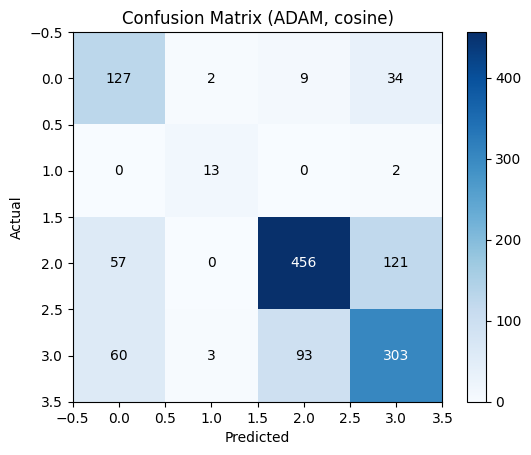

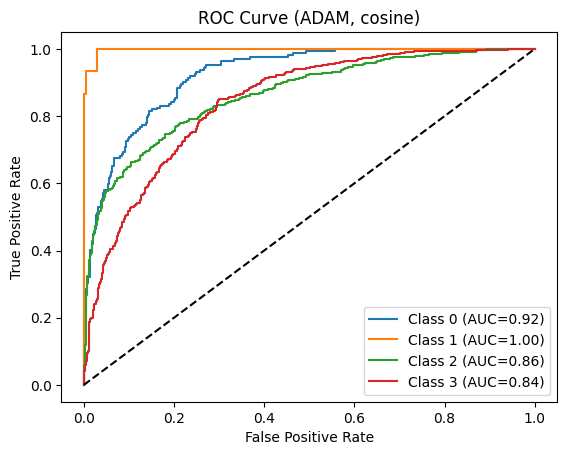

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.4148 Acc: 0.4175 | Val Loss: 1.2152 Acc: 0.5361
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2245 Acc: 0.4900 | Val Loss: 1.0713 Acc: 0.4844
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.0797 Acc: 0.5107 | Val Loss: 0.9847 Acc: 0.5303
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.0429 Acc: 0.5347 | Val Loss: 0.9149 Acc: 0.5547
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 0.9314 Acc: 0.5569 | Val Loss

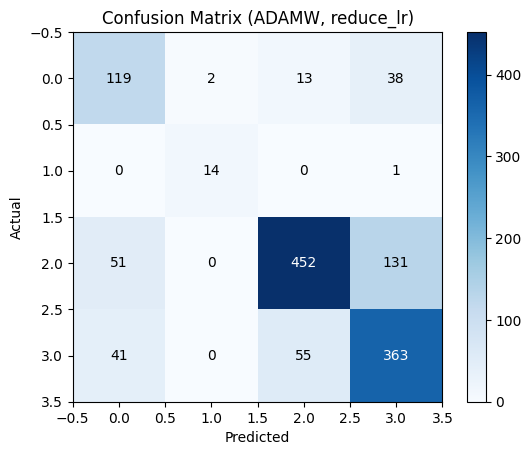

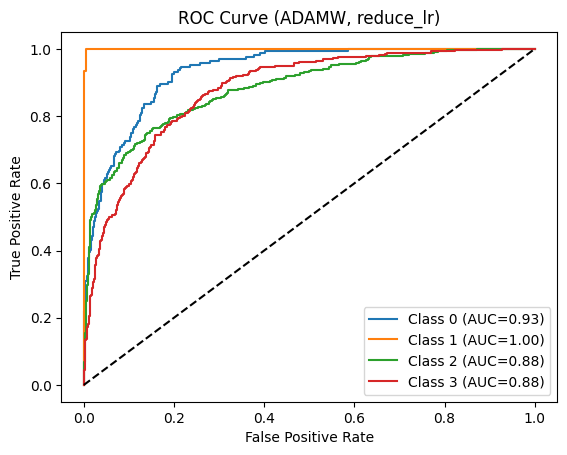

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 0.0001
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.3880 Acc: 0.4360 | Val Loss: 1.1756 Acc: 0.5293
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.2192 Acc: 0.4873 | Val Loss: 1.1311 Acc: 0.5557
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.1165 Acc: 0.5042 | Val Loss: 1.1454 Acc: 0.5273
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 0.9900 Acc: 0.5332 | Val Loss: 0.9456 Acc: 0.5508
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 0.9602 Acc: 0.5481 | Val Loss: 0

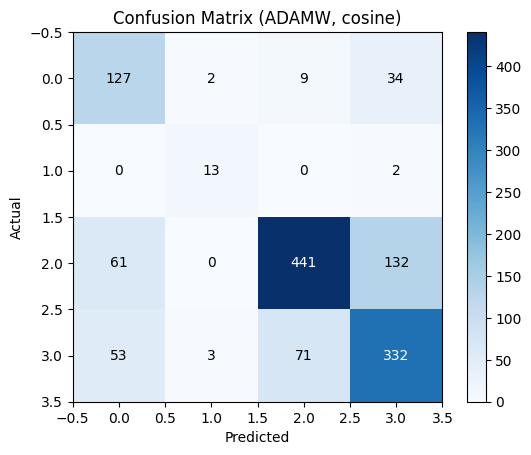

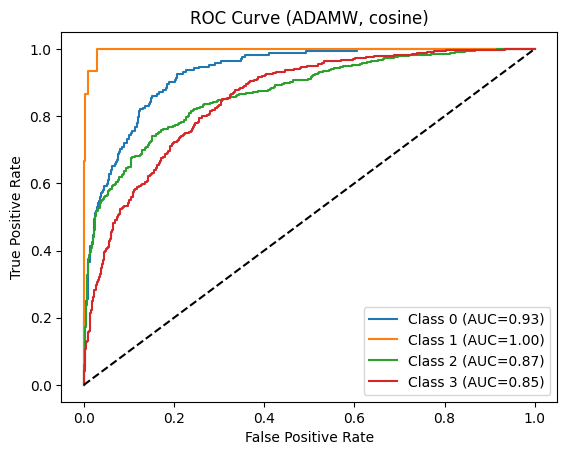

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 0.0001
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-04 | Train Loss: 1.3116 Acc: 0.4019 | Val Loss: 1.2727 Acc: 0.5000
Epoch 2/25 | LR: 1.00e-04 | Train Loss: 1.2523 Acc: 0.4780 | Val Loss: 1.2191 Acc: 0.5488
Epoch 3/25 | LR: 1.00e-04 | Train Loss: 1.2193 Acc: 0.4817 | Val Loss: 1.1859 Acc: 0.5645
Epoch 4/25 | LR: 1.00e-04 | Train Loss: 1.1828 Acc: 0.5166 | Val Loss: 1.1258 Acc: 0.5801
Epoch 5/25 | LR: 1.00e-04 | Train Loss: 1.1440 Acc: 0.5171 | Val Loss: 

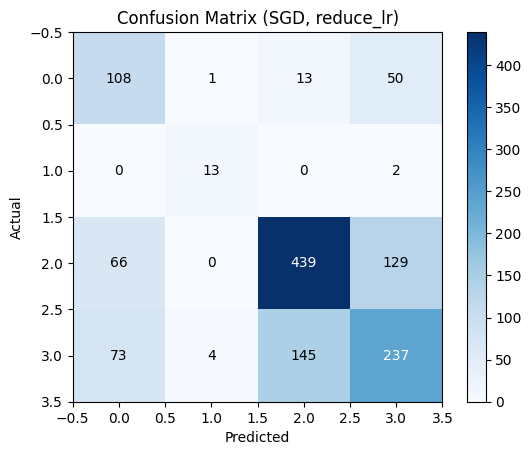

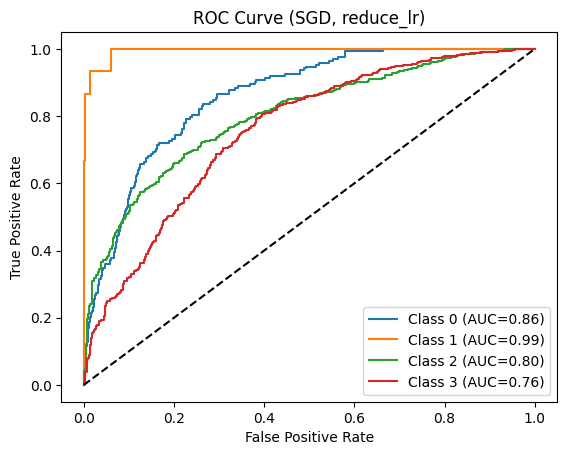

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : freeze_all
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 0.0001
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-05 | Train Loss: 1.3144 Acc: 0.4070 | Val Loss: 1.2750 Acc: 0.4893
Epoch 2/25 | LR: 9.84e-05 | Train Loss: 1.2738 Acc: 0.4695 | Val Loss: 1.2205 Acc: 0.5049
Epoch 3/25 | LR: 9.65e-05 | Train Loss: 1.2373 Acc: 0.4814 | Val Loss: 1.1649 Acc: 0.5723
Epoch 4/25 | LR: 9.38e-05 | Train Loss: 1.1781 Acc: 0.4958 | Val Loss: 1.1193 Acc: 0.5732
Epoch 5/25 | LR: 9.05e-05 | Train Loss: 1.1446 Acc: 0.5117 | Val Loss: 1.0

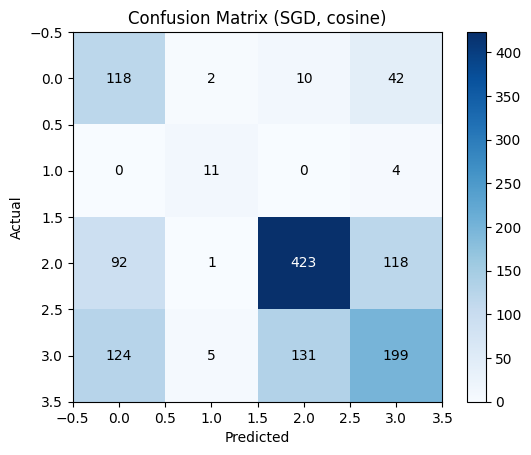

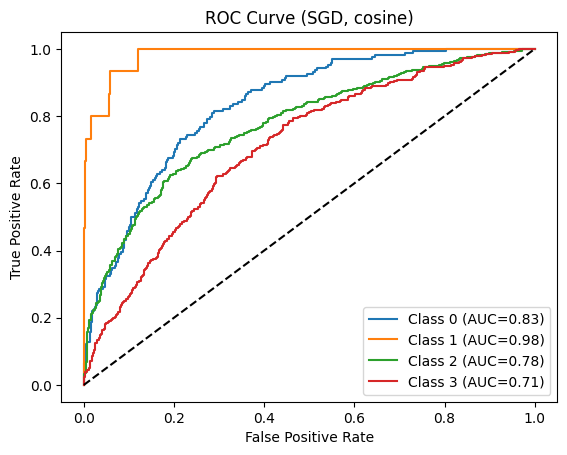

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "freeze_all"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 182MB/s]



Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.2023 Acc: 0.4861 | Val Loss: 1.1588 Acc: 0.5195
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.0333 Acc: 0.5334 | Val Loss: 1.0342 Acc: 0.5693
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.9360 Acc: 0.5718 | Val Loss: 0.8344 Acc: 0.5820
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.7536 Acc: 0.6418 | Val Loss: 0.8898 Acc: 0.5254
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.6663 Acc: 0.6838 | Val Loss: 0.7949 Acc: 0.6631
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 0.5521 Acc: 0.7253 | Val Loss: 0.5743 Acc: 0.6738
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 0.4873 Acc: 0.7703 | Val Loss: 0.4762 Acc: 0.7559
Epoch 8/25 | LR: 5.00e-05 | Train Loss: 0.4050 Acc: 0.8062 | Val Loss: 0.4309 Acc: 0.7783
Epoch 9/25 | LR: 5.00e-05 | Train Loss: 0.3581 Acc: 0.8369 | Val Loss: 0.4735 Acc: 0.7988
Epoch 10/25 | LR: 5.00e-05 | Train Loss: 0.2628 Acc: 0.8713 | Val Loss: 0.6305 Acc: 0.8154
Epoch 11/25 | LR: 5.00e-05 | Train Loss: 0.2244 Acc: 0.8955 | Val Loss: 0.4402 A

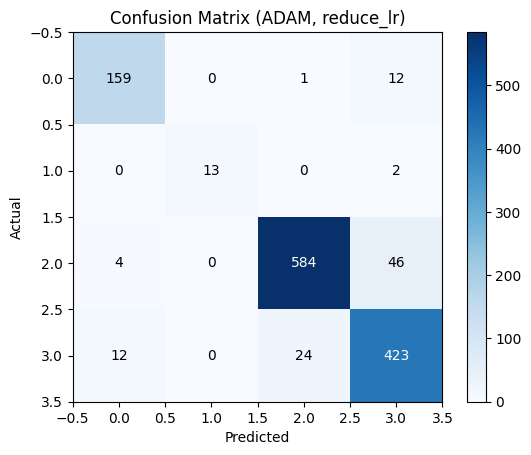

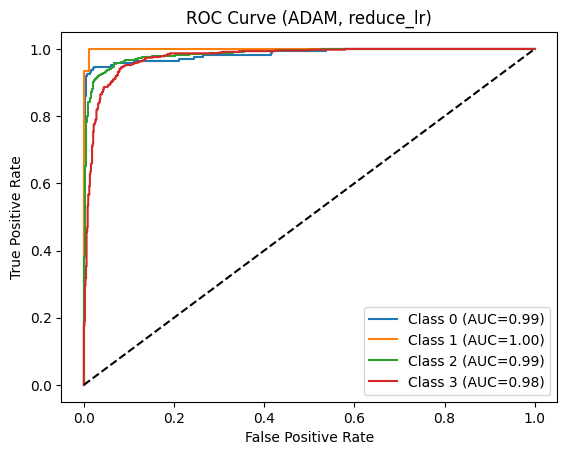

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 5e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.2106 Acc: 0.4827 | Val Loss: 1.0859 Acc: 0.5088
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.0422 Acc: 0.5439 | Val Loss: 0.9769 Acc: 0.5010
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.9350 Acc: 0.5686 | Val Loss: 1.2025 Acc: 0.6055
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.8016 Acc: 0.6143 | Val Loss: 0.7712 Acc: 0.6006
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.6554 Acc: 0.6860 | Val Loss: 

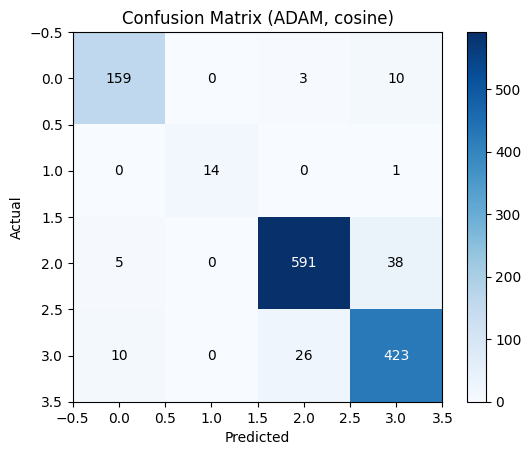

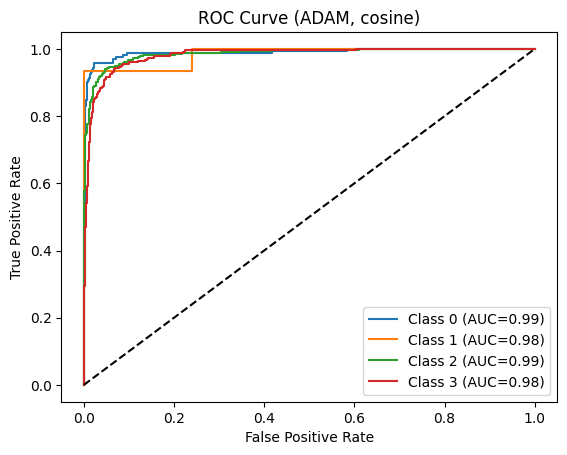

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.2307 Acc: 0.4773 | Val Loss: 1.1180 Acc: 0.5791
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.0520 Acc: 0.5344 | Val Loss: 0.9625 Acc: 0.6055
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 0.9369 Acc: 0.5576 | Val Loss: 0.8520 Acc: 0.5449
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 0.7991 Acc: 0.6116 | Val Loss: 0.7515 Acc: 0.5771
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 0.6709 Acc: 0.6619 | Val Lo

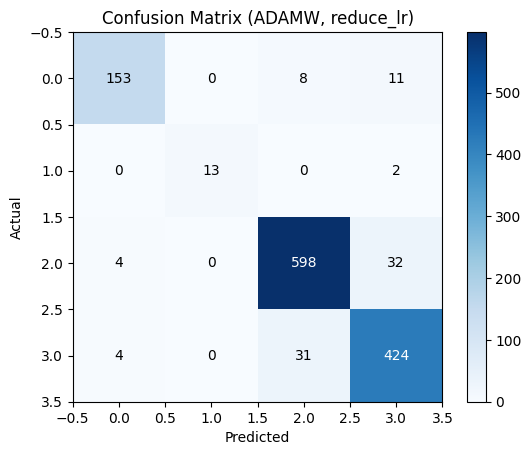

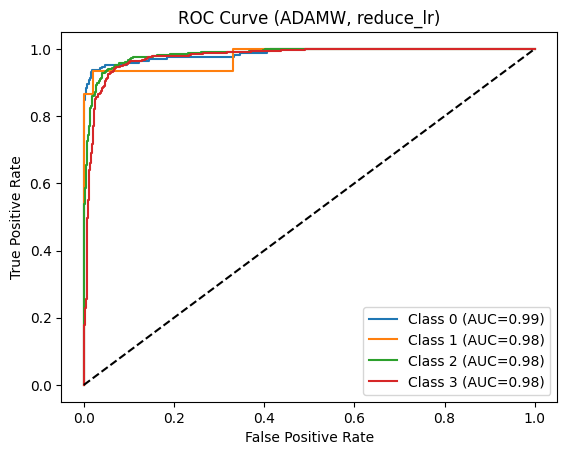

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 5e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.2231 Acc: 0.4675 | Val Loss: 1.0462 Acc: 0.5801
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.0830 Acc: 0.5354 | Val Loss: 0.9464 Acc: 0.5674
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 0.9546 Acc: 0.5674 | Val Loss: 0.8484 Acc: 0.6016
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 0.7775 Acc: 0.6201 | Val Loss: 0.7778 Acc: 0.5908
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 0.6775 Acc: 0.6711 | Val Loss:

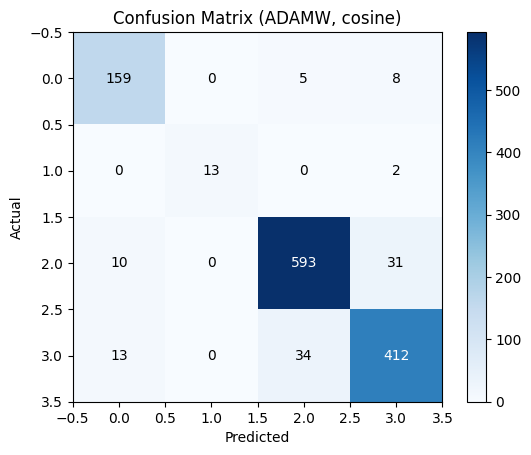

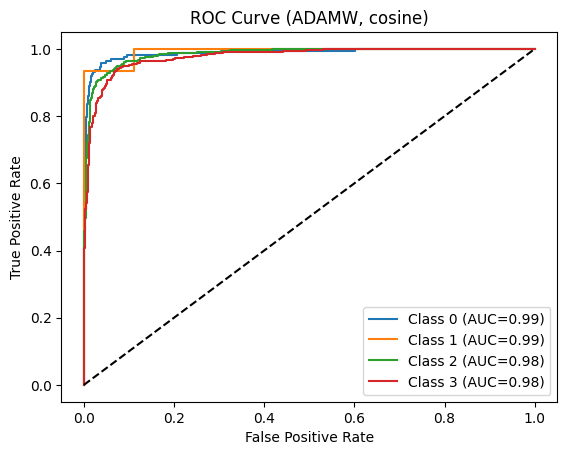

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 5e-05
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:04<00:00, 124MB/s]



Mulai Training...
Epoch 1/25 | LR: 5.00e-05 | Train Loss: 1.3263 Acc: 0.4089 | Val Loss: 1.2846 Acc: 0.5518
Epoch 2/25 | LR: 5.00e-05 | Train Loss: 1.2926 Acc: 0.4395 | Val Loss: 1.2486 Acc: 0.5293
Epoch 3/25 | LR: 5.00e-05 | Train Loss: 1.2594 Acc: 0.4622 | Val Loss: 1.2080 Acc: 0.5547
Epoch 4/25 | LR: 5.00e-05 | Train Loss: 1.2122 Acc: 0.4924 | Val Loss: 1.1599 Acc: 0.5654
Epoch 5/25 | LR: 5.00e-05 | Train Loss: 1.1577 Acc: 0.5156 | Val Loss: 1.0990 Acc: 0.5400
Epoch 6/25 | LR: 5.00e-05 | Train Loss: 1.1169 Acc: 0.5256 | Val Loss: 1.0535 Acc: 0.5957
Epoch 7/25 | LR: 5.00e-05 | Train Loss: 1.0811 Acc: 0.5361 | Val Loss: 1.0624 Acc: 0.5811
Epoch 8/25 | LR: 5.00e-05 | Train Loss: 1.0329 Acc: 0.5391 | Val Loss: 0.9557 Acc: 0.5625
Epoch 9/25 | LR: 5.00e-05 | Train Loss: 0.9832 Acc: 0.5481 | Val Loss: 0.9616 Acc: 0.5166
Epoch 10/25 | LR: 5.00e-05 | Train Loss: 0.9399 Acc: 0.5593 | Val Loss: 0.9261 Acc: 0.5547
Epoch 11/25 | LR: 5.00e-05 | Train Loss: 0.9095 Acc: 0.5652 | Val Loss: 0.8761 A

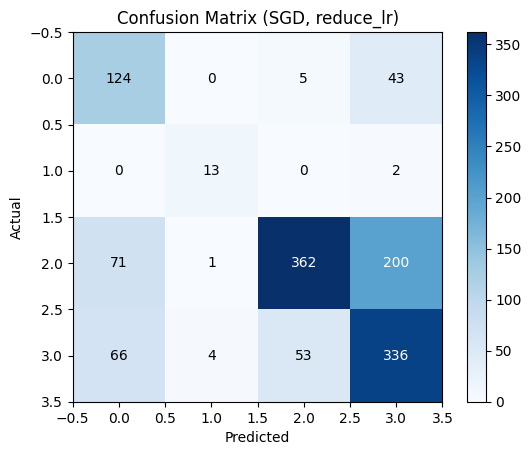

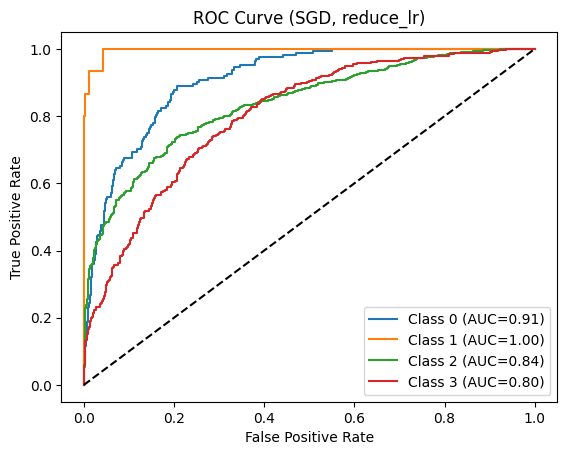

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : unfreeze_last
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 5e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 4.98e-05 | Train Loss: 1.3245 Acc: 0.4082 | Val Loss: 1.2879 Acc: 0.5117
Epoch 2/25 | LR: 4.92e-05 | Train Loss: 1.2813 Acc: 0.4541 | Val Loss: 1.2532 Acc: 0.5459
Epoch 3/25 | LR: 4.82e-05 | Train Loss: 1.2436 Acc: 0.4824 | Val Loss: 1.2091 Acc: 0.4834
Epoch 4/25 | LR: 4.69e-05 | Train Loss: 1.2051 Acc: 0.5068 | Val Loss: 1.1573 Acc: 0.5371
Epoch 5/25 | LR: 4.52e-05 | Train Loss: 1.1504 Acc: 0.5183 | Val Loss: 1

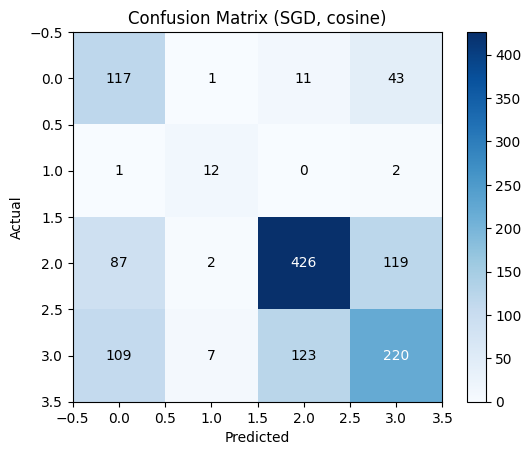

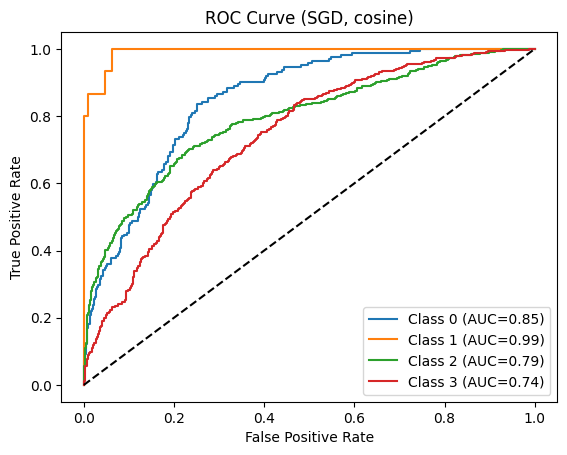

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "unfreeze_last"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAM
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.2487 Acc: 0.4595 | Val Loss: 1.1061 Acc: 0.5547
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.0150 Acc: 0.5479 | Val Loss: 0.9265 Acc: 0.5488
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.8154 Acc: 0.6157 | Val Loss: 0.6946 Acc: 0.6387
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.6271 Acc: 0.6880 | Val Loss: 0.5618 Acc: 0.7539
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.4743 Acc: 0.7671 | Val Loss:

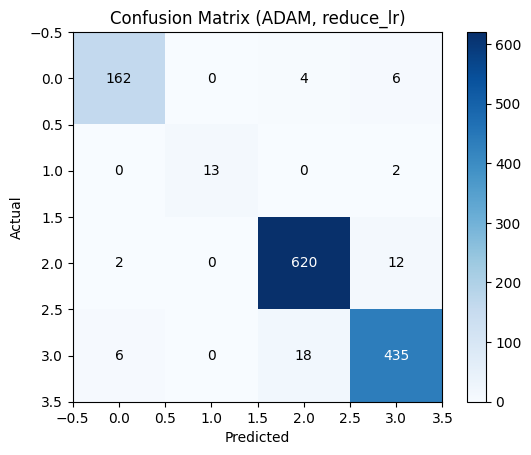

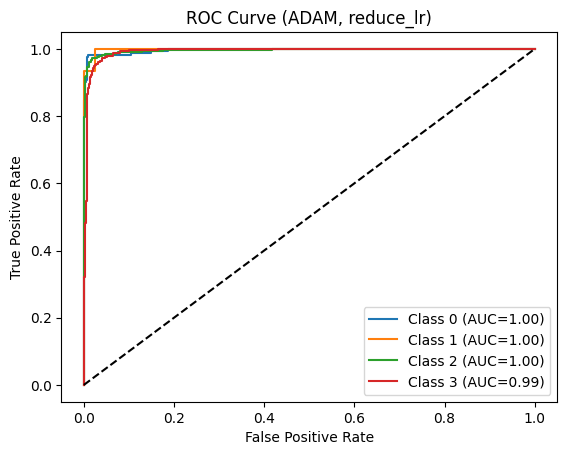

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAM
Scheduler   : cosine
Start LR    : 1e-05
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 98.6MB/s]



Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.2296 Acc: 0.4758 | Val Loss: 1.0374 Acc: 0.5684
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.0026 Acc: 0.5549 | Val Loss: 0.9974 Acc: 0.5410
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.7996 Acc: 0.6257 | Val Loss: 0.6522 Acc: 0.6953
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.6072 Acc: 0.7114 | Val Loss: 0.5806 Acc: 0.7373
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.4487 Acc: 0.7729 | Val Loss: 0.4288 Acc: 0.7920
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 0.3523 Acc: 0.8250 | Val Loss: 0.5649 Acc: 0.7109
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 0.2717 Acc: 0.8672 | Val Loss: 0.3118 Acc: 0.8613
Epoch 8/25 | LR: 7.68e-06 | Train Loss: 0.1978 Acc: 0.8984 | Val Loss: 0.3871 Acc: 0.8779
Epoch 9/25 | LR: 7.13e-06 | Train Loss: 0.1470 Acc: 0.9282 | Val Loss: 0.2518 Acc: 0.8877
Epoch 10/25 | LR: 6.55e-06 | Train Loss: 0.1130 Acc: 0.9456 | Val Loss: 0.2716 Acc: 0.9170
Epoch 11/25 | LR: 5.94e-06 | Train Loss: 0.0813 Acc: 0.9612 | Val Loss: 0.1744 A

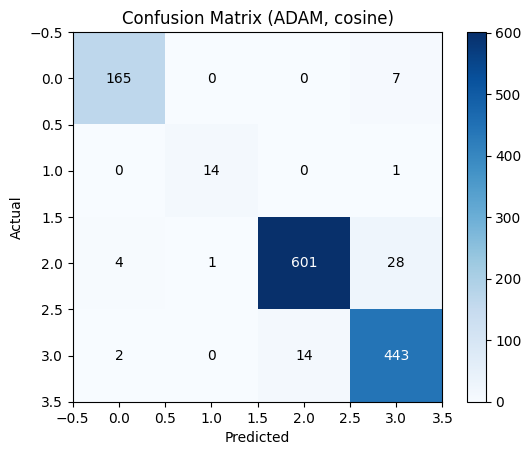

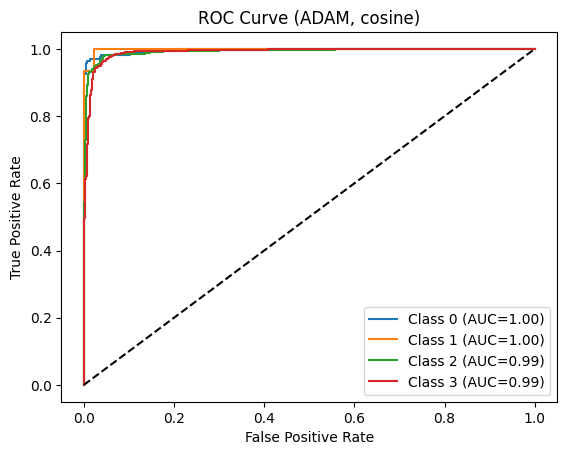

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adam"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAMW
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.2214 Acc: 0.4934 | Val Loss: 1.0753 Acc: 0.4951
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.0380 Acc: 0.5479 | Val Loss: 0.9074 Acc: 0.5938
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 0.8628 Acc: 0.5994 | Val Loss: 0.7135 Acc: 0.6475
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 0.6734 Acc: 0.6814 | Val Loss: 0.6226 Acc: 0.7354
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 0.4979 Acc: 0.7456 | Val Loss

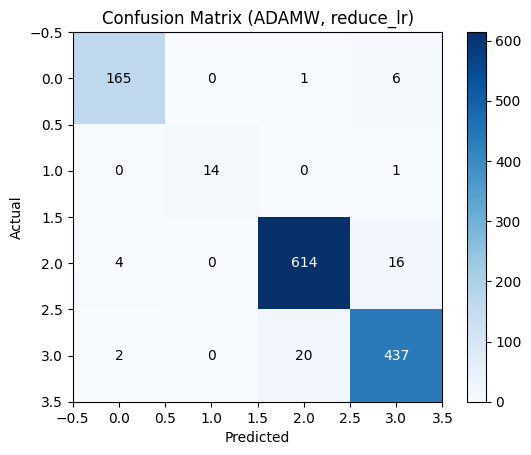

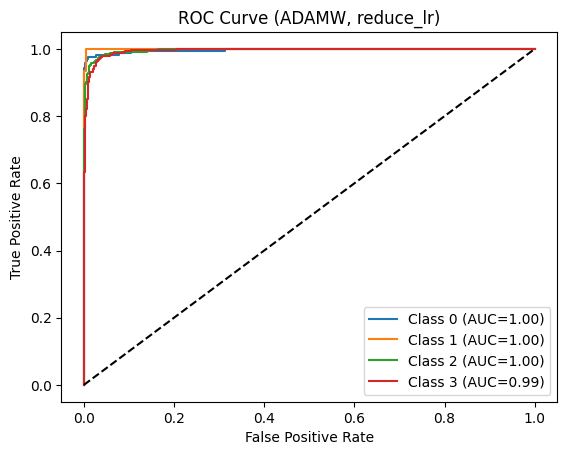

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : ADAMW
Scheduler   : cosine
Start LR    : 1e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.2479 Acc: 0.4907 | Val Loss: 1.2110 Acc: 0.5723
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.0262 Acc: 0.5571 | Val Loss: 0.9449 Acc: 0.5674
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 0.8567 Acc: 0.6140 | Val Loss: 0.7665 Acc: 0.5967
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 0.6380 Acc: 0.6873 | Val Loss: 0.6635 Acc: 0.6436
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 0.4885 Acc: 0.7603 | Val Loss: 0

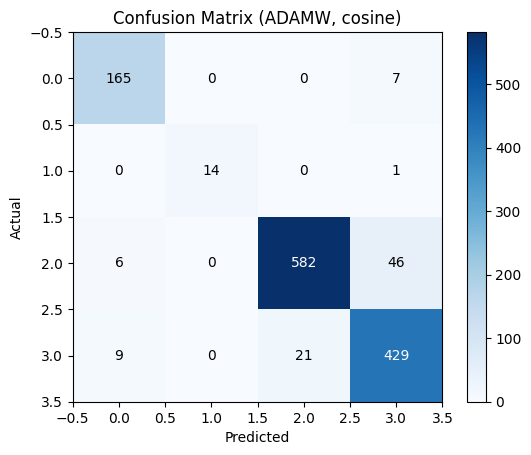

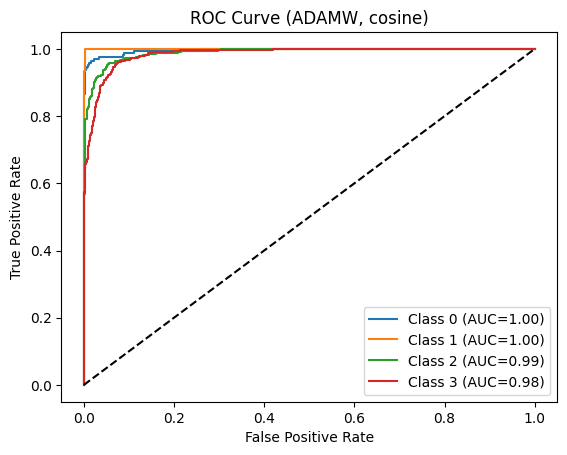

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "adamw"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "reduce_lr"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : reduce_lr
Start LR    : 1e-05
------------------------------

Loading dataset...
-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...

Mulai Training...
Epoch 1/25 | LR: 1.00e-05 | Train Loss: 1.3550 Acc: 0.3369 | Val Loss: 1.3234 Acc: 0.4385
Epoch 2/25 | LR: 1.00e-05 | Train Loss: 1.3268 Acc: 0.3684 | Val Loss: 1.3056 Acc: 0.5195
Epoch 3/25 | LR: 1.00e-05 | Train Loss: 1.3054 Acc: 0.4207 | Val Loss: 1.2954 Acc: 0.5303
Epoch 4/25 | LR: 1.00e-05 | Train Loss: 1.3000 Acc: 0.4231 | Val Loss: 1.2879 Acc: 0.5215
Epoch 5/25 | LR: 1.00e-05 | Train Loss: 1.2929 Acc: 0.4329 | Val Loss: 

Mounting Google Drive...
Mounted at /content/drive
Folder penyimpanan siap: /content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/

--- MENJALANKAN EKSPERIMEN ---
Device      : cuda
Augmentasi  : True
Imbalance   : CLASS_WEIGHT
Fine-Tuning : full_tuning
Optimizer   : SGD
Scheduler   : cosine
Start LR    : 1e-05
------------------------------

Loading dataset...


README.md:   0%|          | 0.00/2.13k [00:00<?, ?B/s]

data/train-00000-of-00001-c08a401c53fe53(…):   0%|          | 0.00/22.6M [00:00<?, ?B/s]

data/test-00000-of-00001-44110b9df98c558(…):   0%|          | 0.00/5.65M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5120 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1280 [00:00<?, ? examples/s]

-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...
Setup VGG19 model...
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 182MB/s]



Mulai Training...
Epoch 1/25 | LR: 9.96e-06 | Train Loss: 1.3482 Acc: 0.3584 | Val Loss: 1.3199 Acc: 0.4697
Epoch 2/25 | LR: 9.84e-06 | Train Loss: 1.3197 Acc: 0.3914 | Val Loss: 1.3061 Acc: 0.5088
Epoch 3/25 | LR: 9.65e-06 | Train Loss: 1.3152 Acc: 0.4043 | Val Loss: 1.2970 Acc: 0.5225
Epoch 4/25 | LR: 9.38e-06 | Train Loss: 1.2957 Acc: 0.4324 | Val Loss: 1.2874 Acc: 0.5137
Epoch 5/25 | LR: 9.05e-06 | Train Loss: 1.2886 Acc: 0.4392 | Val Loss: 1.2773 Acc: 0.5195
Epoch 6/25 | LR: 8.64e-06 | Train Loss: 1.2849 Acc: 0.4590 | Val Loss: 1.2673 Acc: 0.5137
Epoch 7/25 | LR: 8.19e-06 | Train Loss: 1.2678 Acc: 0.4722 | Val Loss: 1.2544 Acc: 0.5049
Epoch 8/25 | LR: 7.68e-06 | Train Loss: 1.2511 Acc: 0.4836 | Val Loss: 1.2420 Acc: 0.5137
Epoch 9/25 | LR: 7.13e-06 | Train Loss: 1.2409 Acc: 0.4790 | Val Loss: 1.2272 Acc: 0.5156
Epoch 10/25 | LR: 6.55e-06 | Train Loss: 1.2369 Acc: 0.4995 | Val Loss: 1.2131 Acc: 0.5068
Epoch 11/25 | LR: 5.94e-06 | Train Loss: 1.2175 Acc: 0.4978 | Val Loss: 1.1961 A

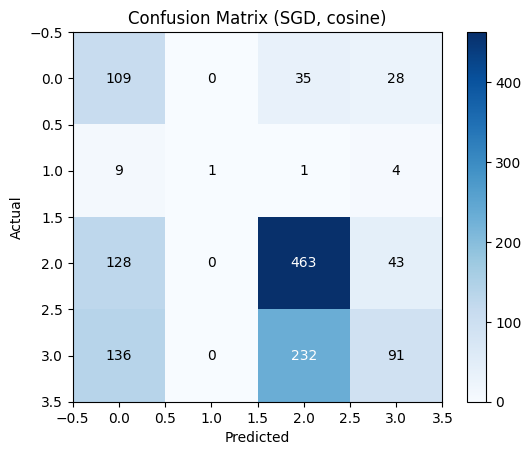

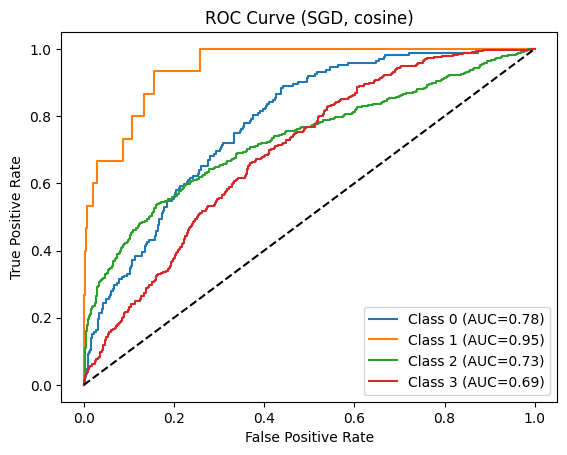

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from torchvision.models import VGG19_Weights
from datasets import load_dataset
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import numpy as np
import copy
import matplotlib.pyplot as plt
import os

# ==========================================
# 0. INTEGRASI GOOGLE DRIVE
# ==========================================
try:
    from google.colab import drive
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

    # Tentukan path folder di Google Drive (bisa disesuaikan namanya)
    SAVE_DIR = '/content/drive/MyDrive/Eksperimen_Alzheimer_VGG19_CW/'
    os.makedirs(SAVE_DIR, exist_ok=True)
    print(f"Folder penyimpanan siap: {SAVE_DIR}")
except ImportError:
    print("Bukan environment Google Colab. Model akan disimpan di lokal.")
    SAVE_DIR = './'

# ==========================================
# 1. CONFIG & EXPERIMENT FLAGS (MASTER GRID SEARCH)
# ==========================================
# 🔥 Dikunci sesuai permintaan: Augmentasi + Sampler
USE_AUGMENTATION = True
IMBALANCE_STRATEGY = "class_weight"

# ---------------------------------------------------------
# CONTEKAN SKENARIO EKSPERIMEN (S-01 s/d S-18):
# ---------------------------------------------------------
# S-01 | freeze_all    | adam  | reduce_lr
# S-02 | freeze_all    | adam  | cosine
# S-03 | freeze_all    | adamw | reduce_lr
# S-04 | freeze_all    | adamw | cosine
# S-05 | freeze_all    | sgd   | reduce_lr
# S-06 | freeze_all    | sgd   | cosine
# S-07 | unfreeze_last | adam  | reduce_lr
# S-08 | unfreeze_last | adam  | cosine
# S-09 | unfreeze_last | adamw | reduce_lr
# S-10 | unfreeze_last | adamw | cosine
# S-11 | unfreeze_last | sgd   | reduce_lr
# S-12 | unfreeze_last | sgd   | cosine
# S-13 | full_tuning   | adam  | reduce_lr
# S-14 | full_tuning   | adam  | cosine
# S-15 | full_tuning   | adamw | reduce_lr
# S-16 | full_tuning   | adamw | cosine
# S-17 | full_tuning   | sgd   | reduce_lr
# S-18 | full_tuning   | sgd   | cosine
# ---------------------------------------------------------

# 🔥 UBAH 3 FLAG DI BAWAH INI SESUAI SKENARIO YANG INGIN DIJALANKAN:
FINE_TUNE_LEVEL = "full_tuning"   # Pilihan: "freeze_all", "unfreeze_last", "full_tuning"
OPTIMIZER_TYPE  = "sgd"         # Pilihan: "adam", "adamw", "sgd"
SCHEDULER_TYPE  = "cosine"       # Pilihan: "reduce_lr", "cosine"

# Dinamis menentukan LR awal berdasarkan level Fine-Tuning
if FINE_TUNE_LEVEL == "freeze_all":
    current_lr = 1e-4
elif FINE_TUNE_LEVEL == "unfreeze_last":
    current_lr = 5e-5
else: # full_tuning
    current_lr = 1e-5

CONFIG = {
    "lr": current_lr,
    "batch_size": 16,
    "epochs": 25,
    "patience": 7,
    "num_workers": 2
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n--- MENJALANKAN EKSPERIMEN ---")
print(f"Device      : {device}")
print(f"Augmentasi  : {USE_AUGMENTATION}")
print(f"Imbalance   : {IMBALANCE_STRATEGY.upper()}")
print(f"Fine-Tuning : {FINE_TUNE_LEVEL}")
print(f"Optimizer   : {OPTIMIZER_TYPE.upper()}")
print(f"Scheduler   : {SCHEDULER_TYPE}")
print(f"Start LR    : {CONFIG['lr']}")
print(f"------------------------------\n")

# ==========================================
# 2. LOAD & SPLIT DATASET
# ==========================================
print("Loading dataset...")
hf_dataset = load_dataset("Falah/Alzheimer_MRI")

hf_train_data = hf_dataset["train"]
test_data = hf_dataset["test"]

train_labels_full = np.array(hf_train_data["label"])

train_idx, val_idx = train_test_split(
    np.arange(len(train_labels_full)),
    test_size=0.2,
    stratify=train_labels_full,
    random_state=42
)

train_data = hf_train_data.select(train_idx)
val_data   = hf_train_data.select(val_idx)

train_labels = np.array(train_data["label"])
num_classes = len(np.unique(train_labels))

# ==========================================
# 3. KALKULASI IMBALANCE WEIGHTS & SAMPLER
# ==========================================
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * num_classes

sample_weights = class_weights[train_labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# ==========================================
# 4. DATASET WRAPPER & TRANSFORM
# ==========================================
class AlzheimerDataset(Dataset):
    def __init__(self, hf_data, transform=None):
        self.data = hf_data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = item["image"].convert("RGB")
        label = item["label"]
        if self.transform:
            image = self.transform(image)
        return image, label

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

if USE_AUGMENTATION:
    train_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
        transforms.ColorJitter(brightness=0.1, contrast=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
else:
    train_transform = val_test_transform

train_ds = AlzheimerDataset(train_data, train_transform)
val_ds   = AlzheimerDataset(val_data, val_test_transform)
test_ds  = AlzheimerDataset(test_data, val_test_transform)

# ==========================================
# 5. DATALOADER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "sampler":
    print("-> Menerapkan Weighted Random Sampler pada DataLoader...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], sampler=sampler, shuffle=False, num_workers=CONFIG["num_workers"])
else:
    print("-> DataLoader menggunakan Normal Shuffle (Tanpa Sampler)...")
    train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])

val_loader   = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader  = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

# ==========================================
# 6. MODEL VGG19 & FINE-TUNING LOGIC
# ==========================================
print("Setup VGG19 model...")
model = models.vgg19(weights=VGG19_Weights.DEFAULT)

if FINE_TUNE_LEVEL == "freeze_all":
    for param in model.features.parameters():
        param.requires_grad = False
elif FINE_TUNE_LEVEL == "unfreeze_last":
    for param in model.features.parameters():
        param.requires_grad = False
    for param in model.features[-10:].parameters():
        param.requires_grad = True
elif FINE_TUNE_LEVEL == "full_tuning":
    for param in model.features.parameters():
        param.requires_grad = True

model.classifier = nn.Sequential(
    nn.Linear(25088, 4096),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(4096, 1024),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)
)
model = model.to(device)

# ==========================================
# 7. LOSS, OPTIMIZER & SCHEDULER LOGIC
# ==========================================
if IMBALANCE_STRATEGY == "class_weight":
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
else:
    criterion = nn.CrossEntropyLoss()

# Logic Optimizer
if OPTIMIZER_TYPE == "adam":
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"])
elif OPTIMIZER_TYPE == "adamw":
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], weight_decay=1e-4)
elif OPTIMIZER_TYPE == "sgd":
    optimizer = optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=CONFIG["lr"], momentum=0.9)

# Logic Scheduler
if SCHEDULER_TYPE == "reduce_lr":
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
elif SCHEDULER_TYPE == "cosine":
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG["epochs"])

# ==========================================
# 8. TRAINING LOOP
# ==========================================
print("\nMulai Training...")
best_model = copy.deepcopy(model.state_dict())
best_loss = float("inf")
counter = 0

for epoch in range(CONFIG["epochs"]):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss /= total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Eksekusi Scheduler sesuai tipenya
    if SCHEDULER_TYPE == "reduce_lr":
        scheduler.step(val_loss)
    elif SCHEDULER_TYPE == "cosine":
        scheduler.step()

    current_lr_in_optim = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{CONFIG['epochs']} | LR: {current_lr_in_optim:.2e} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # EARLY STOPPING
    if val_loss < best_loss:
        best_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1
        if counter >= CONFIG["patience"]:
            print("Early stopping triggered!")
            break

# ==========================================
# 9. EVALUASI AKHIR PADA TEST SET & SAVE KE GDRIVE
# ==========================================
print("\nLoad best model for testing...")
model.load_state_dict(best_model)

# 🔥 Nama file dan proses save ke Google Drive
model_filename = f"best_vgg19_aug_sampler_{FINE_TUNE_LEVEL}_{OPTIMIZER_TYPE}_{SCHEDULER_TYPE}.pth"
save_path = os.path.join(SAVE_DIR, model_filename)

torch.save(model.state_dict(), save_path)
print(f"✅ Model berhasil disimpan secara permanen di: {save_path}")

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print(f"\n=== TEST CLASSIFICATION REPORT ===")
print(f"Config: {FINE_TUNE_LEVEL} | {OPTIMIZER_TYPE.upper()} | {SCHEDULER_TYPE}")
print(classification_report(all_labels, all_preds))

# --- PLOTTING CONFUSION MATRIX ---
cm = confusion_matrix(all_labels, all_preds)
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'), ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2. else "black")
plt.show()

# --- PLOTTING ROC CURVE ---
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)
y_bin = label_binarize(all_labels, classes=range(num_classes))

plt.figure()
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({OPTIMIZER_TYPE.upper()}, {SCHEDULER_TYPE})")
plt.legend(loc="lower right")
plt.show()